In [6]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
from scipy.integrate import quad

from crc_scripts.io.gizmo import *
from crc_scripts import config
from crc_scripts.observations import dust_obs as obs
from crc_scripts.observations.obs_data import Observational_Data
import crc_scripts.utils.math_utils as math_utils
import crc_scripts.utils.snap_utils as snap_utils
import crc_scripts.utils.data_calc_utils as calc
import crc_scripts.utils.grain_size.grain_size_utils as grain_size_utils
from crc_scripts.utils.SKIRT.SKIRT_utils import create_SKIRT_particle_files
import crc_scripts.analytical_models.grain_size_evo as gse
from crc_scripts.figure import Figure,Projection
from crc_scripts.analysis.data_reduction import MultiSnapDataIO
import crc_scripts.utils.plot_utils as plt_set
import matplotlib.lines as mlines

import crc_scripts.analytical_models.grain_size_evo as gse_models

# First setup directory for all the plots
plot_dir = os.path.join(os.environ['SLATE'],'dust_size_evo/result_comparison/')
os.makedirs(plot_dir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Simulation Analysis

### Load and Check Single Snapshot for Multiple Simulations

In [38]:

main_dirc = '/N/project/choban_group/cchoban/size_evo_suite/variations/'

# Snapshot to check
snap_num = 100

# group_name='all'
group_name = "shattering"
# group_name = "coagulation"
# group_name = "acc_dest"
# group_name = 'poster'
# group_name = 'init_dust'
# group_name = 'bin_convergence'
# group_name = 'misc'
# group_name = 'coag_fix'

snap_dirs = [
             main_dirc+'Fiducial/output',
             # Initial Dust Dist
            #  main_dirc+'InitStarDust/output',
             # Shattering Variations
             main_dirc+'NoISMShat/output',
             main_dirc+'10xISMShat/output',
             main_dirc+'NoSNeShat/output',
             main_dirc+'WeakSNeShat/output',
             main_dirc+'SNeLargerFrag/output',
             # Coagulation Variations
            #  main_dirc+'NoCoag/output',
            #  main_dirc+'10xCCoag/output',
            #  main_dirc+'20xCCoag/output',
            #  main_dirc+'100xCCoag/output',
            #  main_dirc+'10xVCoag/output',
            #  main_dirc+'NoVCoag/output',
             # Accretion and SNe Destruction Variations
            #  main_dirc+'NoCSpec/output',
            #  main_dirc+'4xAcc/output',
            #  main_dirc+'0.25xAcc/output',
            #  main_dirc+'4xSNeDest/output',
            #  main_dirc+'0.25xSNeDest/output',
            #  main_dirc+'Tcutoff1000K/output',
            #  main_dirc+'Tcutoff100K/output',
            # Misc
            #  main_dirc+'no_subtimesteps/output',
            #  main_dirc+'no_Ceff/output',
            #  main_dirc+'NoStarDust/output',
            #  main_dirc+'4xAcc_10xCCoag/output',
            #  main_dirc+'0.25xAcc_10xCCoag/output',
            #  main_dirc+'NoSNeShat_NoVCoag/output',
            #  main_dirc+'4xIronCoulomb/output',
            #  main_dirc+'CCoag_fix/output',
             # Bin Convergence
            #  main_dirc+'2Bin/output',
            #  main_dirc+'4Bin/output',
            #  main_dirc+'8Bin/output',
            #  main_dirc+'Fiducial/output',
            #  main_dirc+'32Bin/output',
            ]
# Shorthand names for each sim used in plot legends and file names
sim_names = [
             'Fiducial',
             # Initial Dust Dist
            #  'InitStardust'
             # Shattering Variations
             'NoISMShat',
             '10xISMShat',
             'NoSNRShat',
             'WeakSNRShat',
             'LargerSNRFrag',
             # Coagulation Variations
            #  'NoCoag',
            #  '10xCCoag',
            #  '20xCCoag',
            #  '100xCCoag',
            #  '10xVCoag',
            #  'NoVCoag',
             # Accretion and SNe Destruction Variations
            #  'ConstSpecAcc',
            #  '4xAcc',
            #  '1/4xAcc',
            #  '4xSNRDest',
            #  '1/4xSNRDest',
            #  'Tcutoff1000K',
            #  'Tcutoff100K',
             # Misc variations
            #  'NoSubSteps',
            #  'NoCeff',
            #  'NoStardust',
            #  '4xAcc_10xCCoag',
            #  '1/4xAcc_10xCCoag',
            #  'NoSNRShat_NoVCoag',
            #  '4xIronCoulomb',
            #  'CCoag_fix',            
             # Bin Convergence
            #  '2Bin',
            #  '4Bin',
            #  '8Bin',
            #  '16Bin',
            #  '32Bin',
             ]


galaxies = []

In [109]:

main_dirc = '/N/project/choban_group/cchoban/size_evo_suite/IC_variations/'

# Snapshot to check
snap_num = 100
snap_nums = [100,70,70,70]

group_name = "local_group"


snap_dirs = [
            #  '/N/project/choban_group/cchoban/size_evo_suite/IC/fiducial/output',
             main_dirc+'m12_200CCoag/output',
            #  main_dirc+'m11_200CCoag/output',
            # #  main_dirc+'m10/output',
            # #  main_dirc+'m10_lessC/output',
            # #  main_dirc+'m10_lessC_200CCoag/output',
            #  main_dirc+'m10_0.2Z_10SiC_200CCoag_lognorm/output',
            #  main_dirc+'m10_0.2Z_10SiC_200CCoag_0.25CarbAcc_lognorm/output',
            ]
# Shorthand names for each sim used in plot legends and file names
sim_names = [
            #  'm12_fid',
             'm12',
            #  'm11',
            # #  'm10',
            # #  'm10_lessC',
            # #  'm10_lessC_200CCoag',
            #  'm10',
            #  'm10_LowCarb'
            ]


galaxies = []

#### Load Galaxies as Spherical Halos

#### Load Galaxies as Disks

In [39]:
# Disk parameters
disk_radius = 9.6 # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


cut_name = 'disk'

galaxies=[]
for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    sp = load_snap(snap_dir, snap_num, cosmological=0)
    disk = sp.loadhalo(mode=None)
    disk.set_disk(rmax = disk_radius, height=disk_scale_height)
    disk.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    galaxies += [disk]

Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = 0.376, 0.203, -0.089
  center velocity [km/s] = -4.3, -3.2, -0.7
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] Gyr
  axis ratios:  min/maj = 0.028, min/med = 0.030, med/maj = 0.944
Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/variations/NoISMShat/output
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = 0.249, 0.173, -0.086
  center velocity [km/s] = 0.5, -3.4, -1.2
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] Gyr
  axis ratios:  min/maj = 0.031, min/med = 0.032, med/maj = 0.981
Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/variations/10xI

##### Different Snap Numbers and Disk Parameters

In [120]:
# Disk parameters
disk_radii = [9.6,3.2,1.6,1.6] # kpc ~2x the IC disk scale length
disk_scale_heights = [0.5,0.5,0.5,0.5] # kpc ~2x the IC disk scale height

cut_name = 'disk'

galaxies=[]
for i,snap_dir in enumerate(snap_dirs):
    snap_num = snap_nums[i]
    disk_radius = disk_radii[i]
    disk_scale_height = disk_scale_heights[i]
    print("Snap Dirc: ",snap_dir)

    sp = load_snap(snap_dir, snap_num, cosmological=0)
    disk = sp.loadhalo(mode=None)
    disk.set_disk(rmax = disk_radius, height=disk_scale_height)
    disk.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    galaxies += [disk]

Snap Dirc:  /N/project/choban_group/cchoban/size_evo_suite/IC_variations/m12_200CCoag/output
Centering galaxy on median position of gas particles with nH>10 cm^-3.
assigning center of galaxy:
  center position [kpc] = 0.232, 0.136, -0.041
  center velocity [km/s] = 0.0, -5.1, -0.0
assigning principal axes:
  using ptype 4 particles at radius < 10 kpc
  using ptype 4 particles with age = [0, 0.5] Gyr
  axis ratios:  min/maj = 0.037, min/med = 0.038, med/maj = 0.964


#### Quick Check of Global Galaxy Properties

In [66]:
ISM_phases = ['cold','warm','hot','coronal']


property_dict = {
    "name": sim_names,
    "gas_mass": [],
    "H2_mass": [],
    "dust_mass": [],
    "median_D/Z": [],
    "star_mass": [],
    "sfr_10Myr": [],
}
for phase in ISM_phases:
    property_dict[phase+"_gas_mass"] = []


for i,halo in enumerate(galaxies):
    name = sim_names[i]


    G=halo.loadpart(0)
    S=halo.loadpart(4, append_dummies=True)

    gas_mass = G.get_property('mass')
    H2_mass = G.get_property('M_H2')
    dust_mass = G.get_property('M_dust')
    spec_mass = G.get_property('M_spec')
    DZ = G.get_property('D/Z')
    star_mass = S.get_property('mass')
    sfr = S.get_property('M_form_10Myr')


    property_dict["gas_mass"] += [np.sum(gas_mass)/1E10]
    property_dict["H2_mass"] += [np.sum(H2_mass)/1E10]
    property_dict["dust_mass"] += [np.sum(dust_mass)/1E10]
    property_dict["median_D/Z"] += [np.sum(np.median(DZ))]
    property_dict["star_mass"] += [np.sum(star_mass)/1E10]
    property_dict["sfr_10Myr"] += [np.sum(sfr)/10E6]

    for phase in ISM_phases:
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        property_dict[phase+"_gas_mass"] +=[np.sum(gas_mass[mask])/1E10]

for key,item in property_dict.items():
    print(key,item)
        

name ['Fiducial', '4xSNeDest', '1/4xSNeDest', 'Tcutoff1000K', 'Tcutoff100K', '4xAcc', '1/4xAcc']
gas_mass [0.1579976832, 0.1435352704, 0.1678759424, 0.1567747456, 0.1668104704, 0.1742611584, 0.1599742592]
H2_mass [0.0018485478, 0.0015013835, 0.0017414566, 0.0015524223, 0.0016136567, 0.0029072762, 0.002059428]
dust_mass [0.0008916686, 0.00031829095, 0.0012265702, 0.0009359213, 0.0008441921, 0.0011229373, 0.00062479205]
median_D/Z [0.34057677, 0.11982566, 0.44118553, 0.36114538, 0.30155152, 0.38655707, 0.23057128]
star_mass [3.2163905536, 3.2319256576, 3.217348608, 3.2222404608, 3.216971776, 3.2341727232, 3.2324128768]
sfr_10Myr [0.5645928647580871, 0.4480506716413428, 0.5442876944268765, 0.3099187303541609, 0.42633913769946274, 0.880165571918254, 0.4358613036882986]
cold_gas_mass [0.004485712, 0.012371172, 0.0039261224, 0.0039465084, 0.0040728088, 0.0051876336, 0.0056892368]
warm_gas_mass [0.1235801856, 0.1080202624, 0.115013504, 0.121931712, 0.1315233792, 0.1280122752, 0.1321572608]
ho

#### Median Dust Info

Compare dust properties against Fiducial Model. These properties are derived for neutral gas only.

In [35]:

property_dict = {
    "name": [],
    "median_D/Z": [],
    "median_Si/C": [],
    "median_STL": [],
    "median_slope": [],
    "median_bump": [],
}


for i,halo in enumerate(galaxies):
    name = sim_names[i]
    property_dict["name"] += [name]




    G=halo.loadpart(0)
    S=halo.loadpart(4, append_dummies=True)
    M_neutral = G.get_property("M_gas_neutral")
    weights = None
    # Typical D/Z
    DZ = G.get_property('D/Z')
    property_dict["median_D/Z"] += [math_utils.weighted_percentile(DZ,percentiles=[50],weights=weights)[0]]

    SiC = G.get_property('Si/C')
    property_dict["median_Si/C"] += [math_utils.weighted_percentile(SiC,percentiles=[50],weights=weights)[0]]

    # Typical small to large grain mass ratio

    # Small to large grain cutoff
    a_small = 0.02 # micron

    grain_bin_mass = G.get_property('grain_bin_mass')
    large_bins = halo.sp.Grain_Bin_Centers > a_small
    small_bins = ~large_bins
    large_grain_bin_mass = np.sum(grain_bin_mass[:,:,large_bins],axis=(1,2))
    small_grain_bin_mass = np.sum(grain_bin_mass[:,:,small_bins],axis=(1,2))
    STL = small_grain_bin_mass / large_grain_bin_mass   
    property_dict["median_STL"] += [math_utils.weighted_percentile(STL,percentiles=[50],weights=weights)[0]]



    # Typical extinction slope
    bin_subsamples=1
    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species='all', mask=None, weights=weights, std_percentiles = [], 
    bin_subsamples=bin_subsamples)

    slope, bump = grain_size_utils.calculate_extinction_parameters(wavelength_points, A_lambda_percentiles[0])

    property_dict["median_slope"] += [slope]
    property_dict["median_bump"] += [bump]

 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.


In [37]:
extra_info ={
    'Fiducial':' & \\textemdash & \\textemdash & \\textemdash & \\textemdash  ',
    'NoISMShat':'  & \\textemdash & \\textemdash & only in SNR & \\textemdash ',
    '10xISMShat':'  & \\textemdash & \\textemdash & 10 x ISM shat. & \\textemdash ',
    'NoSNRShat':'  & \\textemdash & only sputtering$^{\it a}$ & \\textemdash & \\textemdash ',
    'WeakSNRShat':'  & \\textemdash & 4 x reduced shat. eff.$^{\it a}$ & \\textemdash & \\textemdash ',
    'LargerSNRFrag':'  & \\textemdash & larger $a^{\\rm SN}_{\\rm frag}=0.6\;\micron^{\it a}$ & \\textemdash & \\textemdash ',
    'NoCoag':'  & \\textemdash & \\textemdash & \\textemdash & none ',
    '10xCCoag':' & \\textemdash & \\textemdash & \\textemdash & 10 x $C_{\\rm coag}$ ',
    '20xCCoag':' & \\textemdash & \\textemdash & \\textemdash & 20 x $C_{\\rm coag}$ ',
    '100xCCoag':' & \\textemdash & \\textemdash & \\textemdash & 100 x $C_{\\rm coag}$  ',
    '10xVCoag':'  & \\textemdash & \\textemdash & \\textemdash & 10 x $v_{\\rm coag}$ ',
    'NoVCoag':'  & \\textemdash & \\textemdash & \\textemdash & $v_{\\rm coag} = v_{\\rm shat}$ ',
    'ConstSpecAcc':' & $n_{\\rm max} = \infty$ \& $D_{\\rm k}=1$ & \\textemdash & \\textemdash & \\textemdash ',
    '4xAcc':' & 4 x increase &  \\textemdash & \\textemdash & \\textemdash ',
    '1/4xAcc':' & 4 x decrease & \\textemdash & \\textemdash & \\textemdash ',
    '4xSNRDest':' & \\textemdash & 4 x increase & \\textemdash & \\textemdash ',
    '1/4xSNRDest':' & \\textemdash & 4 x decrease & \\textemdash & \\textemdash ',
    'Tcutoff1000K':' & $T_{\\rm cut}=1000$K & \\textemdash & \\textemdash & \\textemdash ',
    'Tcutoff100K':' & $T_{\\rm cut}=100$K & \\textemdash & \\textemdash & \\textemdash '
    }

print("Absolute Difference from Fiducial")
for i, name in enumerate(property_dict['name']):
    print(name)
    DZ = property_dict["median_D/Z"][i]
    SiC = property_dict["median_Si/C"][i]
    STL = property_dict["median_STL"][i]
    slope = property_dict["median_slope"][i]
    bump = property_dict["median_bump"][i]
    print("%s & %.2g & %.3g & %.3g & %.3g & %.3g"%(name,DZ,SiC,STL,slope,bump))

print("Percentile Differences from Fiducial")
fid_DZ = property_dict["median_D/Z"][0]
fid_SiC = property_dict["median_Si/C"][0]
fid_STL = property_dict["median_STL"][0]
fid_slope = property_dict["median_slope"][0]
fid_bump = property_dict["median_bump"][0]
for i, name in enumerate(property_dict['name']):
    DZ = -(fid_DZ-property_dict["median_D/Z"][i])/fid_DZ*100
    SiC = -(fid_SiC-property_dict["median_Si/C"][i])/fid_SiC*100
    STL = -(fid_STL-property_dict["median_STL"][i])/fid_STL*100
    slope = -(fid_slope-property_dict["median_slope"][i])/fid_slope*100
    bump = -(fid_bump-property_dict["median_bump"][i])/fid_bump*100
    print("%s & %2.2g\%% & %2.2g\%% & %3.3g\%% & %2.2g\%% & %2.2g\%%"%(name,DZ,SiC,STL,slope,bump))


print("Fractional Differences from Fiducial")
fid_DZ = property_dict["median_D/Z"][0]
fid_SiC = property_dict["median_Si/C"][0]
fid_STL = property_dict["median_STL"][0]
fid_slope = property_dict["median_slope"][0]
fid_bump = property_dict["median_bump"][0]
for i, name in enumerate(property_dict['name']):
    DZ = (property_dict["median_D/Z"][i])/fid_DZ
    SiC = (property_dict["median_Si/C"][i])/fid_SiC
    STL = (property_dict["median_STL"][i])/fid_STL
    slope = (property_dict["median_slope"][i])/fid_slope
    bump = (property_dict["median_bump"][i])/fid_bump
    print("%s & %2.2g\%% & %2.2g\%% & %3.3g\%% & %2.2g\%% & %2.2g\%%"%(name,DZ,SiC,STL,slope,bump))


print("In Latex Format with colors for each cell")
# Have the colors scale by the min and max of each column
min_maxs ={'D/Z':[-65,30],'SiC':[-34,30],'STL':[-82,180],'S':[-47,14],'B':[-43,12]}
min_maxs ={'D/Z':[-65,65],'SiC':[-34,34],'STL':[-180,180],'S':[-47,47],'B':[-43,43]}
min_max_colors = [0,70]


frac_change_dict = {
    "name": [],
    "median_D/Z": [],
    "median_Si/C": [],
    "median_STL": [],
    "median_slope": [],
    "median_bump": [],
}
for i, name in enumerate(property_dict['name']):
    frac_change_dict['name'] += [name]
    frac_change_dict["median_D/Z"] += [(property_dict["median_D/Z"][i])/fid_DZ]
    frac_change_dict["median_Si/C"] += [(property_dict["median_Si/C"][i])/fid_SiC]
    frac_change_dict["median_STL"] += [(property_dict["median_STL"][i])/fid_STL]
    frac_change_dict["median_slope"] += [(property_dict["median_slope"][i])/fid_slope]
    frac_change_dict["median_bump"] += [(property_dict["median_bump"][i])/fid_bump]
min_maxs = {}
for key in frac_change_dict:
    if key != 'name':
        min_maxs[key] = [np.max(np.abs(frac_change_dict[key]))]

print(min_maxs)

for i, name in enumerate(property_dict['name']):

    DZ = -(fid_DZ-property_dict["median_D/Z"][i])/fid_DZ*100
    SiC = -(fid_SiC-property_dict["median_Si/C"][i])/fid_SiC*100
    STL = -(fid_STL-property_dict["median_STL"][i])/fid_STL*100
    slope = -(fid_slope-property_dict["median_slope"][i])/fid_slope*100
    bump = -(fid_bump-property_dict["median_bump"][i])/fid_bump*100

    DZ = np.log10(frac_change_dict["median_D/Z"][i])
    SiC = np.log10(frac_change_dict["median_Si/C"][i])
    STL = np.log10(frac_change_dict["median_STL"][i])
    slope = np.log10(frac_change_dict["median_slope"][i])
    bump = np.log10(frac_change_dict["median_bump"][i])

    sim_vals = {'D/Z':DZ,'SiC':SiC,'STL':STL,'S':slope,'B':bump}


    line = "%s"%name + extra_info[name]
    for key in sim_vals:
        sim_val = sim_vals[key]
        min_max = min_maxs[key][0]/100
        color_str = 'red' if sim_val < 0 else 'green'
        #color_str += "!%i"%int(np.abs(sim_val/min_max)*min_max_colors[1]+min_max_colors[0])
        color_str += "!%i"%int(np.abs(sim_val/min_max)*min_max_colors[1]+min_max_colors[0])

        line += "& \cellcolor{%s} %i\%% "%(color_str,round(sim_vals[key]))
    line=line+"\\\\"

    print(line)
    # print("%s & %2.2g\%% & %2.2g\%% & %3.3g\%% & %2.2g\%% & %2.2g\%%"%(name,DZ,SiC,STL,slope,bump))

Absolute Difference from Fiducial
Fiducial
Fiducial & 0.34 & 2.1 & 1.1 & 3.82 & 0.514
NoISMShat
NoISMShat & 0.27 & 2.53 & 0.627 & 3.31 & 0.4
10xISMShat
10xISMShat & 0.35 & 2.02 & 2.03 & 5.01 & 0.585
NoSNRShat
NoSNRShat & 0.31 & 2.1 & 1.51 & 4.34 & 0.574
WeakSNRShat
WeakSNRShat & 0.32 & 2.14 & 1.15 & 3.79 & 0.532
LargerSNRFrag
LargerSNRFrag & 0.3 & 2.14 & 1.05 & 3.65 & 0.525
NoCoag
NoCoag & 0.35 & 2.03 & 3.08 & 4.02 & 0.644
10xCCoag
10xCCoag & 0.33 & 2.2 & 0.423 & 2.81 & 0.394
20xCCoag
20xCCoag & 0.32 & 2.25 & 0.327 & 2.51 & 0.362
100xCCoag
100xCCoag & 0.29 & 2.39 & 0.201 & 2.02 & 0.292
10xVCoag
10xVCoag & 0.32 & 2.13 & 0.94 & 3.04 & 0.51
NoVCoag
NoVCoag & 0.33 & 2.14 & 0.918 & 3.14 & 0.513
ConstSpecAcc
ConstSpecAcc & 0.27 & 1.39 & 0.765 & 3.28 & 0.516
4xAcc
4xAcc & 0.39 & 1.94 & 1.19 & 3.84 & 0.524
1/4xAcc
1/4xAcc & 0.23 & 2.74 & 0.819 & 3.58 & 0.425
4xSNRDest
4xSNRDest & 0.12 & 2.19 & 1.44 & 4.27 & 0.527
1/4xSNRDest
1/4xSNRDest & 0.44 & 2.05 & 1.04 & 3.83 & 0.524
Tcutoff1000K
Tcutoff1

KeyError: 'D/Z'

In [ ]:
extra_info ={
    'Fiducial':' & \\textemdash & \\textemdash & \\textemdash & \\textemdash  ',
    'NoISMShat':'  & \\textemdash & \\textemdash & only in SNR & \\textemdash ',
    '10xISMShat':'  & \\textemdash & \\textemdash & 10 x ISM shat. & \\textemdash ',
    'NoSNRShat':'  & \\textemdash & only sputtering$^{\it a}$ & \\textemdash & \\textemdash ',
    'WeakSNRShat':'  & \\textemdash & 4 x reduced shat. eff.$^{\it a}$ & \\textemdash & \\textemdash ',
    'LargerSNRFrag':'  & \\textemdash & larger $a^{\\rm SN}_{\\rm frag}=0.6\;\micron^{\it a}$ & \\textemdash & \\textemdash ',
    'NoCoag':'  & \\textemdash & \\textemdash & \\textemdash & none ',
    '10xCCoag':' & \\textemdash & \\textemdash & \\textemdash & 10 x $C_{\\rm coag}$ ',
    '20xCCoag':' & \\textemdash & \\textemdash & \\textemdash & 20 x $C_{\\rm coag}$ ',
    '100xCCoag':' & \\textemdash & \\textemdash & \\textemdash & 100 x $C_{\\rm coag}$  ',
    '10xVCoag':'  & \\textemdash & \\textemdash & \\textemdash & 10 x $v_{\\rm coag}$ ',
    'NoVCoag':'  & \\textemdash & \\textemdash & \\textemdash & $v_{\\rm coag} = v_{\\rm shat}$ ',
    'ConstSpecAcc':' & $n_{\\rm max} = \infty$ \& $D_{\\rm k}=1$ & \\textemdash & \\textemdash & \\textemdash ',
    '4xAcc':' & 4 x increase &  \\textemdash & \\textemdash & \\textemdash ',
    '1/4xAcc':' & 4 x decrease & \\textemdash & \\textemdash & \\textemdash ',
    '4xSNRDest':' & \\textemdash & 4 x increase & \\textemdash & \\textemdash ',
    '1/4xSNRDest':' & \\textemdash & 4 x decrease & \\textemdash & \\textemdash ',
    'Tcutoff1000K':' & $T_{\\rm cut}=1000$K & \\textemdash & \\textemdash & \\textemdash ',
    'Tcutoff100K':' & $T_{\\rm cut}=100$K & \\textemdash & \\textemdash & \\textemdash '
    }

print("Fractional Differences from Fiducial")
fid_DZ = property_dict["median_D/Z"][0]
fid_SiC = property_dict["median_Si/C"][0]
fid_STL = property_dict["median_STL"][0]
fid_slope = property_dict["median_slope"][0]
fid_bump = property_dict["median_bump"][0]
for i, name in enumerate(property_dict['name']):
    DZ = (property_dict["median_D/Z"][i])/fid_DZ
    SiC = (property_dict["median_Si/C"][i])/fid_SiC
    STL = (property_dict["median_STL"][i])/fid_STL
    slope = (property_dict["median_slope"][i])/fid_slope
    bump = (property_dict["median_bump"][i])/fid_bump
    print("%s & %.2g & %.2g & %.2g & %.2g & %.2g"%(name,DZ,SiC,STL,slope,bump))

frac_change_dict = {
    "name": [],
    "median_D/Z": [],
    "median_Si/C": [],
    "median_STL": [],
    "median_slope": [],
    "median_bump": [],
}
for i, name in enumerate(property_dict['name']):
    frac_change_dict['name'] += [name]
    frac_change_dict["median_D/Z"] += [(property_dict["median_D/Z"][i])/fid_DZ]
    frac_change_dict["median_Si/C"] += [(property_dict["median_Si/C"][i])/fid_SiC]
    frac_change_dict["median_STL"] += [(property_dict["median_STL"][i])/fid_STL]
    frac_change_dict["median_slope"] += [(property_dict["median_slope"][i])/fid_slope]
    frac_change_dict["median_bump"] += [(property_dict["median_bump"][i])/fid_bump]
min_maxs = {}
for key in frac_change_dict:
    if key != 'name':
        min_maxs[key] = [np.max(np.abs(np.log10(frac_change_dict[key])))]


for i, name in enumerate(frac_change_dict['name']):
    DZ = frac_change_dict["median_D/Z"][i]
    SiC = frac_change_dict["median_Si/C"][i]
    STL = frac_change_dict["median_STL"][i]
    slope = frac_change_dict["median_slope"][i]
    bump = frac_change_dict["median_bump"][i]

    sim_vals = {'D/Z':DZ,'Si/C':SiC,'STL':STL,'slope':slope,'bump':bump}


    line = "%s"%name + extra_info[name]
    for key in sim_vals:
        sim_val = sim_vals[key]
        min_max = min_maxs['median_'+key]
        color_str = 'red' if sim_val < 1 else 'green'
        #color_str += "!%i"%int(np.abs(sim_val/min_max)*min_max_colors[1]+min_max_colors[0])
        color_str += "!%i"%int(np.abs(np.log10(sim_val)/min_max)*(min_max_colors[1]+-min_max_colors[0])+min_max_colors[0])

        line += "& \cellcolor{%s} %2.2g "%(color_str,round(np.log10(sim_val),1))
    line=line+"\\\\"

    print(line)

print("\n\nshowing percentage\n\n")
for i, name in enumerate(frac_change_dict['name']):
    DZ = frac_change_dict["median_D/Z"][i]
    SiC = frac_change_dict["median_Si/C"][i]
    STL = frac_change_dict["median_STL"][i]
    slope = frac_change_dict["median_slope"][i]
    bump = frac_change_dict["median_bump"][i]

    sim_vals = {'D/Z':DZ,'Si/C':SiC,'STL':STL,'slope':slope,'bump':bump}


    line = "%s"%name + extra_info[name]
    for key in sim_vals:
        sim_val = sim_vals[key]
        min_max = min_maxs['median_'+key]
        color_str = 'red' if sim_val < 1 else 'green'
        color_str += "!%i"%int(np.abs(np.log10(sim_val)/min_max)*(min_max_colors[1]+-min_max_colors[0])+min_max_colors[0])

        line += "& \cellcolor{%s} %i\%% "%(color_str,round(100*(sim_vals[key]-1)))
    line=line+"\\\\"

    print(line)    

Fractional Differences from Fiducial
['Fiducial', 'NoISMShat', '10xISMShat', 'NoSNRShat', 'WeakSNRShat', 'LargerSNRFrag', 'NoCoag', '10xCCoag', '20xCCoag', '100xCCoag', '10xVCoag', 'NoVCoag', 'ConstSpecAcc', '4xAcc', '1/4xAcc', '4xSNRDest', '1/4xSNRDest', 'Tcutoff1000K', 'Tcutoff100K']
['Fiducial', 'NoISMShat', '10xISMShat', 'NoSNRShat', 'WeakSNRShat', 'LargerSNRFrag', 'NoCoag', '10xCCoag', '20xCCoag', '100xCCoag', '10xVCoag', 'NoVCoag', 'ConstSpecAcc', '4xAcc', '1/4xAcc', '4xSNRDest', '1/4xSNRDest', 'Tcutoff1000K', 'Tcutoff100K']
Fiducial & 1 & 1 & 1 & 1 & 1
NoISMShat & 0.78 & 1.2 & 0.57 & 0.87 & 0.78
10xISMShat & 1 & 0.96 & 1.8 & 1.3 & 1.1
NoSNRShat & 0.9 & 1 & 1.4 & 1.1 & 1.1
WeakSNRShat & 0.93 & 1 & 1 & 0.99 & 1
LargerSNRFrag & 0.89 & 1 & 0.95 & 0.95 & 1
NoCoag & 1 & 0.97 & 2.8 & 1.1 & 1.3
10xCCoag & 0.98 & 1 & 0.38 & 0.74 & 0.77
20xCCoag & 0.95 & 1.1 & 0.3 & 0.66 & 0.71
100xCCoag & 0.86 & 1.1 & 0.18 & 0.53 & 0.57
10xVCoag & 0.93 & 1 & 0.85 & 0.8 & 0.99
NoVCoag & 0.97 & 1 & 0.83 & 

/tmp/ipykernel_3098363/383620827.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  color_str += "!%i"%int(np.abs(np.log10(sim_val)/min_max)*(min_max_colors[1]+-min_max_colors[0])+min_max_colors[0])
/tmp/ipykernel_3098363/383620827.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  color_str += "!%i"%int(np.abs(np.log10(sim_val)/min_max)*(min_max_colors[1]+-min_max_colors[0])+min_max_colors[0])


Comparison against Local Group values

In [107]:
property_dict = {
    "name": sim_names,
    "median_D/Z": [],
    "median_Si/C": [],
    "median_STL": [],
    "median_slope": [],
    "median_bump": [],
}


for i,halo in enumerate(galaxies):
    continue
    name = sim_names[i]


    G=halo.loadpart(0)
    S=halo.loadpart(4, append_dummies=True)

    # Typical D/Z
    DZ = G.get_property('D/Z')
    property_dict["median_D/Z"] += [np.sum(np.median(DZ))]

    SiC = G.get_property('Si/C')
    property_dict["median_Si/C"] += [np.sum(np.median(SiC))]

    # Typical small to large grain mass ratio

    # Small to large grain cutoff
    a_small = 0.02 # micron

    grain_bin_mass = G.get_property('grain_bin_mass')
    large_bins = halo.sp.Grain_Bin_Centers > a_small
    small_bins = ~large_bins
    large_grain_bin_mass = np.sum(grain_bin_mass[:,:,large_bins],axis=(1,2))
    small_grain_bin_mass = np.sum(grain_bin_mass[:,:,small_bins],axis=(1,2))
    STL = small_grain_bin_mass / large_grain_bin_mass            
    property_dict["median_STL"] += [np.sum(np.median(STL))]


    # Typical extinction slope
    bin_subsamples=1
    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species='all', mask=None, std_percentiles = [], 
    bin_subsamples=bin_subsamples)

    from scipy.interpolate import interp1d,CubicSpline
    A_lambda = CubicSpline(wavelength_points,A_lambda_percentiles[0])
    # Slope is ratio of A at 1500 angstrom  and AV
    slope = A_lambda(0.150)

    A_2175_0 = 0.33*A_lambda(0.150)+0.67*A_lambda(0.3)
    A_bump = A_lambda(0.2175) - A_2175_0
    B = A_bump / A_lambda(0.2175)

    property_dict["median_slope"] += [slope]
    property_dict["median_bump"] += [B]


# Now compute average values for MW and compare with simulation values


# Calculate STL ratio for a few parametric dust models.
amin = 5E-4; amax = 1
a_cut = 0.02
sil_rho_c = 3.13 #9 g/cm^-3
carb_rho_c = 2.25 # g/cm^-3


# Rought estimates of MW DZ and silicate-to-carbonaceous mass ratio
MW_DZ = 0.4
MW_SiC = 3.0 # Roman-Duval22 estimate give ~4 while DL07 give 2.5 so 3 for a good estimate

dmdloga_sil = quad(lambda x: sil_rho_c*grain_size_utils.DL07_dnda(x)*x*x*x, amin, amax)[0]
dmdloga_carb = quad(lambda x: carb_rho_c*grain_size_utils.DL07_dnda(x,species = 'carbonaceous')*x*x*x, amin, amax)[0]

print("DL07 derived Si/C",dmdloga_sil/dmdloga_carb)


dmdloga_small = quad(lambda x: sil_rho_c*grain_size_utils.astrodust_dnda(x)*x*x*x + carb_rho_c*grain_size_utils.astrodust_dnda(x,PAHs=True)*x*x*x, amin, a_cut)[0]
dmdloga_large = quad(lambda x: sil_rho_c*grain_size_utils.astrodust_dnda(x)*x*x*x + carb_rho_c*grain_size_utils.astrodust_dnda(x,PAHs=True)*x*x*x, a_cut, amax)[0]
print("astrodust STL", dmdloga_small/dmdloga_large)

dmdloga_small = quad(lambda x: sil_rho_c*grain_size_utils.DL07_dnda(x)*x*x*x + carb_rho_c*grain_size_utils.DL07_dnda(x,species = 'carbonaceous')*x*x*x, amin, a_cut)[0]
dmdloga_large = quad(lambda x: sil_rho_c*grain_size_utils.DL07_dnda(x)*x*x*x + carb_rho_c*grain_size_utils.DL07_dnda(x,species = 'carbonaceous')*x*x*x, a_cut, amax)[0]
print("DL07 STL",dmdloga_small/dmdloga_large)

MW_STL = 0.25

galaxies = ['MW','LMC','LMC_30Dor','SMC']
MW_bump=0;MW_slope=0
for galaxy in galaxies:
    # Get median MW extinction curve parameterizations
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy)
    if galaxy != 'MW':
        wavelengths = np.flip(wavelengths)
        A_lambda_percentiles[0] = np.flip(A_lambda_percentiles[0])
    A_lambda = CubicSpline(wavelengths,A_lambda_percentiles[0])
    # Slope is ratio of A at 1500 angstrom and AV
    slope = A_lambda(0.150)

    A_2175_0 = 0.33*A_lambda(0.150)+0.67*A_lambda(0.3)
    A_bump = A_lambda(0.2175) - A_2175_0
    bump = A_bump / A_lambda(0.2175)

    print(galaxy,"slope and B",slope,bump)
    if galaxy == 'MW':
        MW_bump = bump
        MW_slope = slope
        print("MW values",MW_DZ,MW_SiC,MW_STL,slope,bump)

for i, name in enumerate(property_dict['name']):
    DZ = -(MW_DZ-property_dict["median_D/Z"][i])/MW_DZ*100
    SiC = -(MW_SiC-property_dict["median_Si/C"][i])/MW_SiC*100
    STL = -(MW_STL-property_dict["median_STL"][i])/MW_STL*100
    slope = -(MW_slope-property_dict["median_slope"][i])/MW_slope*100
    bump = -(MW_bump-property_dict["median_bump"][i])/MW_bump*100
    print("%s & %2.2g\%% & %2.2g\%% & %3.3g\%% & %2.3g\%% & %2.3g\%%"%(name,DZ,SiC,STL,slope,bump))


for i, name in enumerate(property_dict['name']):
    DZ = np.log10((property_dict["median_D/Z"][i])/MW_DZ)
    SiC = np.log10((property_dict["median_Si/C"][i])/MW_SiC)
    STL = np.log10((property_dict["median_STL"][i])/MW_STL)
    slope = np.log10((property_dict["median_slope"][i])/MW_slope)
    bump = np.log10((property_dict["median_bump"][i])/MW_bump)
    print("%s & %2.2g & %2.2g & %3.3g & %2.3g & %2.3g"%(name,DZ,SiC,STL,slope,bump))


DL07 derived Si/C 2.507938604529503
astrodust STL 0.22378164791741703
DL07 STL 0.28166241336371145
MW slope and B 2.60251 0.32941116038337
MW values 0.4 3.0 0.25 2.60251 0.32941116038337
LMC slope and B 2.7852005857303386 0.31559177490487533
LMC_30Dor slope and B 3.352595146105134 0.18872654909920006
SMC slope and B 4.819867485689902 0.09791475038147991


IndexError: list index out of range

In [205]:
for i, name in enumerate(property_dict['name']):
    DZ = np.log10((property_dict["median_D/Z"][i])/MW_DZ)
    SiC = np.log10((property_dict["median_Si/C"][i])/MW_SiC)
    STL = np.log10((property_dict["median_STL"][i])/MW_STL)
    slope = np.log10((property_dict["median_slope"][i])/MW_slope)
    bump = np.log10((property_dict["median_bump"][i])/MW_bump)
    print("%s & %2.2g & %2.2g & %2.2g & %2.2g & %2.2g"%(name,DZ,SiC,STL,slope,bump))


for i, name in enumerate(property_dict['name']):
    DZ = ((property_dict["median_D/Z"][i])/MW_DZ)
    SiC = ((property_dict["median_Si/C"][i])/MW_SiC)
    STL = ((property_dict["median_STL"][i])/MW_STL)
    slope = ((property_dict["median_slope"][i])/MW_slope)
    bump = ((property_dict["median_bump"][i])/MW_bump)
    print("%s & %2.2g & %2.2g & %2.2g & %2.2g & %2.2g"%(name,DZ,SiC,STL,slope,bump))

Fiducial & -0.07 & -0.15 & 0.64 & 0.17 & 0.19
4xSNeDest & -0.52 & -0.14 & 0.76 & 0.22 & 0.2
1/4xSNeDest & 0.043 & -0.16 & 0.62 & 0.17 & 0.2
Tcutoff1000K & -0.044 & -0.17 & 0.63 & 0.15 & 0.19
Tcutoff100K & -0.12 & -0.13 & 0.58 & 0.16 & 0.18
4xAcc & -0.015 & -0.19 & 0.68 & 0.17 & 0.2
1/4xAcc & -0.24 & -0.039 & 0.52 & 0.14 & 0.11
Fiducial & 0.85 & 0.7 & 4.4 & 1.5 & 1.6
4xSNeDest & 0.3 & 0.73 & 5.8 & 1.6 & 1.6
1/4xSNeDest & 1.1 & 0.68 & 4.1 & 1.5 & 1.6
Tcutoff1000K & 0.9 & 0.67 & 4.3 & 1.4 & 1.5
Tcutoff100K & 0.75 & 0.75 & 3.8 & 1.4 & 1.5
4xAcc & 0.97 & 0.65 & 4.8 & 1.5 & 1.6
1/4xAcc & 0.58 & 0.91 & 3.3 & 1.4 & 1.3


#### Snapshot Projections

/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC_200CCoag/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ_200CCoag_0.5CarbAcc/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10/output
Property size given to Particle with ptype 4 is not supported. Returning -1 array.
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC/output
Property size given to Particle with ptype 4 is not supported. Returning -1 array.
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC_200CCoag/output
Property size given to Particle with ptype 4 is not supported. Returning -1 array.
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ/output
Property size given to 

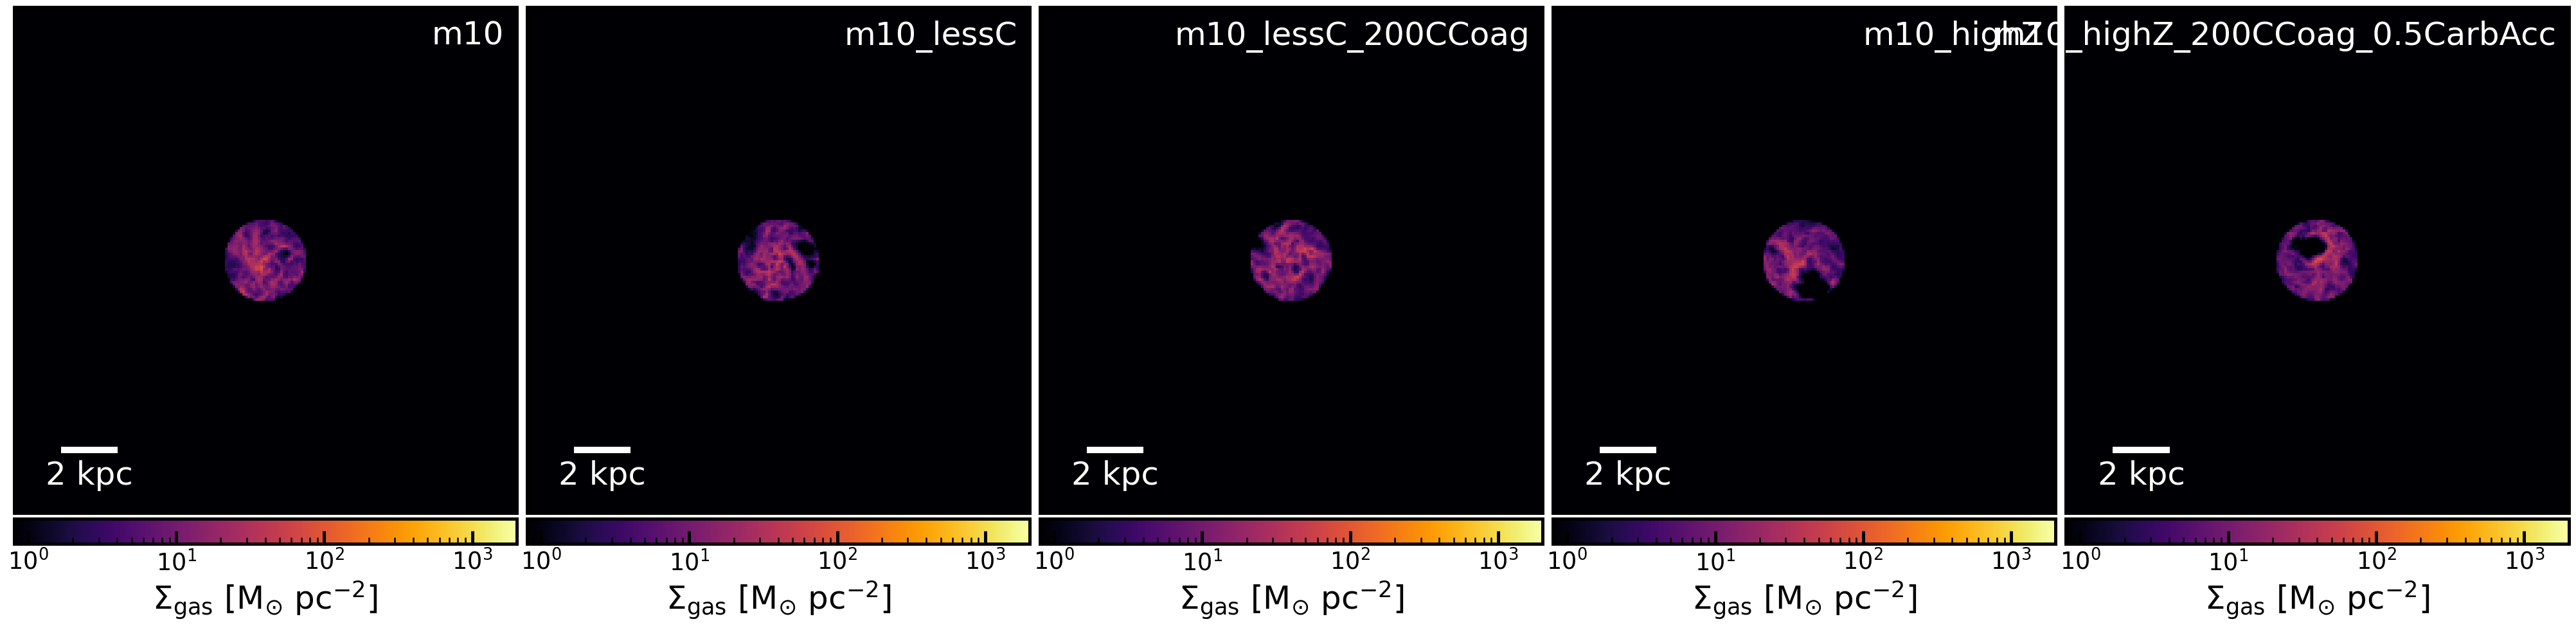

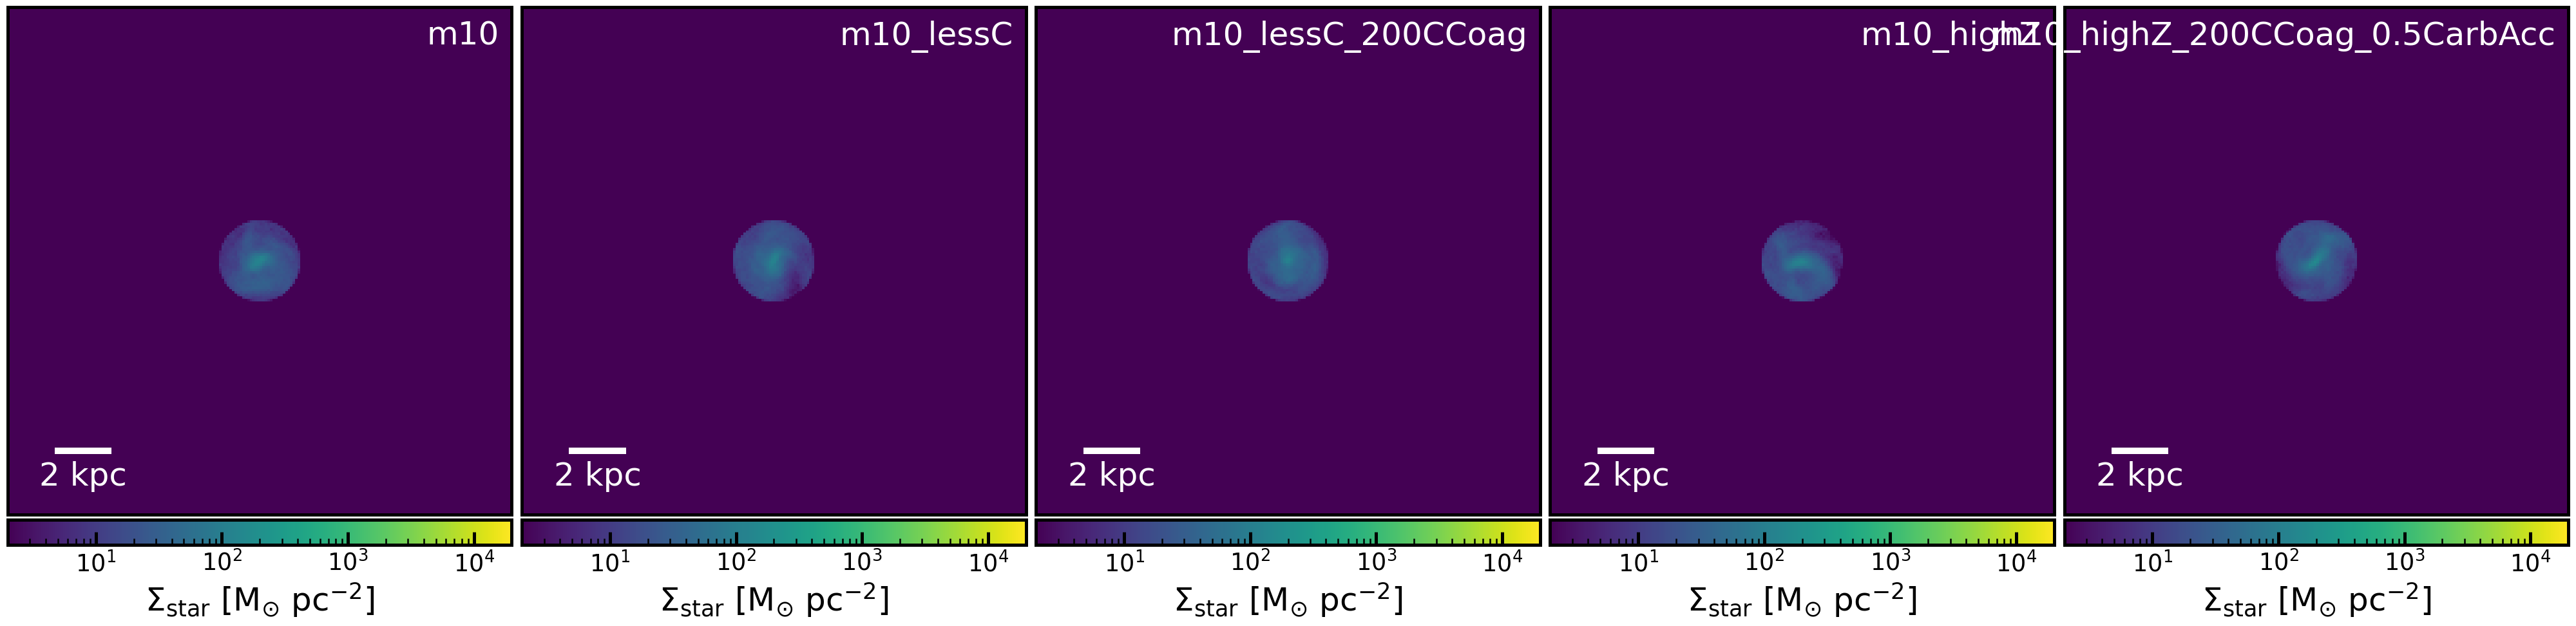

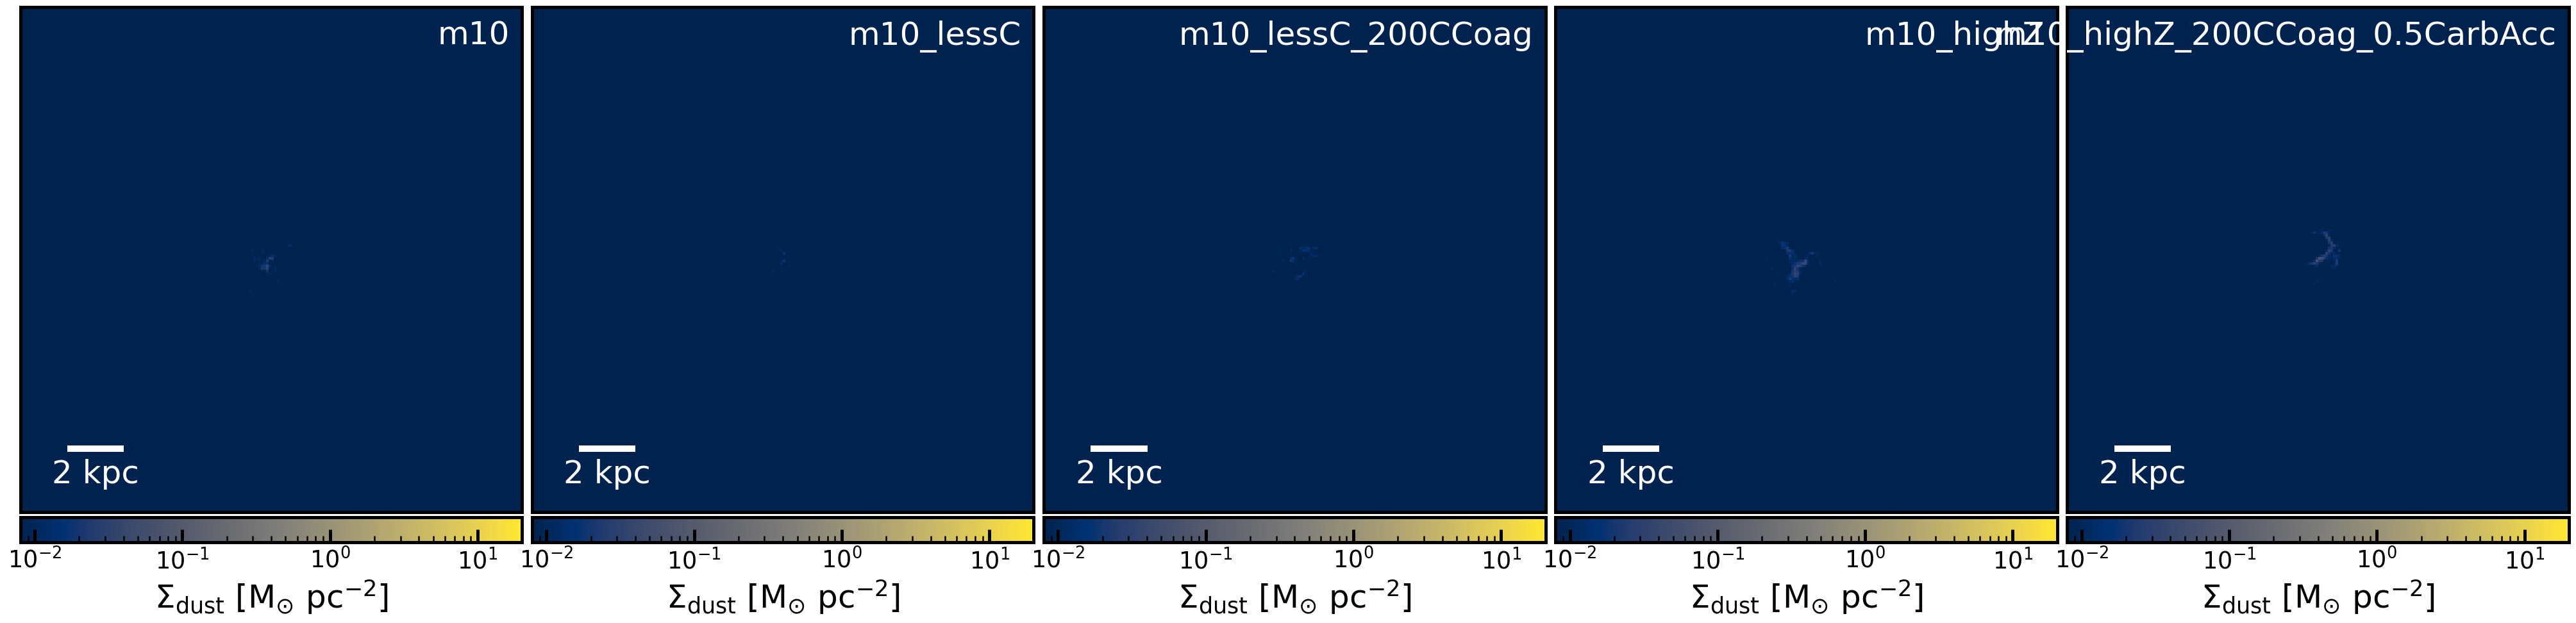

In [34]:

foutname = 'projections.pdf'

# Physical size of projection 
proj_L = 15 # kpc
# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
properties = ['sigma_gas','sigma_star','sigma_dust']
# Limits for projection of each property. Defaults if not set
prop_limits = [[8E-1,2E3],[2E0,2E4],[8E-3,2E1]]
# Colormaps for each projection
prop_cmaps = ['inferno','viridis','cividis','inferno']
# Do you want log colormaps for each property (default = True)
log_cmaps = [True]*len(properties)
# Labels for each projection is so desired
labels = ['gas','stars','dust','young stars']
# Physical size of projection 
proj_L = 20 # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = False
# size of secondary projection
sub_L = 4 # kpc

     
# Create projections for each property and plot the projection
for j,prop in enumerate(properties):
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,1]
    new_proj = Projection(len(galaxies), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)

    for i,halo in enumerate(galaxies):
        sp = halo.sp
        print(sp.sdir)
        name = sim_names[i]

        new_proj.set_proj_axis(i, prop, L, axes_visible=False)
        # Create x-y projection using a 2D histogram
        main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(prop, halo, [L,L,L], pixel_res=pixel_res, proj='xy')
        if sub_proj:
            # Create x-z subprojection using a 2D histogram
            sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(prop, halo, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
        else:
            sub_pixel_stats=None; sub_extent=None
        # x-z projection
        # Create the projection
        if labels is not None:
            label = name
        else:
            label=None
        new_proj.plot_projection(i, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                    cmap= prop_cmaps[j], v_limits = prop_limits[j],v_log=log_cmaps[j], label=label)
            
    new_proj.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+prop+'_'+foutname)

#### Comparing gas phase diagram when accounting for clumping factor.

/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m12_200CCoag/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m11_200CCoag/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ/output
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ_200CCoag_0.25CarbAcc/output


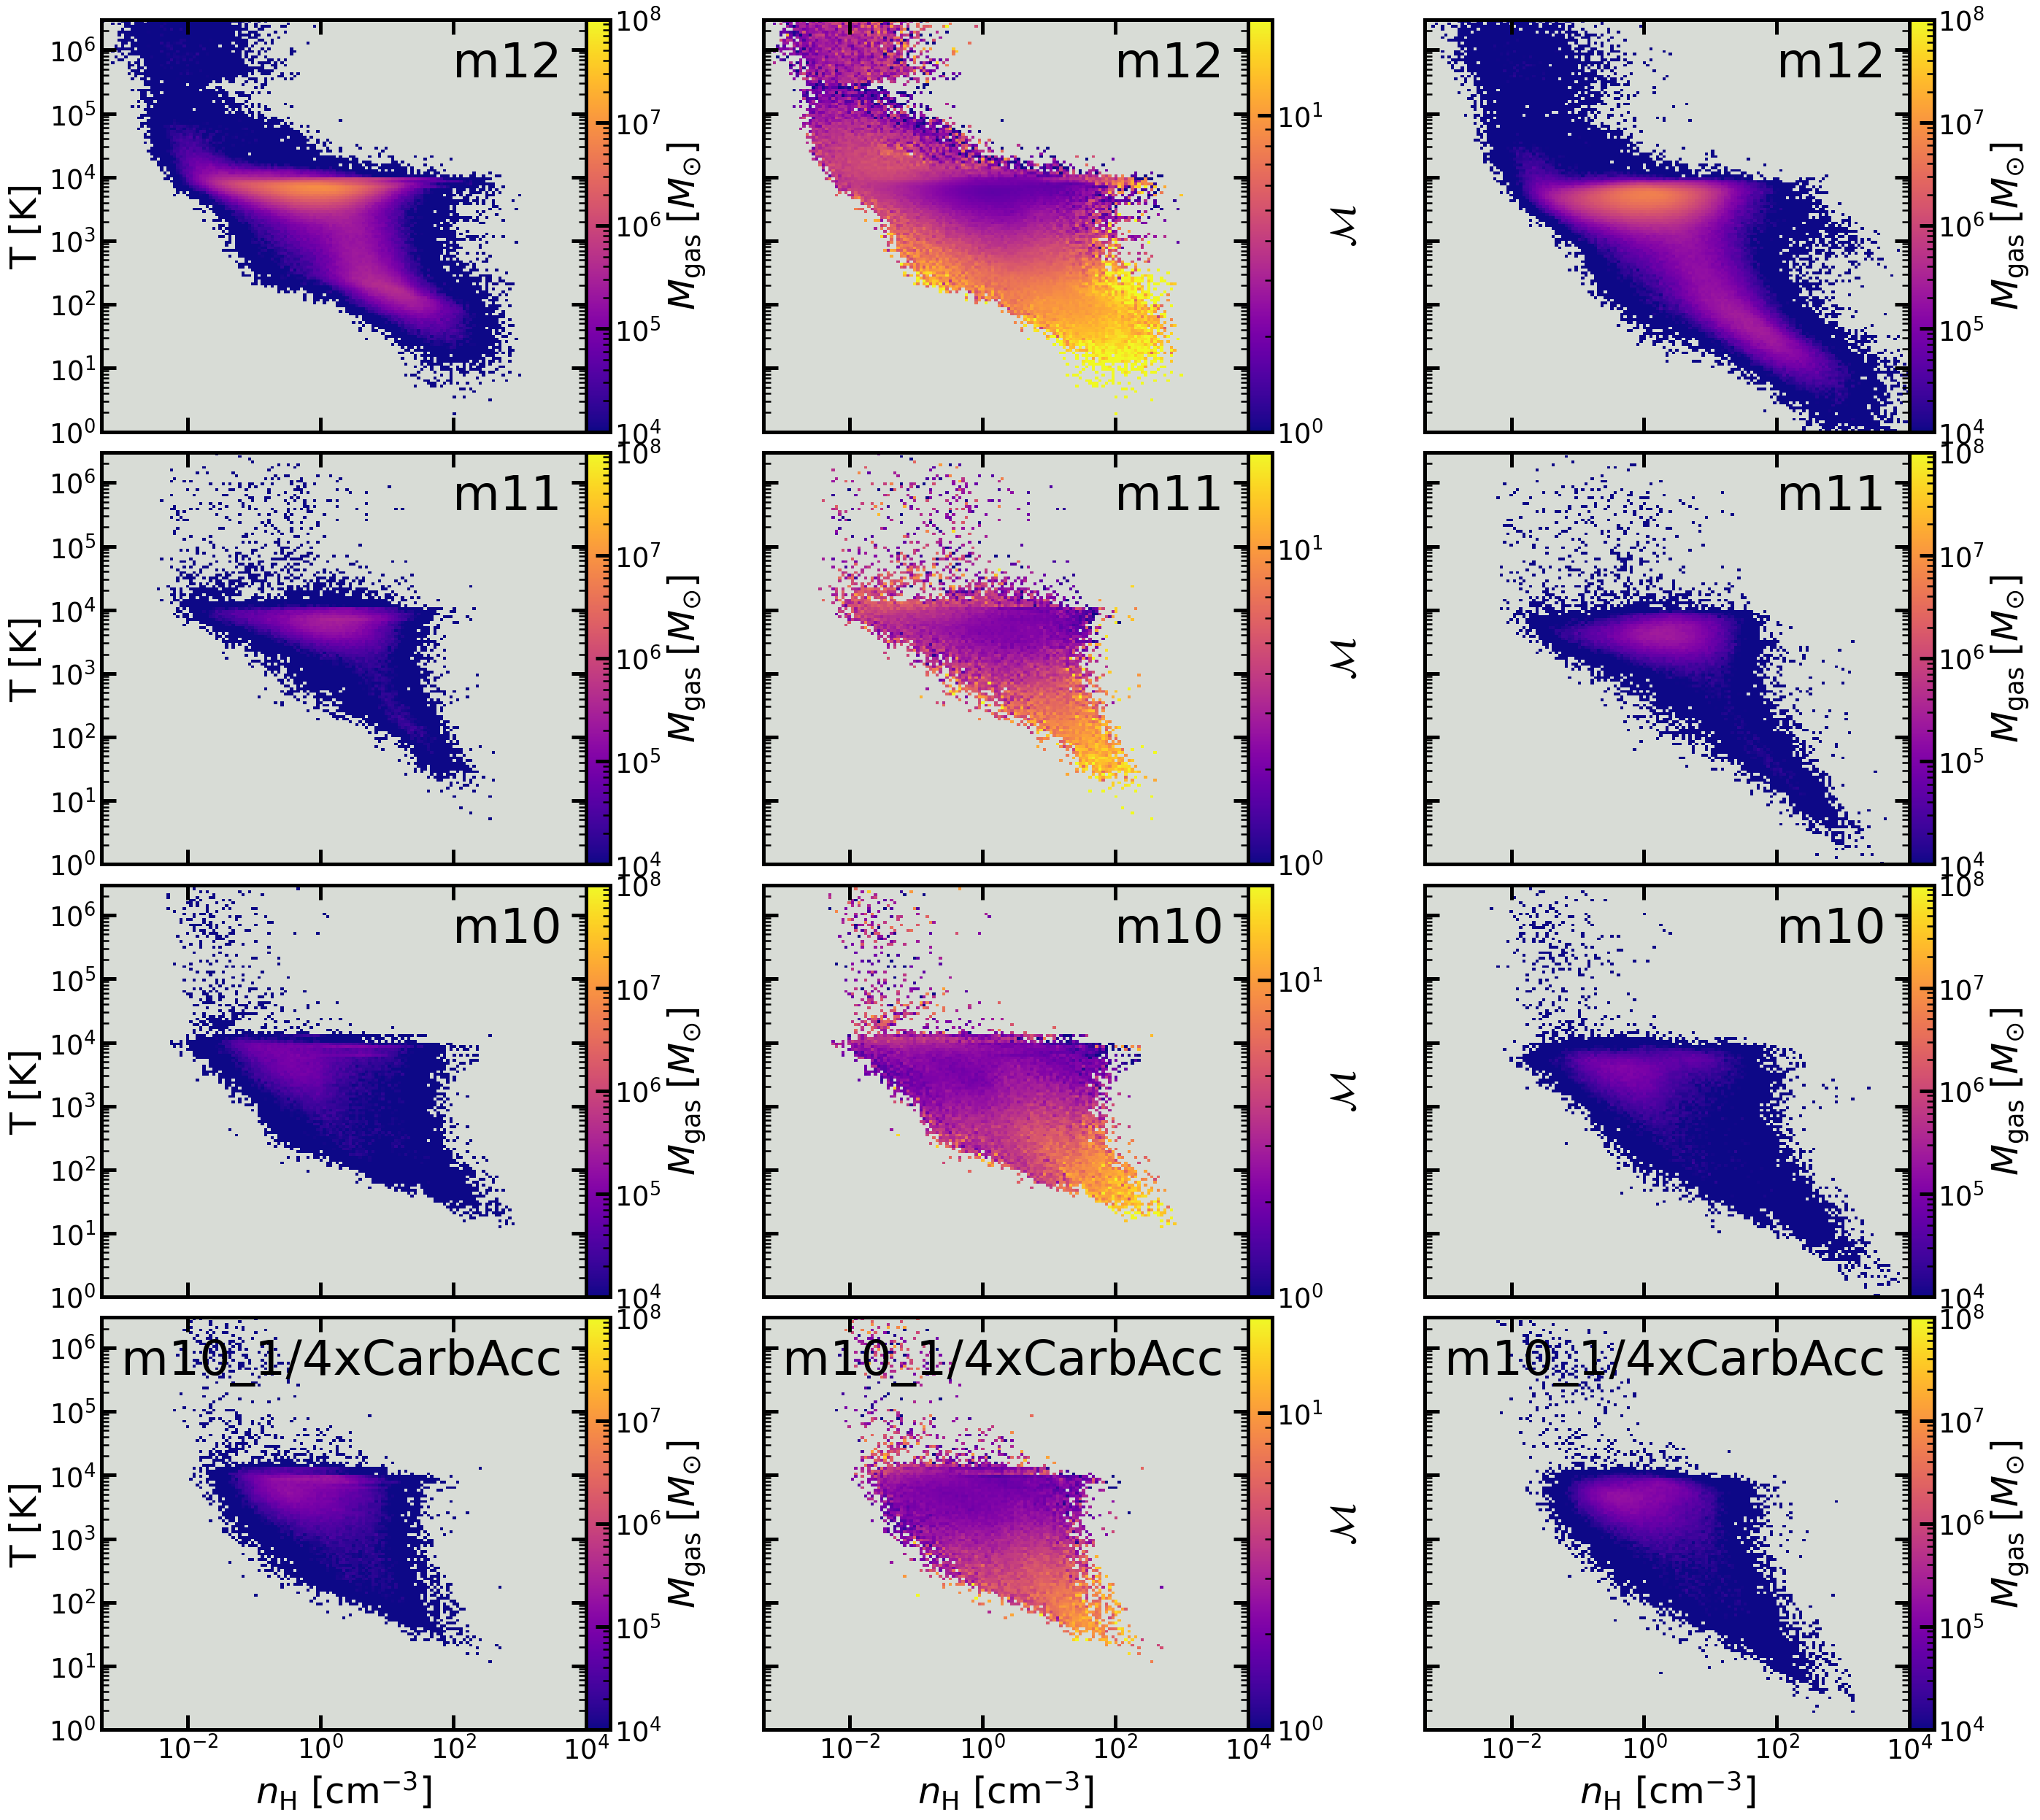

In [90]:
foutname = 'clumping_factor_phase_diagram.pdf'
prop = 'M_gas'
z_logs=[True]
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [1,3E6]

prop_lims=[[1E4,1E8],[1,20],[1E4,1E8]]
num_props = 3

fig = Figure(num_props*len(galaxies),ncols=num_props, sharey=True, sharex=True)

for i,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]

    j=0
    # Set up for each plot
    fig.set_axis(i*num_props+j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(i*num_props+j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[0],label=name)

    # Add colorbar to last axis
    fig.add_colorbar(i*num_props+j,cbar_prop=prop)

    j+=1
    # Set up for each plot
    fig.set_axis(i*num_props+j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data('mach_number', halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(i*num_props+j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[0],label=name)

    # Add colorbar to last axis
    fig.add_colorbar(i*num_props+j,cbar_prop='mach_number')


    j+=1
    # Set up for each plot
    fig.set_axis(i*num_props+j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=True)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(i*num_props+j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[0],label=name)

    # Add colorbar to last axis
    fig.add_colorbar(i*num_props+j,cbar_prop=prop)


    fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

#### D/Z Trends with Gas Density and Temperature

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/variations/no_subtimesteps/output
/N/project/choban_group/cchoban/size_evo_suite/variations/no_Ceff/output
/N/project/choban_group/cchoban/size_evo_suite/variations/NoStarDust/output


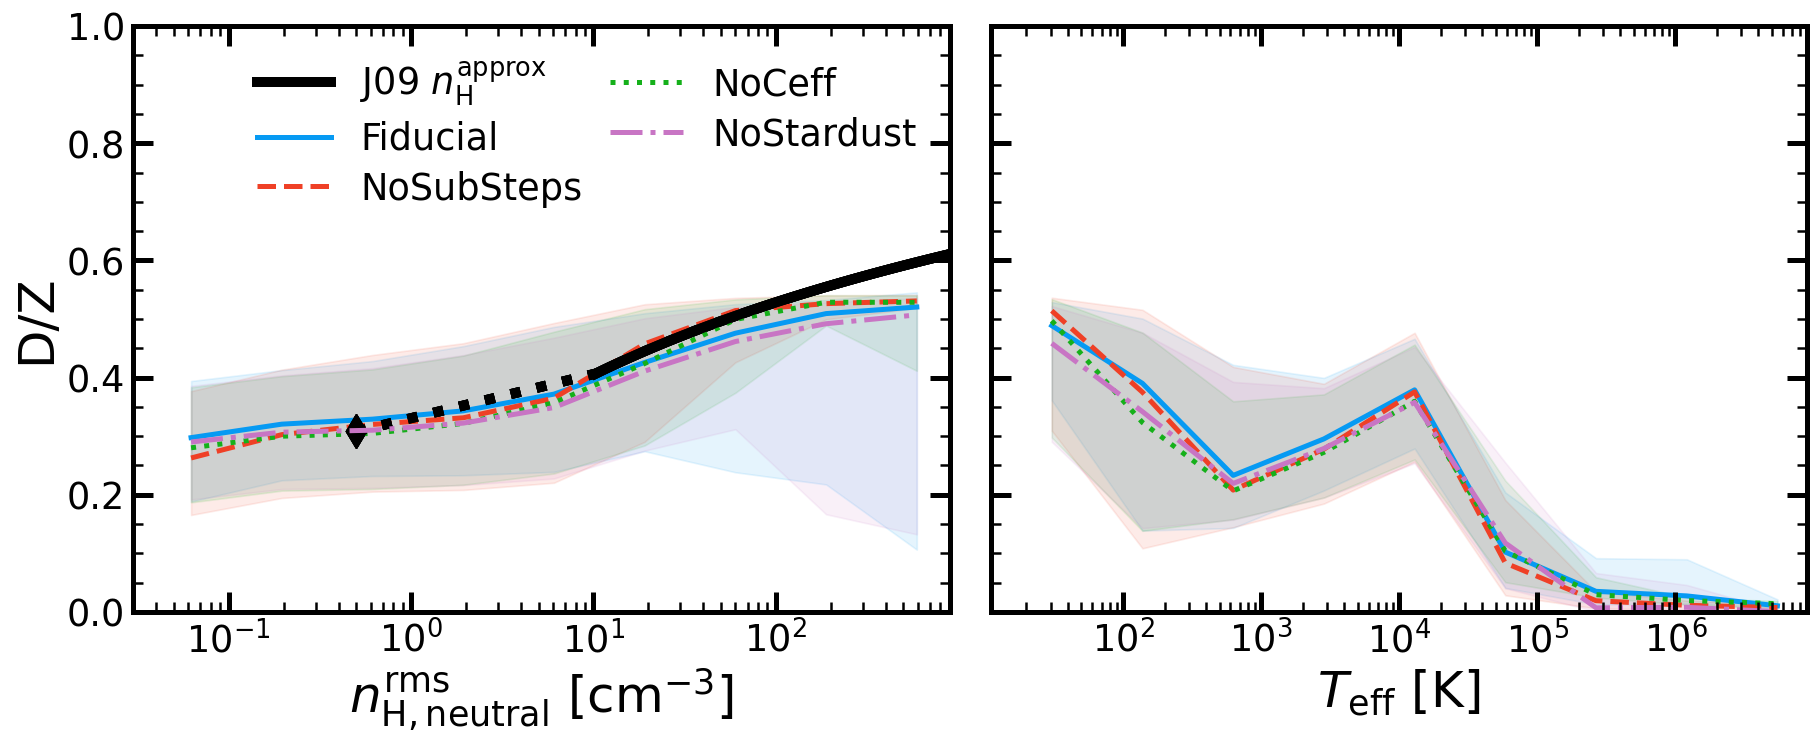

In [14]:


include_observations = True

# Flag to account for clumping in nH and T
clumping_flag = True

if clumping_flag: foutname = 'DZ_vs_rmsdens_Teff.pdf'
else: foutname = 'DZ_vs_dens_T.pdf'

alpha=0.1

num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
bin_nums=10

# Setup figure
fig = Figure(2,ncols=2, sharey='row')
nH_prop = 'nH_neutral_rms' if clumping_flag else 'nH_neutral'
T_prop = 'T_eff' if clumping_flag else 'T'
fig.set_axis(0, nH_prop, 'D/Z', y_lim=[0,1],y_log=False)
fig.set_axis(1, T_prop, 'D/Z', y_lim=[0,1],y_log=False)

for i,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]
    gas = halo.loadpart(0)



    if include_observations:
        density_vals, DZ_vals = obs.Jenkins_2009_DZ_vs_dens(phys_dens=True, elem='Z')
        fig.plot_line_data(0, density_vals, DZ_vals, label=r'J09 $n_{\rm H}^{\rm approx}$', color='xkcd:black',linestyle='-',linewidth=linewidth)
        WNM_dens, WNM_DZ, WNM_error = obs.Jenkins_Savage_2009_WNM_Depl('Z')
        fig.plot_line_data(0, [WNM_dens,density_vals[0]], [WNM_DZ,DZ_vals[0]], color='xkcd:black',linestyle=':',linewidth=linewidth)
        fig.plot_scatter_data(0, [WNM_dens], [WNM_DZ], c='xkcd:black',marker='d',s=2*config.BASE_MARKERSIZE)


    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,'D/Z',nH_prop,bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label = name)
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,'D/Z',T_prop,bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label = name)
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)

fig.set_all_legends()
fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)


/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/variations/NoCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/10xVCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/NoVCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/10xCCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/100xCCoag/output


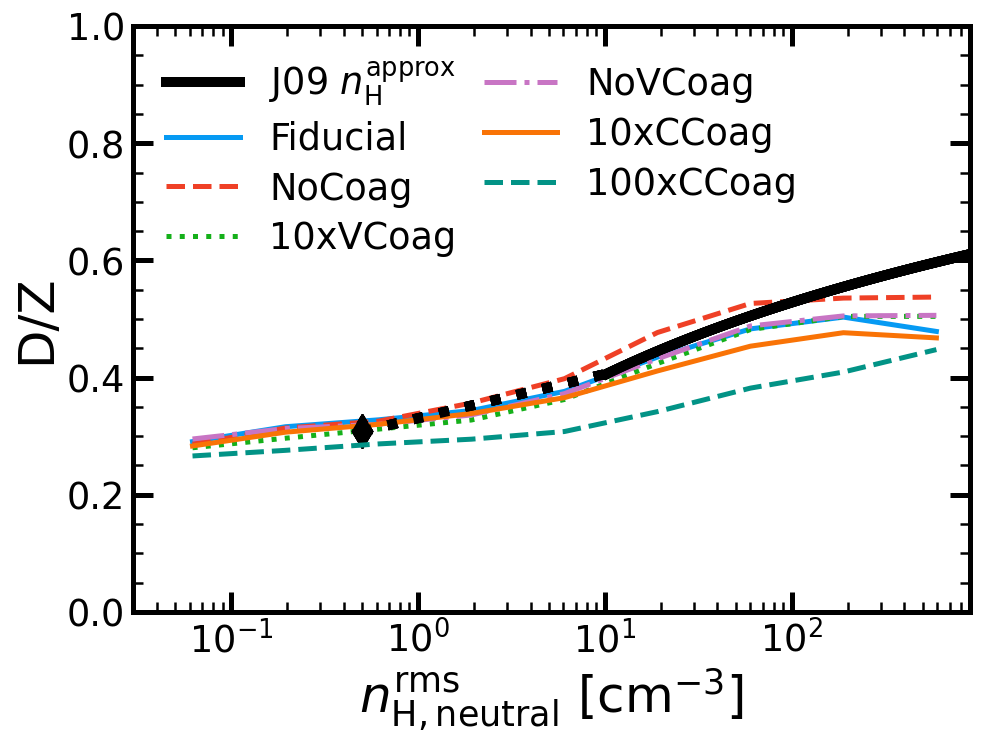

In [35]:


include_observations = True

# Flag to account for clumping in nH and T
clumping_flag = True

if clumping_flag: foutname = 'DZ_vs_rmsdens.pdf'
else: foutname = 'DZ_vs_dens.pdf'

alpha=0.1

num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
bin_nums=10

# Setup figure
fig = Figure(1, sharey='row')
nH_prop = 'nH_neutral_rms' if clumping_flag else 'nH_neutral'
fig.set_axis(0, nH_prop, 'D/Z', y_lim=[0,1],y_log=False)

for i,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]
    gas = halo.loadpart(0)



    if include_observations:
        density_vals, DZ_vals = obs.Jenkins_2009_DZ_vs_dens(phys_dens=True, elem='Z')
        fig.plot_line_data(0, density_vals, DZ_vals, label=r'J09 $n_{\rm H}^{\rm approx}$', color='xkcd:black',linestyle='-',linewidth=linewidth)
        WNM_dens, WNM_DZ, WNM_error = obs.Jenkins_Savage_2009_WNM_Depl('Z')
        fig.plot_line_data(0, [WNM_dens,density_vals[0]], [WNM_DZ,DZ_vals[0]], color='xkcd:black',linestyle=':',linewidth=linewidth)
        fig.plot_scatter_data(0, [WNM_dens], [WNM_DZ], c='xkcd:black',marker='d',s=2*config.BASE_MARKERSIZE)


    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,'D/Z',nH_prop,bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label = name)
    # fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)

fig.set_all_legends()
fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)


#### STL Trend with Density and Temperature

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
/N/project/choban_group/cchoban/size_evo_suite/variations/NoCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/10xVCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/NoVCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/10xCCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/20xCCoag/output
/N/project/choban_group/cchoban/size_evo_suite/variations/100xCCoag/output


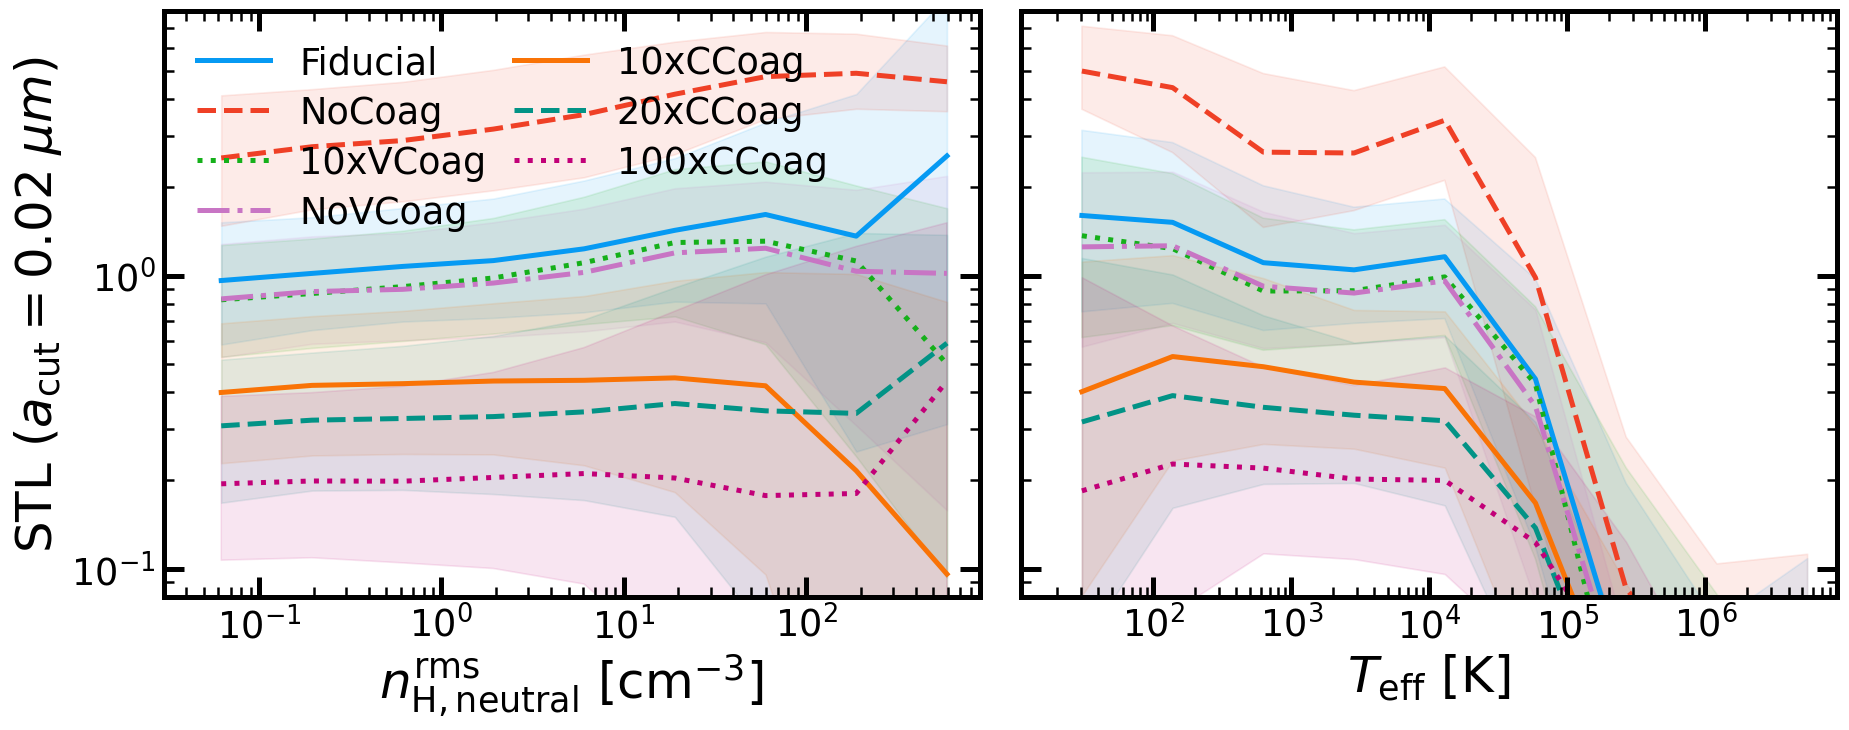

In [84]:


# Flag to account for clumping in nH and T
clumping_flag = True

# Small to large grain cutoff
a_small = 0.02 # micron
y_label = r'STL ($a_{\rm cut}=%2g\;\mu m$)'%a_small


if clumping_flag: foutname = 'STL_vs_rmsdens_Teff.pdf'
else: foutname = 'DZ_vs_dens_T.pdf'

alpha=0.1


num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
bin_nums=10

# Setup figure
fig = Figure(2,ncols=2, sharey='row')
nH_prop = 'nH_neutral_rms' if clumping_flag else 'nH_neutral'
T_prop = 'T_eff' if clumping_flag else 'T'
fig.set_axis(0, nH_prop, 'S/L', y_lim=[0.08,8],y_log=True, y_label=y_label)
fig.set_axis(1, T_prop, 'S/L', y_lim=[0.08,8],y_log=True, y_label=y_label)

for i,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]
    gas = halo.loadpart(0)



    grain_bin_mass = gas.get_property('grain_bin_mass')
    large_bins = halo.sp.Grain_Bin_Centers > a_small
    small_bins = ~large_bins
    large_grain_bin_mass = np.sum(grain_bin_mass[:,:,large_bins],axis=(1,2))
    small_grain_bin_mass = np.sum(grain_bin_mass[:,:,small_bins],axis=(1,2))
    prop_data = small_grain_bin_mass / large_grain_bin_mass            


    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,prop_data,nH_prop,bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label = name)
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,prop_data,T_prop,bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label = name)
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)

fig.set_all_legends()
fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)


#### Depletion Trends

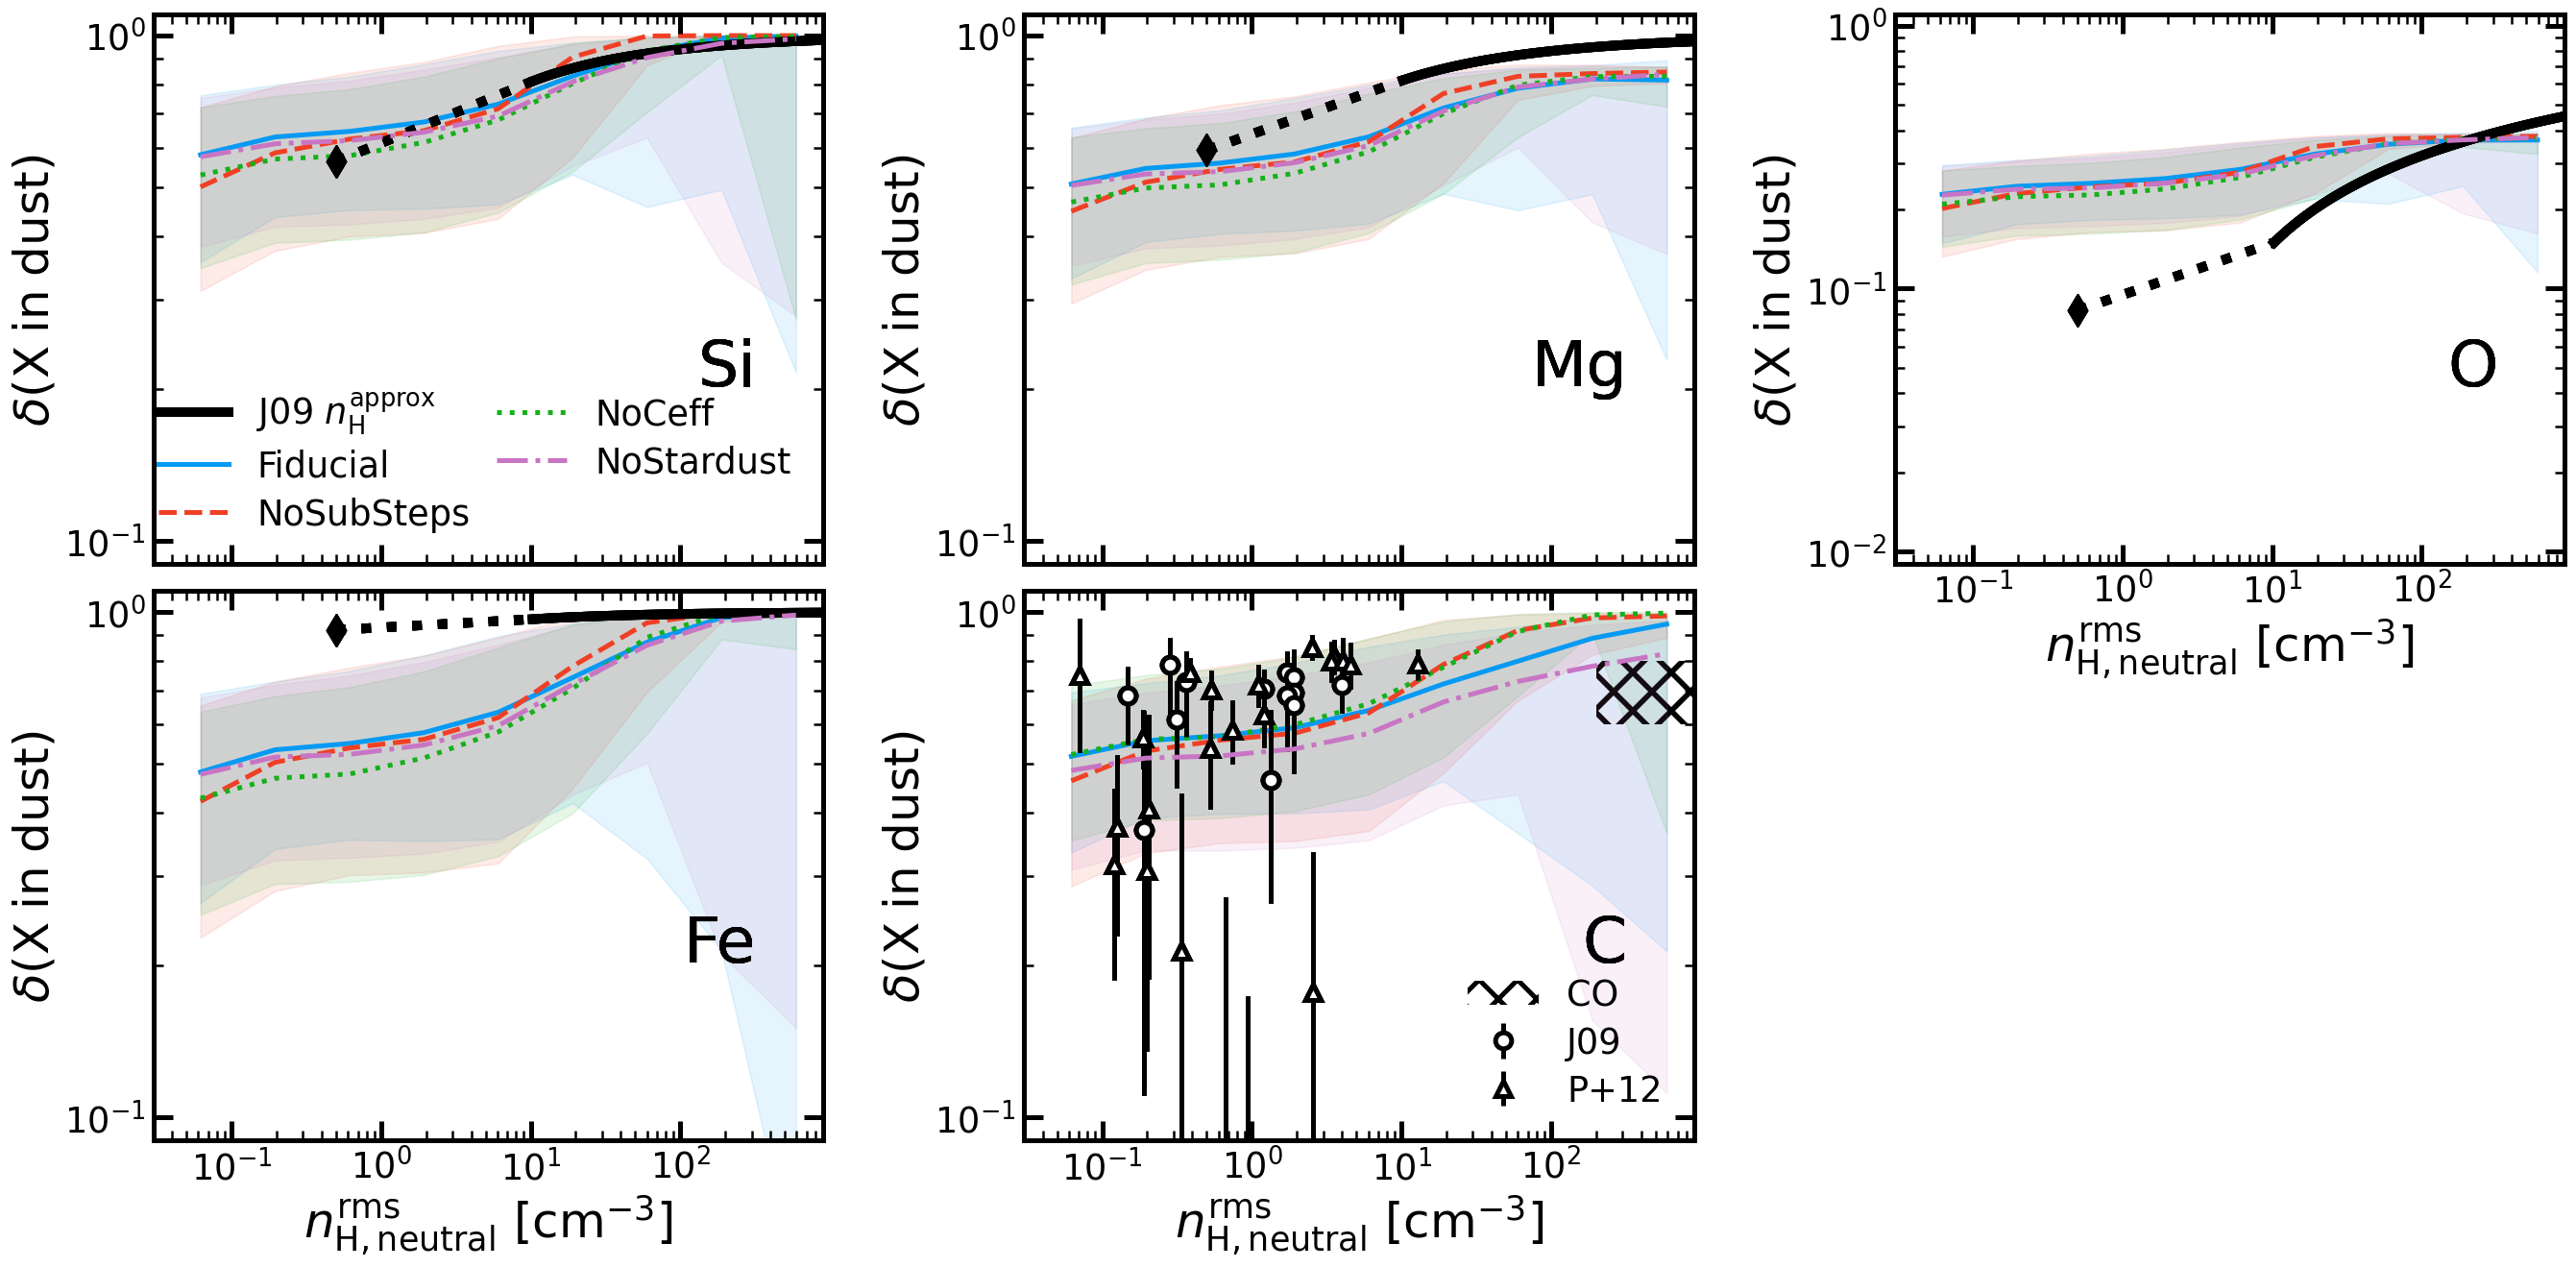

In [15]:


# Set if you want to plot elements in dust instead of elements missing from gas
element_in_dust = True
# Flag to account for clumping in nH and T
clumping_flag = True
# Include Jenkins 09 observations
include_observations = True

if element_in_dust: depl_str = 'dust_depletion'
else: depl_str = 'gas_depletion'
if clumping_flag: dens_str = 'rms_density'
else: dens_str = 'density'
foutname = depl_str + '_' + dens_str + '_trends.pdf'

elements= ['Si','Mg','O','Fe','C']
if element_in_dust:
    depl_lims = [[0.9E-1,1.1],[0.9E-1,1.1],[0.9E-2,1.1],[0.9E-1,1.1],[0.9E-1,1.1]]
else:
    depl_lims = [[0.9E-2,1.1],[0.9E-2,1.1],[0.9E-1,1.1],[0.9E-2,1.1],[0.9E-1,1.1]]
num_elems = len(elements)


alpha=0.1

num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH


nH_prop = 'nH_neutral_rms' if clumping_flag else 'nH_neutral'
depl_prop = 'dust_depletion' if element_in_dust else 'gas_depletion'

fig = Figure(num_elems,ncols=3,sharex='col')

for j,elem in enumerate(elements): 
    fig.set_axis(j, nH_prop, depl_prop, y_lim = depl_lims[j])

    for i,halo in enumerate(galaxies):
        sp = halo.sp
        #print(sp.sdir)
        sim_name = sim_names[i]

        gas = halo.loadpart(0)


        if include_observations:
            # Data is so scarce for C only plot the observed sightlines as a lower limit.
            if elem == 'C':
                J09_C_depl, J09_C_err, J09_C_density = obs.Jenkins_2009_Elem_Depl(elem,density='<nH>')      
                P12_C_depl, P12_C_err, P12_C_density = obs.Parvathi_2012_C_Depl(solar_abund='max', density='<nH>')
                # Used for expected C in CO hatched region
                CO_density = np.array([2E2,1E4])
                CO_depl_min = np.array([0.2,0.2])
                CO_depl_max = np.array([0.4,0.4])

                if element_in_dust:
                    J09_C_depl = 1-J09_C_depl
                    P12_C_depl = 1-P12_C_depl
                    CO_depl_min = 1-CO_depl_min
                    CO_depl_max = 1-CO_depl_max


                fig.plot_errorbar_data(j, J09_C_density, J09_C_depl, y_err = J09_C_err, c='xkcd:black',fmt='o',label='J09')    
                fig.plot_errorbar_data(j, P12_C_density, P12_C_depl, y_err = P12_C_err, c='xkcd:black',fmt='^',label='P+12')
                # Add in shaded region for 20-40% of C in CO bars
                fig.plot_shaded_region(j, CO_density,CO_depl_min, CO_depl_max, color="none", hatch="x", edgecolor="xkcd:black", lw=0,
							  label='CO', alpha=1)
 
            else:
                density_vals, dust_depl_vals = obs.Jenkins_2009_DZ_vs_dens(phys_dens=True, elem=elem)
                WNM_dens, WNM_depl, WNM_error = obs.Jenkins_Savage_2009_WNM_Depl(elem)

                if not element_in_dust:
                    dust_depl_vals = 1-dust_depl_vals
                    WNM_depl = 1-WNM_depl

                fig.plot_line_data(j, density_vals, dust_depl_vals, label=r'J09 $n_{\rm H}^{\rm approx}$', color='xkcd:black',linestyle='-',linewidth=linewidth)
                fig.plot_line_data(j, [WNM_dens,density_vals[0]], [WNM_depl,dust_depl_vals[0]], color='xkcd:black',linestyle=':',linewidth=linewidth)
                fig.plot_scatter_data(j, [WNM_dens], [WNM_depl], c='xkcd:black',marker='d',s=2*config.BASE_MARKERSIZE)
        
        if element_in_dust:
            fig.add_text(j, 0.9, 0.3, elem, rescale_font=1,ha='right',va='bottom')
        else:
            fig.add_text(j, 0.1, 0.1, elem, rescale_font=1,ha='left',va='bottom')

        bin_nums=10
        depl_values = (gas.get_property('dust_Z')/gas.get_property('Z_all')[:,:11])[:,config.ELEMENTS.index(elem)]
        if not element_in_dust:
            depl_values=1-depl_values

        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,depl_values, nH_prop, bin_nums=bin_nums)
        fig.plot_line_data(j,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label=sim_name)
        fig.plot_shaded_region(j,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)
       
    if element_in_dust: loc = 'lower right'
    else: loc = 'best'
    fig.set_all_legends(loc=loc)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)


#### D/Z and Depletion Trends

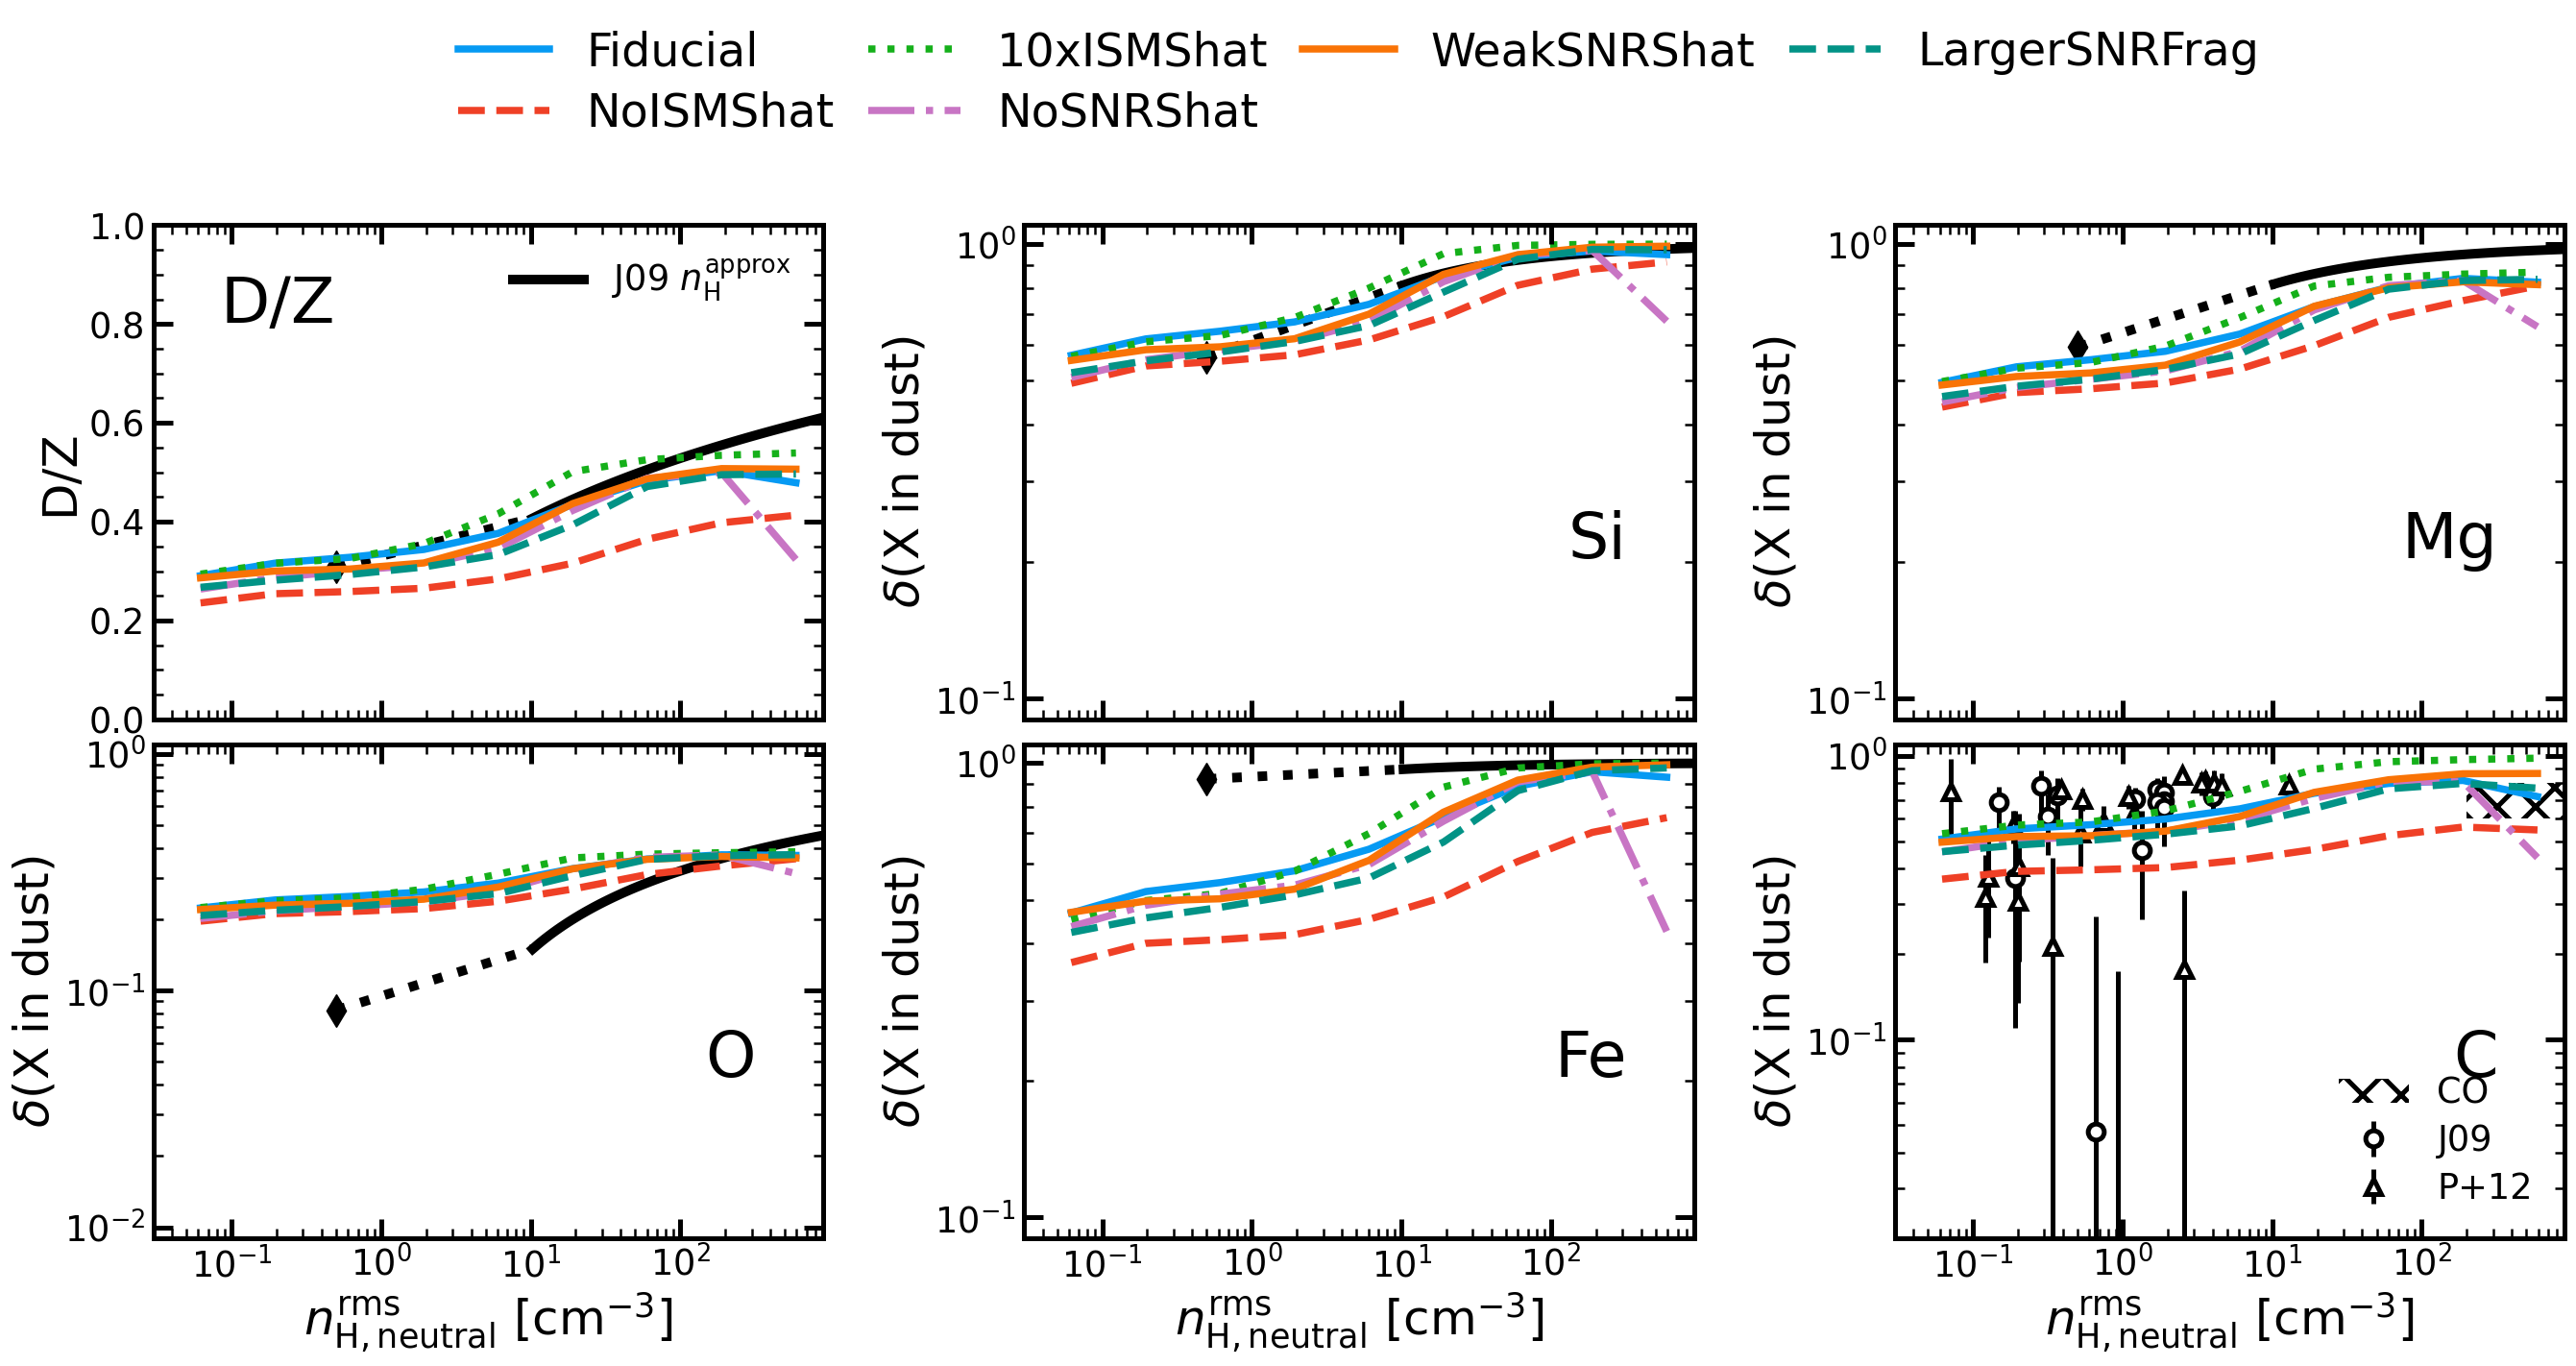

In [9]:


# Set if you want to plot elements in dust instead of elements missing from gas
element_in_dust = True
# Flag to account for clumping in nH and T
clumping_flag = True
# Include Jenkins 09 observations
include_observations = True
include_LMC_SMC = False

LMC_color = 'xkcd:goldenrod'
SMC_color = 'xkcd:lilac'

if element_in_dust: depl_str = 'DZ_dust_depletion'
else: depl_str = 'DZ_gas_depletion'
if clumping_flag: dens_str = 'rms_density'
else: dens_str = 'density'
foutname = depl_str + '_' + dens_str + '_trends.pdf'

elements= ['D/Z','Si','Mg','O','Fe','C']
if element_in_dust:
    depl_lims = [[0,1],[0.9E-1,1.1],[0.9E-1,1.1],[0.9E-2,1.1],[0.9E-1,1.1],[0.2E-1,1.1]]
else:
    depl_lims = [[0,1],[0.9E-2,1.1],[0.9E-2,1.1],[0.9E-1,1.1],[0.9E-2,1.1],[0.2E-1,1.1]]
num_elems = len(elements)

nH_lims = [3E-2, 0.9E3]

alpha=0.0

num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH


nH_prop = 'nH_neutral_rms' if clumping_flag else 'nH_neutral'
depl_prop = 'dust_depletion' if element_in_dust else 'gas_depletion'

fig = Figure(num_elems,ncols=3,sharex='col', yx_ratio=0.9)

for j,elem in enumerate(elements): 
    if elem == 'D/Z': 
        fig.set_axis(j, nH_prop, elem, y_lim = depl_lims[j],y_log=False, x_lim = nH_lims)
    else:
        fig.set_axis(j, nH_prop, depl_prop, y_lim = depl_lims[j],y_log=True, x_lim = nH_lims)

    if include_observations:
        # Data is so scarce for C only plot the observed sightlines as a lower limit.
        if elem == 'C':
            J09_C_depl, J09_C_err, J09_C_density = obs.Jenkins_2009_Elem_Depl(elem,density='<nH>')      
            P12_C_depl, P12_C_err, P12_C_density = obs.Parvathi_2012_C_Depl(solar_abund='max', density='<nH>')
            # Used for expected C in CO hatched region
            CO_density = np.array([2E2,1E4])
            CO_depl_min = np.array([0.2,0.2])
            CO_depl_max = np.array([0.4,0.4])

            if element_in_dust:
                J09_C_depl = 1-J09_C_depl
                P12_C_depl = 1-P12_C_depl
                CO_depl_min = 1-CO_depl_min
                CO_depl_max = 1-CO_depl_max


            fig.plot_errorbar_data(j, J09_C_density, J09_C_depl, y_err = J09_C_err, c='xkcd:black',fmt='o',label='J09',zorder=1)    
            fig.plot_errorbar_data(j, P12_C_density, P12_C_depl, y_err = P12_C_err, c='xkcd:black',fmt='^',label='P+12',zorder=1)
            # Add in shaded region for 20-40% of C in CO bars
            fig.plot_shaded_region(j, CO_density,CO_depl_min, CO_depl_max, color="none", hatch="x", edgecolor="xkcd:black", lw=0,
                            label='CO', alpha=1)
            fig.set_axis_legend(j, ncol=1)
        elif elem == 'D/Z':
            density_vals, DZ_vals = obs.Jenkins_2009_DZ_vs_dens(phys_dens=True, elem='Z')
            fig.plot_line_data(j, density_vals, DZ_vals, label=r'J09 $n_{\rm H}^{\rm approx}$', color='xkcd:black',linestyle='-',linewidth=linewidth)
            WNM_dens, WNM_DZ, WNM_error = obs.Jenkins_Savage_2009_WNM_Depl('Z')
            fig.plot_line_data(j, [WNM_dens,density_vals[0]], [WNM_DZ,DZ_vals[0]], color='xkcd:black',linestyle=':',linewidth=linewidth)
            fig.plot_scatter_data(j, [WNM_dens], [WNM_DZ], c='xkcd:black',marker='d',s=2*config.BASE_MARKERSIZE)
            

            # D/Z values for LMC and SMC from Roman-Duval METALS
            if include_LMC_SMC:
                DZ_LMC = 0.34; DZ_SMC = 0.16;
                LMC_limits = [0.26,0.41]; SMC_limits = [0.071,0.25]
                LMC_err = np.abs([[DZ_LMC-LMC_limits[0]],[DZ_LMC-LMC_limits[1]]]); SMC_err = np.abs([[DZ_SMC-SMC_limits[0]],[DZ_SMC-SMC_limits[1]]])

                # Unseen smaller markers for legend to avoid crowded legend
                fig.plot_errorbar_data(j, [6E4], [DZ_LMC], y_err = LMC_err, c=LMC_color,fmt='s', label='LMC')
                fig.plot_errorbar_data(j, [6E4], [DZ_SMC], y_err = SMC_err, c=SMC_color,fmt='d', label='SMC')


                fig.plot_errorbar_data(j, [6E2], [DZ_LMC], y_err = LMC_err, c=LMC_color,fmt='s',
                                       zorder=1,ms=20,elinewidth=2*config.BASE_ELINEWIDTH, mew=2*config.BASE_ELINEWIDTH)
                fig.plot_errorbar_data(j, [6E2], [DZ_SMC], y_err = SMC_err, c=SMC_color,fmt='d',
                                       zorder=1,ms=20,elinewidth=2*config.BASE_ELINEWIDTH, mew=2*config.BASE_ELINEWIDTH)


            fig.set_axis_legend(j,ncol=1)

        else:
            density_vals, dust_depl_vals = obs.Jenkins_2009_DZ_vs_dens(phys_dens=True, elem=elem)
            WNM_dens, WNM_depl, WNM_error = obs.Jenkins_Savage_2009_WNM_Depl(elem)

            if not element_in_dust:
                dust_depl_vals = 1-dust_depl_vals
                WNM_depl = 1-WNM_depl

            fig.plot_line_data(j, density_vals, dust_depl_vals, label=r'J09 $n_{\rm H}^{\rm approx}$', color='xkcd:black',linestyle='-',linewidth=linewidth)
            fig.plot_line_data(j, [WNM_dens,density_vals[0]], [WNM_depl,dust_depl_vals[0]], color='xkcd:black',linestyle=':',linewidth=linewidth)
            fig.plot_scatter_data(j, [WNM_dens], [WNM_depl], c='xkcd:black',marker='d',s=2*config.BASE_MARKERSIZE)
            fig.set_outside_legend(rescale_font=1.3,ncol=4)

            if include_LMC_SMC and elem != 'O':
                depletions, depletion_limits, NH_vals = obs.RomanDuval_2021_LMC_Elem_Depl(elem)
                if depletions is not None:
                    sight_line_dist = 1E3 * config.pc_to_cm
                    nH_approx = NH_vals/sight_line_dist
                    if element_in_dust:
                        depletions = 1-depletions
                        depletion_limits = 1-depletion_limits
                        depletion_limits[depletion_limits<=0]=config.EPSILON
                    fig.plot_errorbar_data(j, nH_approx, depletions, y_err = None, c=LMC_color,fmt='s',zorder=1)
                depletions, depletion_limits, NH_vals = obs.Jenkins_Wallerstein_2017_SMC_Elem_Depl(elem)
                if depletions is not None:
                    sight_line_dist = 1E3 * config.pc_to_cm
                    nH_approx = NH_vals/sight_line_dist
                    if element_in_dust:
                        depletions = 1-depletions
                        depletion_limits = 1-depletion_limits
                        depletion_limits[depletion_limits<=0]=config.EPSILON
                    fig.plot_errorbar_data(j, nH_approx, depletions, y_err = None, c=SMC_color,fmt='d',zorder=1)

        
    if elem == 'D/Z':
        fig.add_text(j, 0.1, 0.9, elem, rescale_font=1,ha='left',va='top')
    else:
        if element_in_dust:
            fig.add_text(j, 0.9, 0.3, elem, rescale_font=1,ha='right',va='bottom')
        else:
            fig.add_text(j, 0.1, 0.1, elem, rescale_font=1,ha='left',va='bottom')
    

    for i,halo in enumerate(galaxies):
        sp = halo.sp
        #print(sp.sdir)
        sim_name = sim_names[i]

        gas = halo.loadpart(0)
        

        bin_nums=10
        if elem == 'D/Z':
            depl_values = gas.get_property('D/Z')
        else:
            depl_values = (gas.get_property('dust_Z')/gas.get_property('Z_all')[:,:11])[:,config.ELEMENTS.index(elem)]
            if not element_in_dust:
                depl_values=1-depl_values

        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas, depl_values, nH_prop, bin_nums=bin_nums, prop_lims=nH_lims)
        fig.plot_line_data(j,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], label=sim_name, linewidth=0.75*linewidth)
        fig.plot_shaded_region(j,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i],alpha=alpha)
       
    if element_in_dust: loc = 'lower right'
    else: loc = 'upper right'
    #fig.set_all_legends(loc=loc)
    #fig.set_outside_legend(rescale_font=1)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)


#### D/Z GSD and Attenuation Curves

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/NoISMShat/output
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/10xISMShat/output
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/NoSNeShat/output
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/WeakSNeShat/output
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/SNeLargerFrag/output
 Will truncate grain sizes beyond supported range.


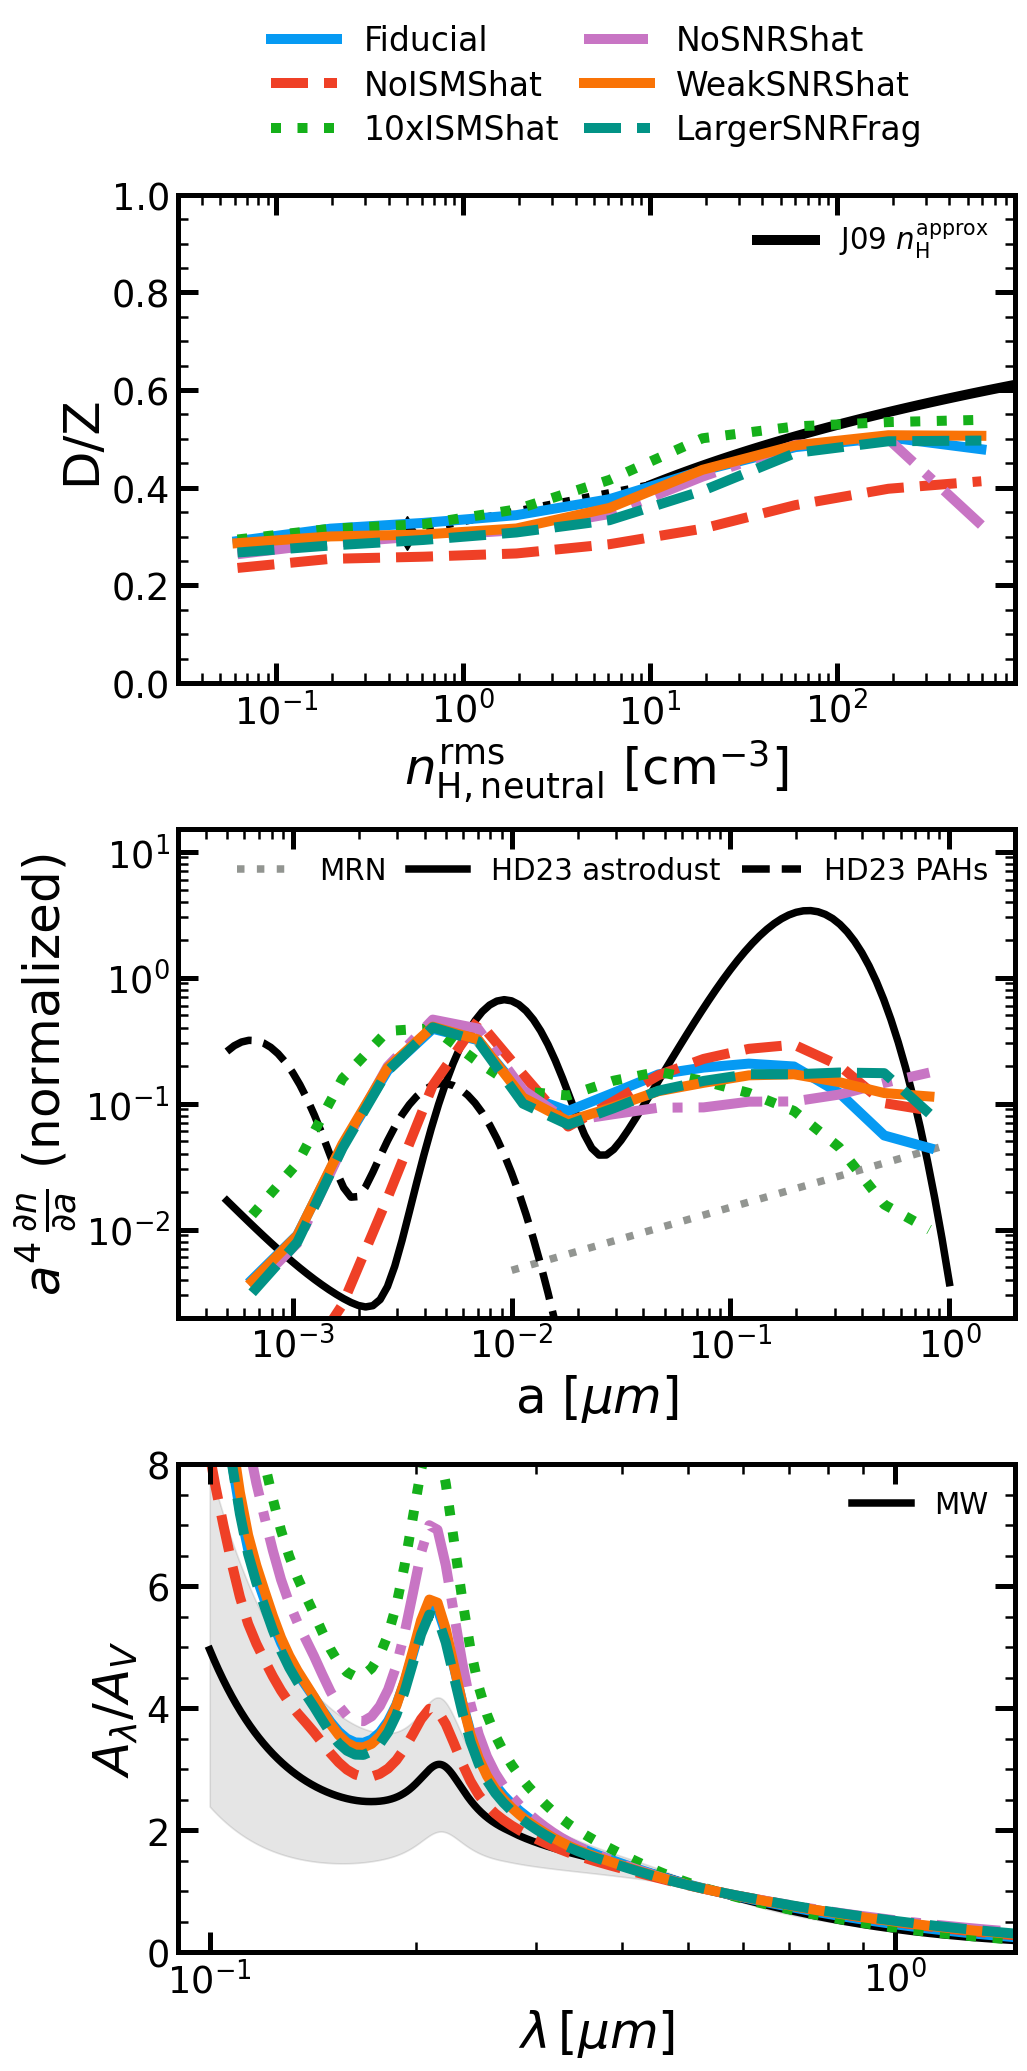

In [40]:
foutname = 'DZ_GSD_AV.pdf'


species='all'
ISM_phase = 'all'

include_Jenkins = True
include_idealized_MRN=True
include_idealized_astrodust=True
include_idealized_DraineLi=False

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

alpha=0.0


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 10

# Flag to account for clumping in nH and T
clumping_flag = True




alpha=0.1
obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha=1


num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
bin_nums=10

# Setup figure
fig = Figure(3,ncols=1)
nH_prop = 'nH_neutral_rms' if clumping_flag else 'nH_neutral'
fig.set_axis(0, nH_prop, 'D/Z', y_lim=[0,1],y_log=False)
fig.set_axis(1, 'grain_size', 'dm/dloga_norm', y_lim=[2E-3,1.5E1])
fig.set_axis(2, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])

i=0
if include_Jenkins:
    density_vals, DZ_vals = obs.Jenkins_2009_DZ_vs_dens(phys_dens=True, elem='Z')
    fig.plot_line_data(i, density_vals, DZ_vals, label=r'J09 $n_{\rm H}^{\rm approx}$', color='xkcd:black',linestyle='-',linewidth=linewidth)
    WNM_dens, WNM_DZ, WNM_error = obs.Jenkins_Savage_2009_WNM_Depl('Z')
    fig.plot_line_data(i, [WNM_dens,density_vals[0]], [WNM_DZ,DZ_vals[0]], color='xkcd:black',linestyle=':',linewidth=obs_linewidth)
    fig.plot_scatter_data(i, [WNM_dens], [WNM_DZ], c='xkcd:black',marker='d',s=2*config.BASE_MARKERSIZE)
fig.set_axis_legend(i,rescale_font=0.8)

i=1
if include_idealized_MRN:
    y_offset = -1.5
    MRN_a_vals = np.logspace(-2,-0,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10.,y_offset)
    fig.plot_line_data(i,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(i,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(i,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
    # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
    # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'astrodust',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
    
    fig.plot_line_data(i,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    
    fig.plot_line_data(i,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)                

# Force all obs size distribution legend elements on first plot
fig.set_axis_legend(i,ncol=3,rescale_font=0.8)

i=2
# Plot observed extinction curves
galaxy_names = ['MW','LMC','LMC_30Dor','SMC']
galaxy_names = ['MW']
obs_colors = ['xkcd:black','xkcd:goldenrod','xkcd:goldenrod','xkcd:lilac']
obs_linestyles = ['-','-','--','-']
subsamples = [0,2,2,2]
for j, galaxy_name in enumerate(galaxy_names):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy_name, subsample=subsamples[j])
    fig.plot_line_data(i,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[j],linestyle=obs_linestyles[j], linewidth=obs_linewidth, label = galaxy_name, std_kwargs={'alpha':0.1})
fig.set_axis_legend(i,rescale_font=0.8)


for i,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[i]
    gas = halo.loadpart(0)

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property(gas,'D/Z',nH_prop,bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[i], linewidth = linewidth ,label = sim_name)

    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    
    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(gas,  
                                                        dust_species=species, 
                                                        mask=mask, 
                                                        points_per_bin=points_per_bin, 
                                                        std_percentiles = [16, 84])

    fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[i],linestyle=linestyles[i], label=sim_name, linewidth=linewidth)
    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(gas,species=species, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    fig.plot_line_data(2,wavelength_points,A_lambda_percentiles[0], color=colors[i],linestyle=linestyles[i], linewidth=linewidth, label = sim_name)

fig.set_outside_legend(rescale_font=0.9,ncol=2,bbox_to_anchor=(0.5, 1.02))
fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)


#### Dust Process Rates Phase Diagram

#### Median Grain size distributions

##### Separate plots with median distributions for all dust and each dust species.

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.2888870e+06 1.2617045e+03 1.5475264e+06 7.9043656e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/NoCSpec/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [5.6874525e+06 1.2648678e+03 1.3366456e+06 7.8477664e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/4xSNeDest/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [2.9736908e+06 4.8775119e+02 1.7637712e+05 3.2325791e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/0.25xSNeDest/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [8.4235070e+06 2.1810427e+03 3.7084665e+06 1.3154017e+05]
/N/project/choban_group/cchoban/size_evo_suite/variations/4xAcc/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [9.4203910e+06 1.3575610e+03 1.7228914e+06 8.4783531e+04]
/N/project/choban_group/cchoban/size_evo_sui

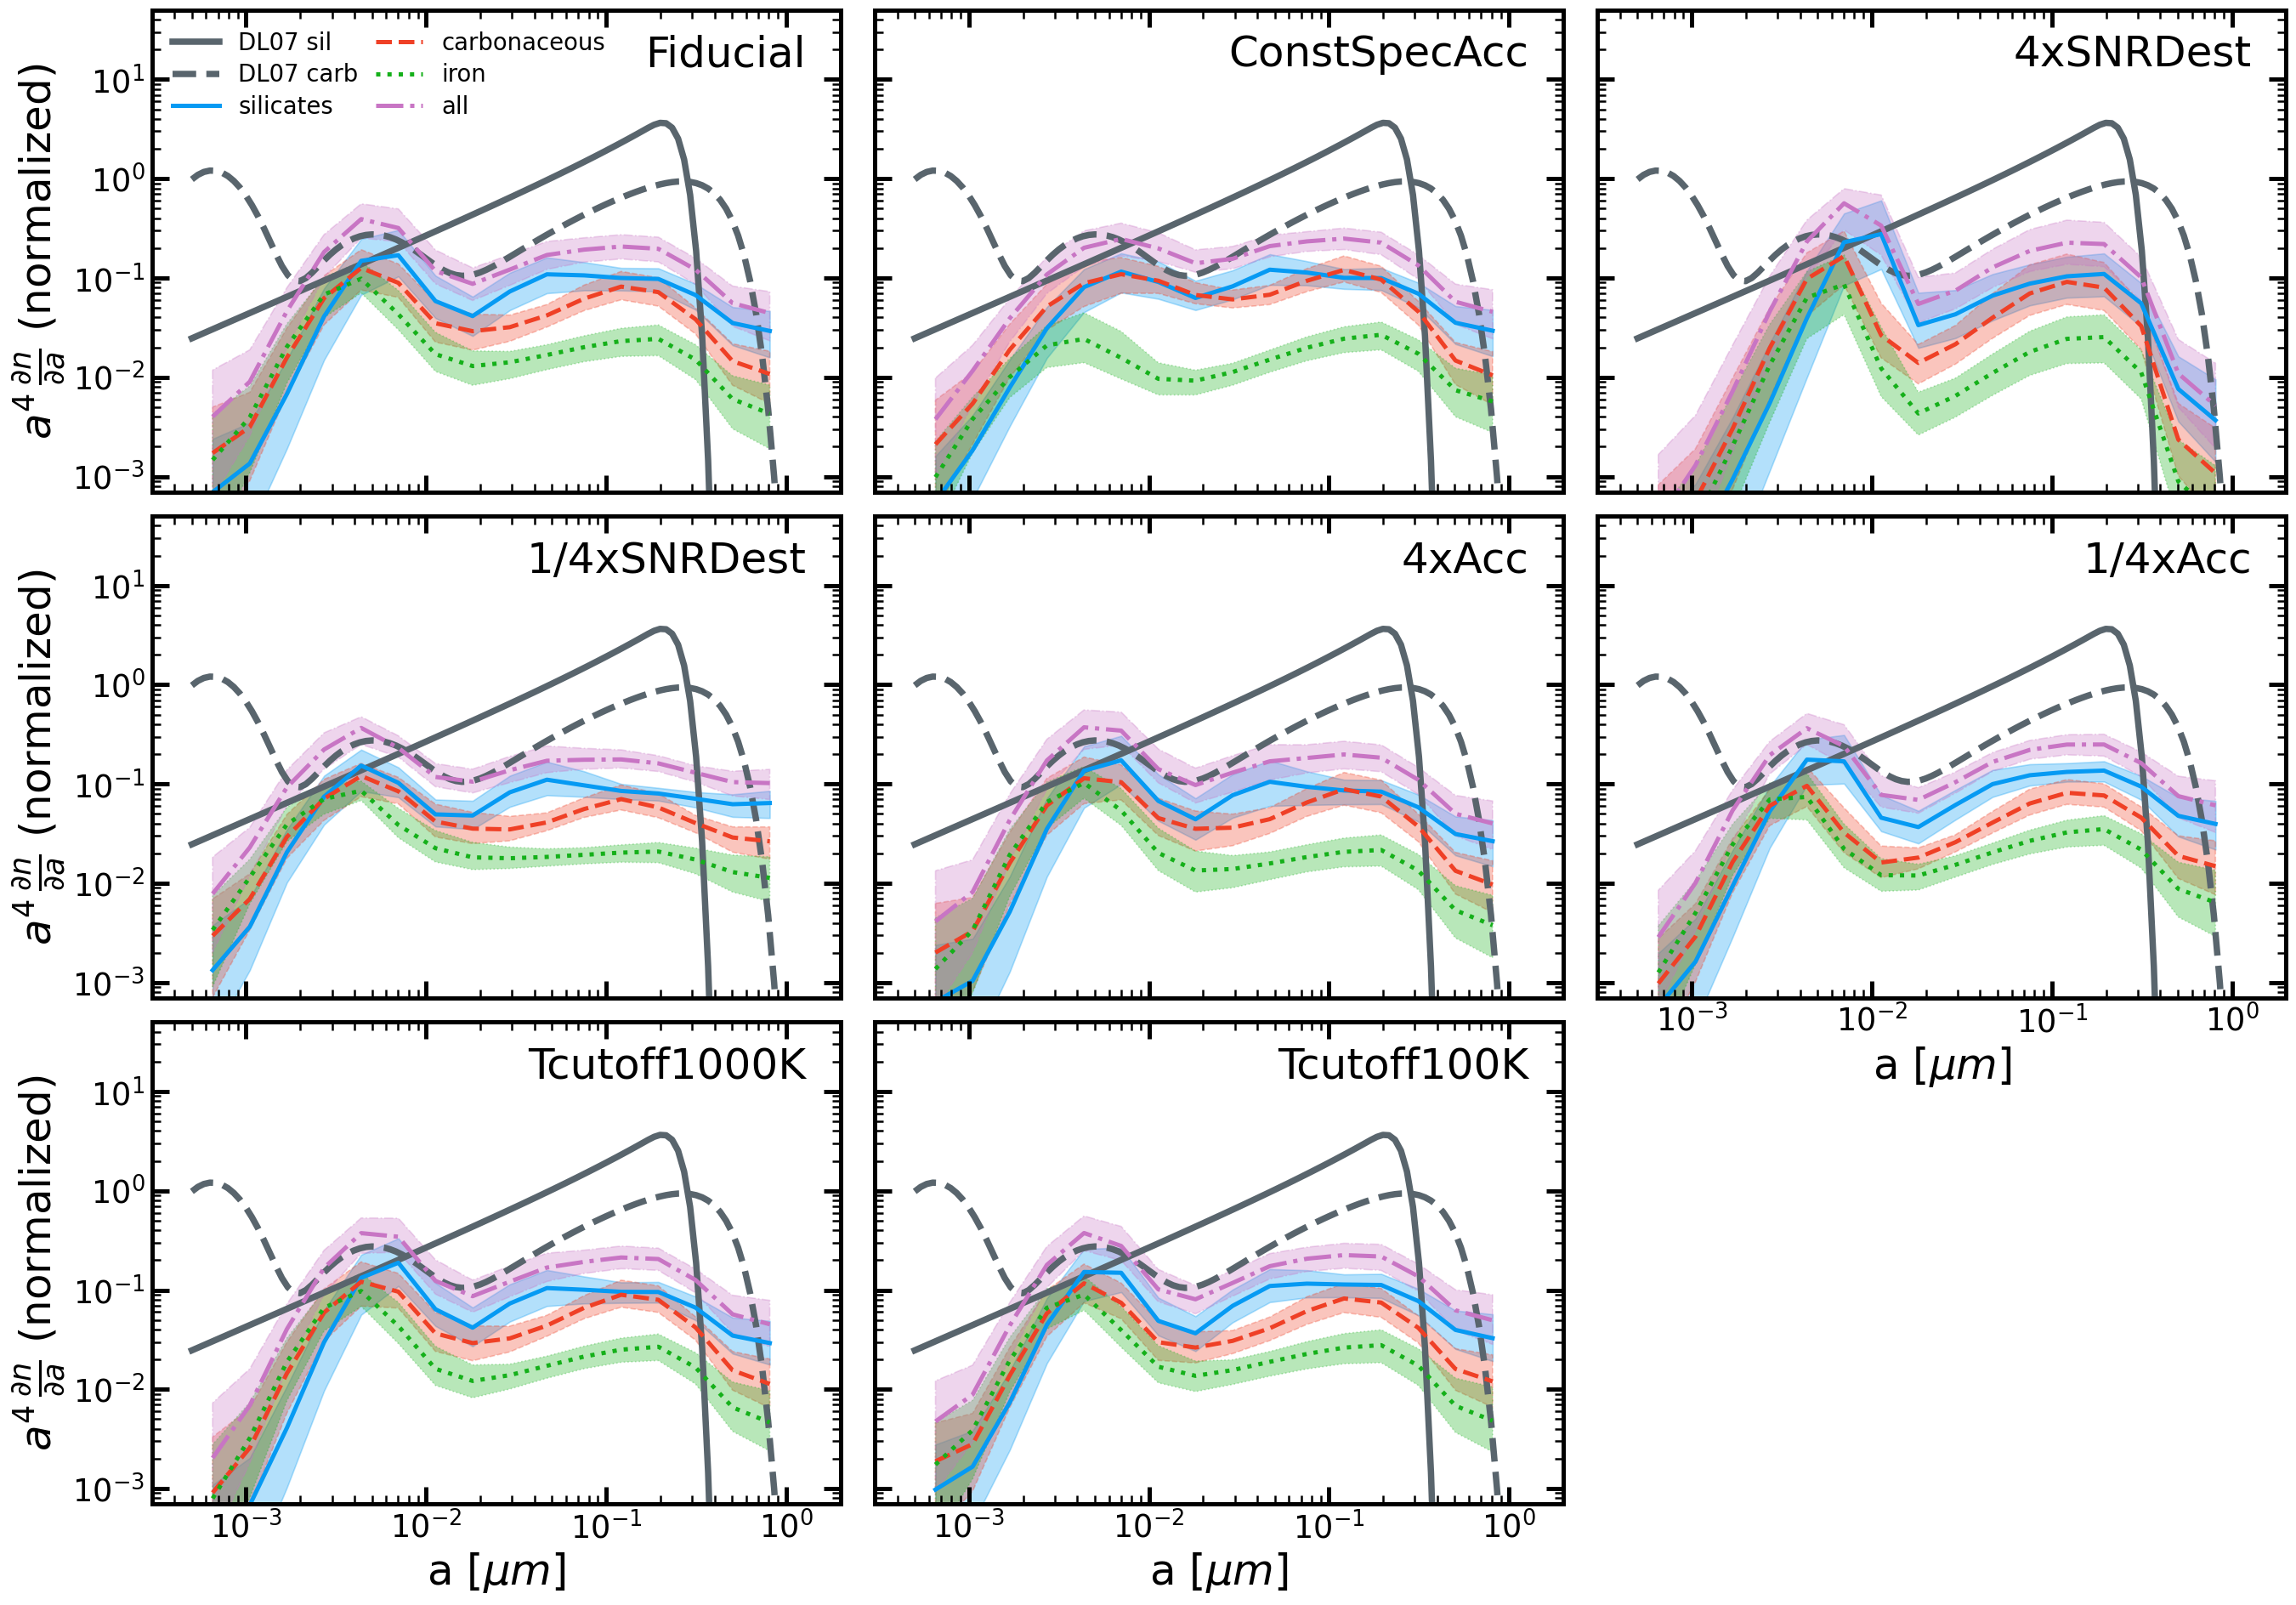

In [6]:

foutname = 'species_dmdloga.pdf'


species=['silicates','carbonaceous','iron','all']
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=False
include_idealized_DraineLi=True

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
#std_percentiles = [2.3, 97.7]

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_specs]
linestyles = config.LINE_STYLES[:num_specs]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(num_snaps, sharex='col', sharey='row')

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    fig.set_axis(k, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E1])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    if k>=0:
        obs_linewidth = 1.5*config.BASE_LINEWIDTH
        obs_alpha = 1
        if include_idealized_MRN:
            y_offset = 1
            MRN_a_vals = np.logspace(-3,-1,10)
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(k,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                                label='MRN', alpha = obs_alpha)
            # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
            # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
            # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
            #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
        if include_idealized_astrodust:
            idealized_bins = 100
            amin = 5E-4; amax = 1
            astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
            # Normalize astrodust+PAHs
            dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]

            # astrodust
            dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
            
            fig.plot_line_data(k,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                                label='HD23 astrodust', alpha = obs_alpha)
            # PAHs
            dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
            
            fig.plot_line_data(k,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                                label='HD23 PAHs', alpha = obs_alpha)

            # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
            # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
            # fig.add_text(0,x_coord,y_coord,r'astrodust',
            #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

        if include_idealized_DraineLi:
            idealized_bins = 100
            amin = 5E-4; amax = 1
            DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
            # Normalize astrodust+PAHs
            dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]

            # silicates
            dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
            
            fig.plot_line_data(k,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                                label='DL07 sil', alpha = obs_alpha)
            # carbonaceous
            dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
            
            fig.plot_line_data(k,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                                label='DL07 carb', alpha = obs_alpha)                



            # for j, spec in enumerate(species):
            #     # Lines used for the legend handles. Should not show up in plot
            #     fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    

    for j, spec in enumerate(species):
        grain_size_vals, percentile_dnda, percentile_dmdloga = \
            grain_size_utils.get_grain_size_distribution(G, 
                                                            dust_species=spec, 
                                                            mask=mask, 
                                                            points_per_bin=points_per_bin, 
                                                            std_percentiles = std_percentiles, weight='gas')

        fig.plot_line_data(k,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(k,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
    fig.add_text(k,0.95,0.95,sim_name,ha='right', va='top',rescale_font=0.75)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+ISM_phase+'_gas_'+foutname)

##### Separate plots with median distribution for all dust in each ISM phase

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.2888870e+06 1.2617045e+03 1.5475264e+06 7.9043656e+04]
cold 0.057318807
cool 0.05058333
warm 0.8486797
hot 0.043043412
/N/project/choban_group/cchoban/size_evo_suite/variations/NoISMShat/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [5.0902060e+06 1.3677928e+03 1.7530632e+06 8.3719477e+04]
cold 0.055593032
cool 0.058189556
warm 0.8637169
hot 0.022214895
/N/project/choban_group/cchoban/size_evo_suite/variations/NoSNeShat/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.0683580e+06 1.1774220e+03 1.2313152e+06 7.2492891e+04]
cold 0.051875915
cool 0.05062561
warm 0.8572953
hot 0.039897885
/N/project/choban_group/cchoban/size_evo_suite/variations/WeakSNeShat/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [6.4073065e+06 1.2358965e+03 1.4330104e+06 7.8388992e+04]
cold 0.044898383
cool 0.039635476
warm

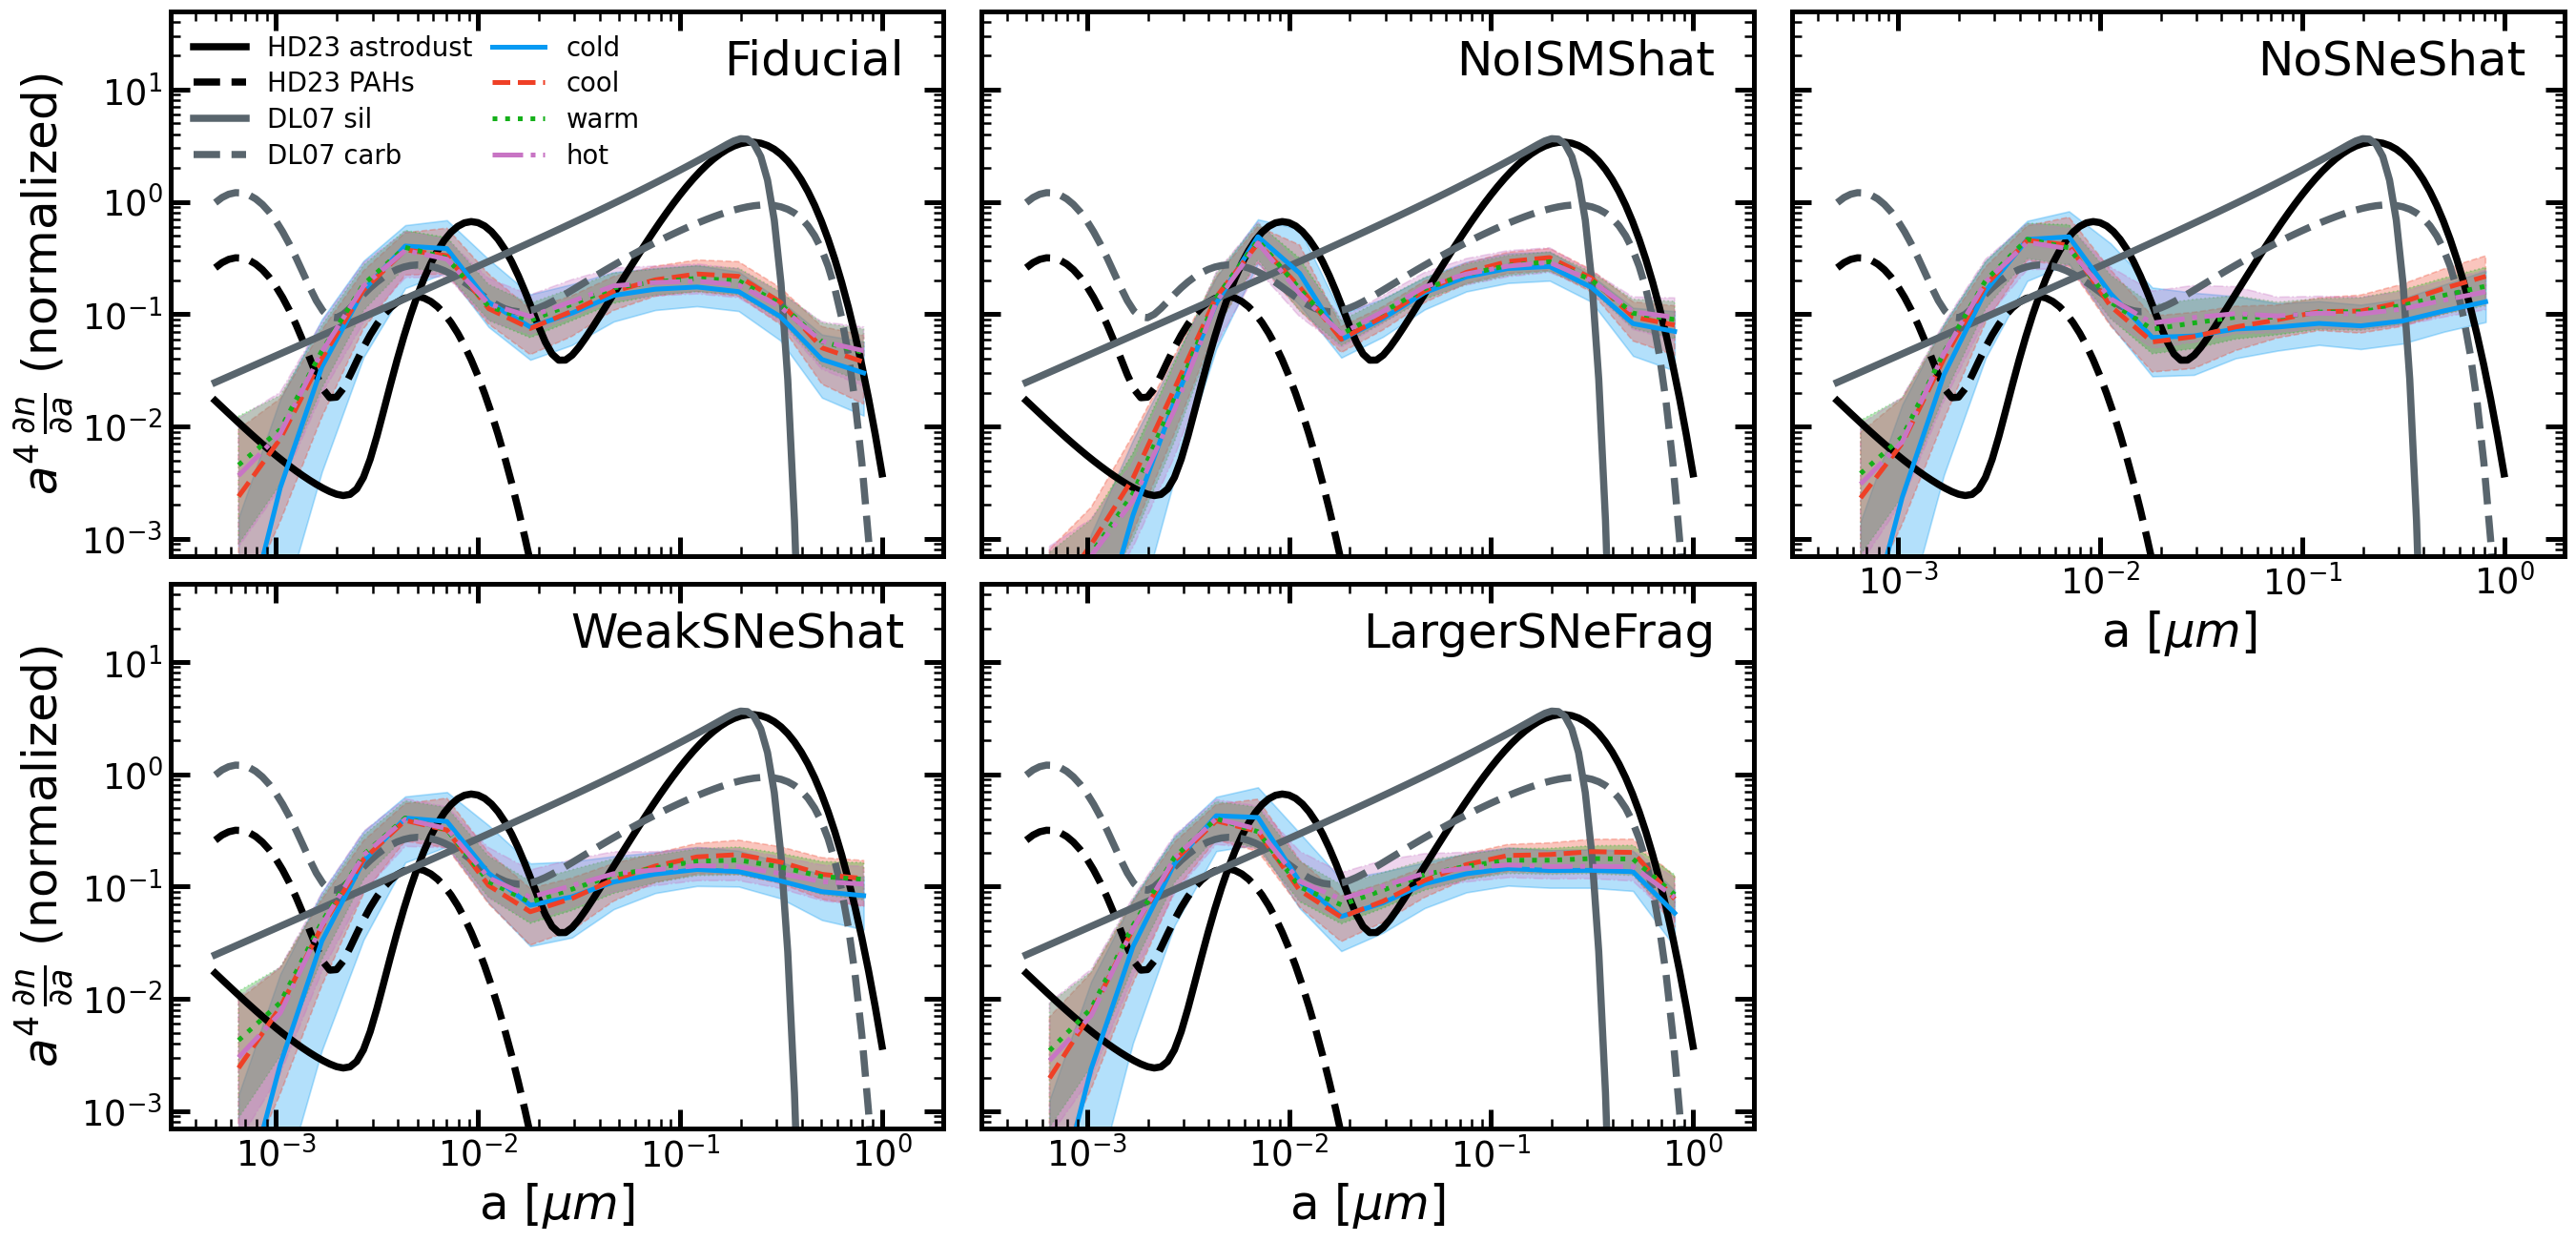

In [22]:

foutname = 'ISM_phase_dmdloga.pdf'


species='all'
ISM_phases = ['cold','cool','warm','hot']

include_idealized_MRN=False
include_idealized_astrodust=True
include_idealized_DraineLi=True

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
#std_percentiles = [2.3, 97.7]

num_snaps = len(galaxies)
num_phases = len(ISM_phases)
colors = config.LINE_COLORS[:num_phases]
linestyles = config.LINE_STYLES[:num_phases]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(num_snaps, sharex='col', sharey='row')

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    fig.set_axis(k, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E1])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    if k>=0:
        obs_linewidth = 1.5*config.BASE_LINEWIDTH
        obs_alpha = 1
        if include_idealized_MRN:
            y_offset = 1
            MRN_a_vals = np.logspace(-3,-1,10)
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(k,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                                label='MRN', alpha = obs_alpha)
            # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
            # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
            # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
            #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
        if include_idealized_astrodust:
            idealized_bins = 100
            amin = 5E-4; amax = 1
            astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
            # Normalize astrodust+PAHs
            dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]

            # astrodust
            dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
            
            fig.plot_line_data(k,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                                label='HD23 astrodust', alpha = obs_alpha)
            # PAHs
            dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
            
            fig.plot_line_data(k,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                                label='HD23 PAHs', alpha = obs_alpha)

            # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
            # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
            # fig.add_text(0,x_coord,y_coord,r'astrodust',
            #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

        if include_idealized_DraineLi:
            idealized_bins = 100
            amin = 5E-4; amax = 1
            DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
            # Normalize astrodust+PAHs
            dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]

            # silicates
            dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
            
            fig.plot_line_data(k,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                                label='DL07 sil', alpha = obs_alpha)
            # carbonaceous
            dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
            
            fig.plot_line_data(k,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                                label='DL07 carb', alpha = obs_alpha)                



            # for j, spec in enumerate(species):
            #     # Lines used for the legend handles. Should not show up in plot
            #     fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        

    

    for j, ISM_phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase,factor_clumping=True)
        M_gas = G.get_property('mass')
        print(ISM_phase,np.sum(M_gas[mask])/np.sum(M_gas))
        grain_size_vals, percentile_dnda, percentile_dmdloga = \
            grain_size_utils.get_grain_size_distribution(G, 
                                                            dust_species=species, 
                                                            mask=mask, 
                                                            points_per_bin=points_per_bin, 
                                                            std_percentiles = std_percentiles, weight='gas')

        fig.plot_line_data(k,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=ISM_phase)
        fig.plot_shaded_region(k,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
    fig.add_text(k,0.95,0.95,sim_name,ha='right', va='top',rescale_font=0.75)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+ISM_phase+'_gas_'+foutname)

##### One plot with median distributions for all dust species

/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [15794.14        22.278534  9435.0625    1163.8757  ]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [8762.867      20.227142 7047.062    1074.4097  ]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_stardust/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [9102.919      17.573391 7806.7036    942.27    ]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC_200CCoag/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [15490.88        19.937757  5326.9844    1078.27    ]


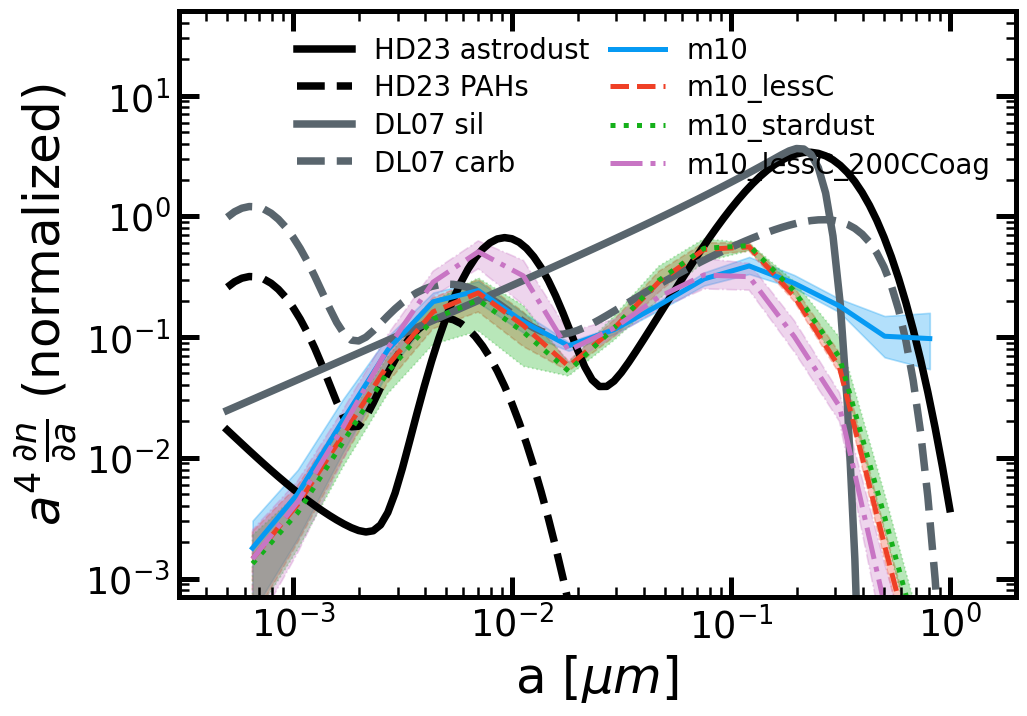

In [ ]:

foutname = 'median_dmdloga.pdf'


species='all'
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=True
include_idealized_DraineLi=True

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
#std_percentiles = [2.3, 97.7]

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E1])

obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = 1
    MRN_a_vals = np.logspace(-3,-1,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm 
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)     


for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    
    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)

    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G, 
                                                    dust_species=species, 
                                                    mask=mask, 
                                                    points_per_bin=points_per_bin, 
                                                    std_percentiles = std_percentiles, weight='gas')

    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name)
    fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+ISM_phase+'_gas_'+foutname)

##### Compare median distributions with other simulations

H19_dense (ideal)
H19_diffuse (ideal)
Li21 (SIMBA)
M25 (ideal)
P26 (L-GALAXIES)
N26 (AREPO-1446)


/tmp/ipykernel_1607264/3055517944.py:71: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm = quad(dmdloga,a_min,a_max)[0]
/tmp/ipykernel_1607264/3055517944.py:71: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-p

N26 (AREPO-6266)
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m12_200CCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.5309950e+06 1.4137499e+03 1.1815690e+06 8.7051148e+04]


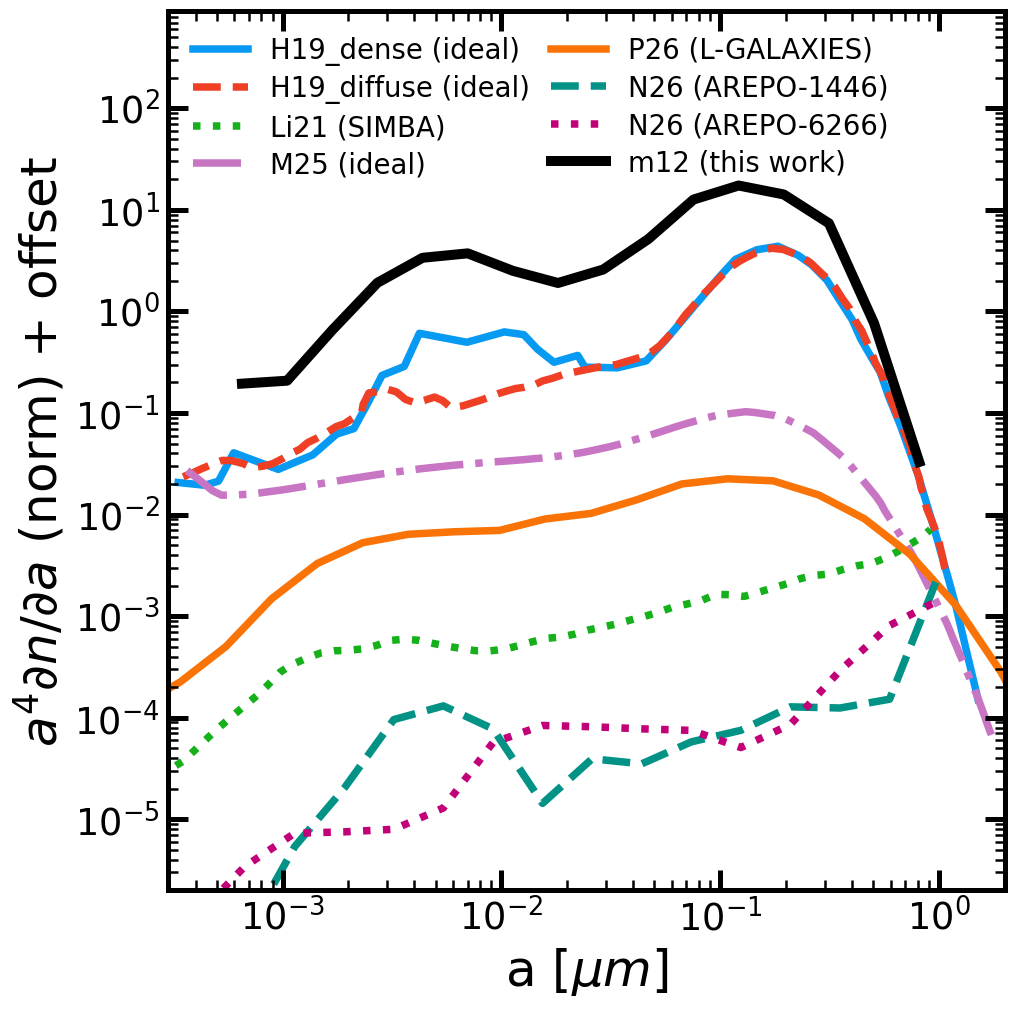

In [130]:

foutname = 'median_dmdloga_sim_comparison.pdf'

sim_data_dirc = '/N/slate/cchoban/dmdloga_data/'

species='all'
ISM_phase = 'all'

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
#std_percentiles = [2.3, 97.7]

colors = config.LINE_COLORS
linestyles = config.LINE_STYLES
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(1,yx_ratio=1.5)
fig.set_axis(0, 'grain_size', 'dm/dloga_norm', y_lim=[2E-6,9E2],y_label=r'$a^4 \partial n / \partial a$ (norm) + offset')

obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1


import pandas as pd
from scipy.integrate import quad
from scipy.interpolate import interp1d

sim_files = ['Hirashita19_dense.csv',
             'Hirashita19_diffuse.csv',
             'Li21.csv',
             'Matsumoto25.csv',
             'Parente26.csv',
            #  'Narayanan26_median.csv',
             'Narayanan26_gal1446.csv',
             'Narayanan26_gal6266.csv'
             ]
paper_names = ['H19_dense (ideal)',
             'H19_diffuse (ideal)',
             'Li21 (SIMBA)',
             'M25 (ideal)',
             'P26 (L-GALAXIES)',
             'N26 (AREPO-1446)',
             'N26 (AREPO-6266)',
           ]
offsets = [1,
           1,
           10**-2.5,
           10**-1.5,
           10**-2,
           10**-3.2,
           10**-3.2,
           10**-3.2,
           ]

for i,file in enumerate(sim_files):
    sim_file = sim_data_dirc +file
    paper_name = paper_names[i]
    offset=offsets[i]
    print(paper_name)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(sim_file, names=['size','dmdloga','dmdloga_low','dmdloga_up'])
    # Access a specific column
    a_vals = df['size']
    a_max = np.min([1,np.max(a_vals)])
    a_min= np.min([5E-4,np.min(a_vals)])

    dmdloga = interp1d(a_vals,df['dmdloga'])
    norm = quad(dmdloga,a_min,a_max)[0]
    fig.plot_line_data(0,a_vals,dmdloga(a_vals)/norm*offset, color=colors[i],linestyle=linestyles[i], linewidth=obs_linewidth,
                        label=paper_name, alpha = obs_alpha)
    # if paper_name == 'P26 (L-GALAXIES)':
    #     dmdloga_low = df['dmdloga_low']/norm
    #     dmdloga_up = df['dmdloga_up']/norm
    #     fig.plot_shaded_region(0, a_vals, dmdloga_low*offset, dmdloga_up*offset, color=colors[i], alpha = 0.1*obs_alpha)
 

offset = 10**1.5
for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    
    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G, 
                                                    dust_species=species, 
                                                    mask=mask, 
                                                    points_per_bin=points_per_bin, 
                                                    std_percentiles = std_percentiles, weight='gas')

    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0]*offset, color='xkcd:black',linestyle='-', label=sim_name + ' (this work)', linewidth=2*config.BASE_LINEWIDTH)
    #fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])

fig.set_all_legends(max_cols=2,rescale_font=0.75,loc='upper left')

fig.save(plot_dir+group_name+'_'+foutname)

/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [15794.14        22.278534  9435.0625    1163.8757  ]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [8762.867      20.227142 7047.062    1074.4097  ]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_stardust/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [9102.919      17.573391 7806.7036    942.27    ]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_lessC_200CCoag/output
Snapshot time: 1.0000000000000004
Total dust mass sources: [15490.88        19.937757  5326.9844    1078.27    ]


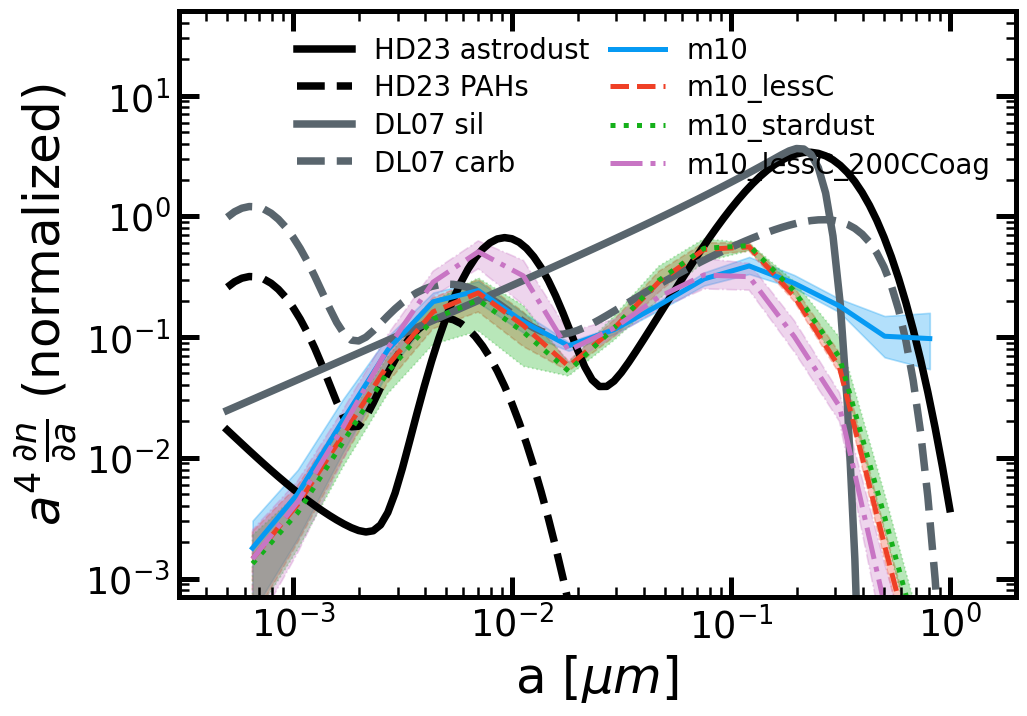

In [28]:

foutname = 'median_dmdloga.pdf'


species='all'
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=True
include_idealized_DraineLi=True

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
#std_percentiles = [2.3, 97.7]

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E1])

obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = 1
    MRN_a_vals = np.logspace(-3,-1,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm 
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    
    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)

    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G, 
                                                    dust_species=species, 
                                                    mask=mask, 
                                                    points_per_bin=points_per_bin, 
                                                    std_percentiles = std_percentiles, weight='gas')

    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name)
    fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+ISM_phase+'_gas_'+foutname)

#### Total Grain size distributions for each ISM phase

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.2888870e+06 1.2617045e+03 1.5475264e+06 7.9043656e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/NoCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [8.0708710e+06 1.1153311e+03 1.4093896e+06 6.8771930e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/10xVCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [6.4692545e+06 1.2737343e+03 1.6225698e+06 7.8959227e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/NoVCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.0347370e+06 1.3537036e+03 1.6634428e+06 8.5136164e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/10xCCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [6.9958105e+06 1.4976208e+03 2.0612689e+06 9.3109812e+04]
/N/project/choban_group/cchoban/size_evo_suite/v

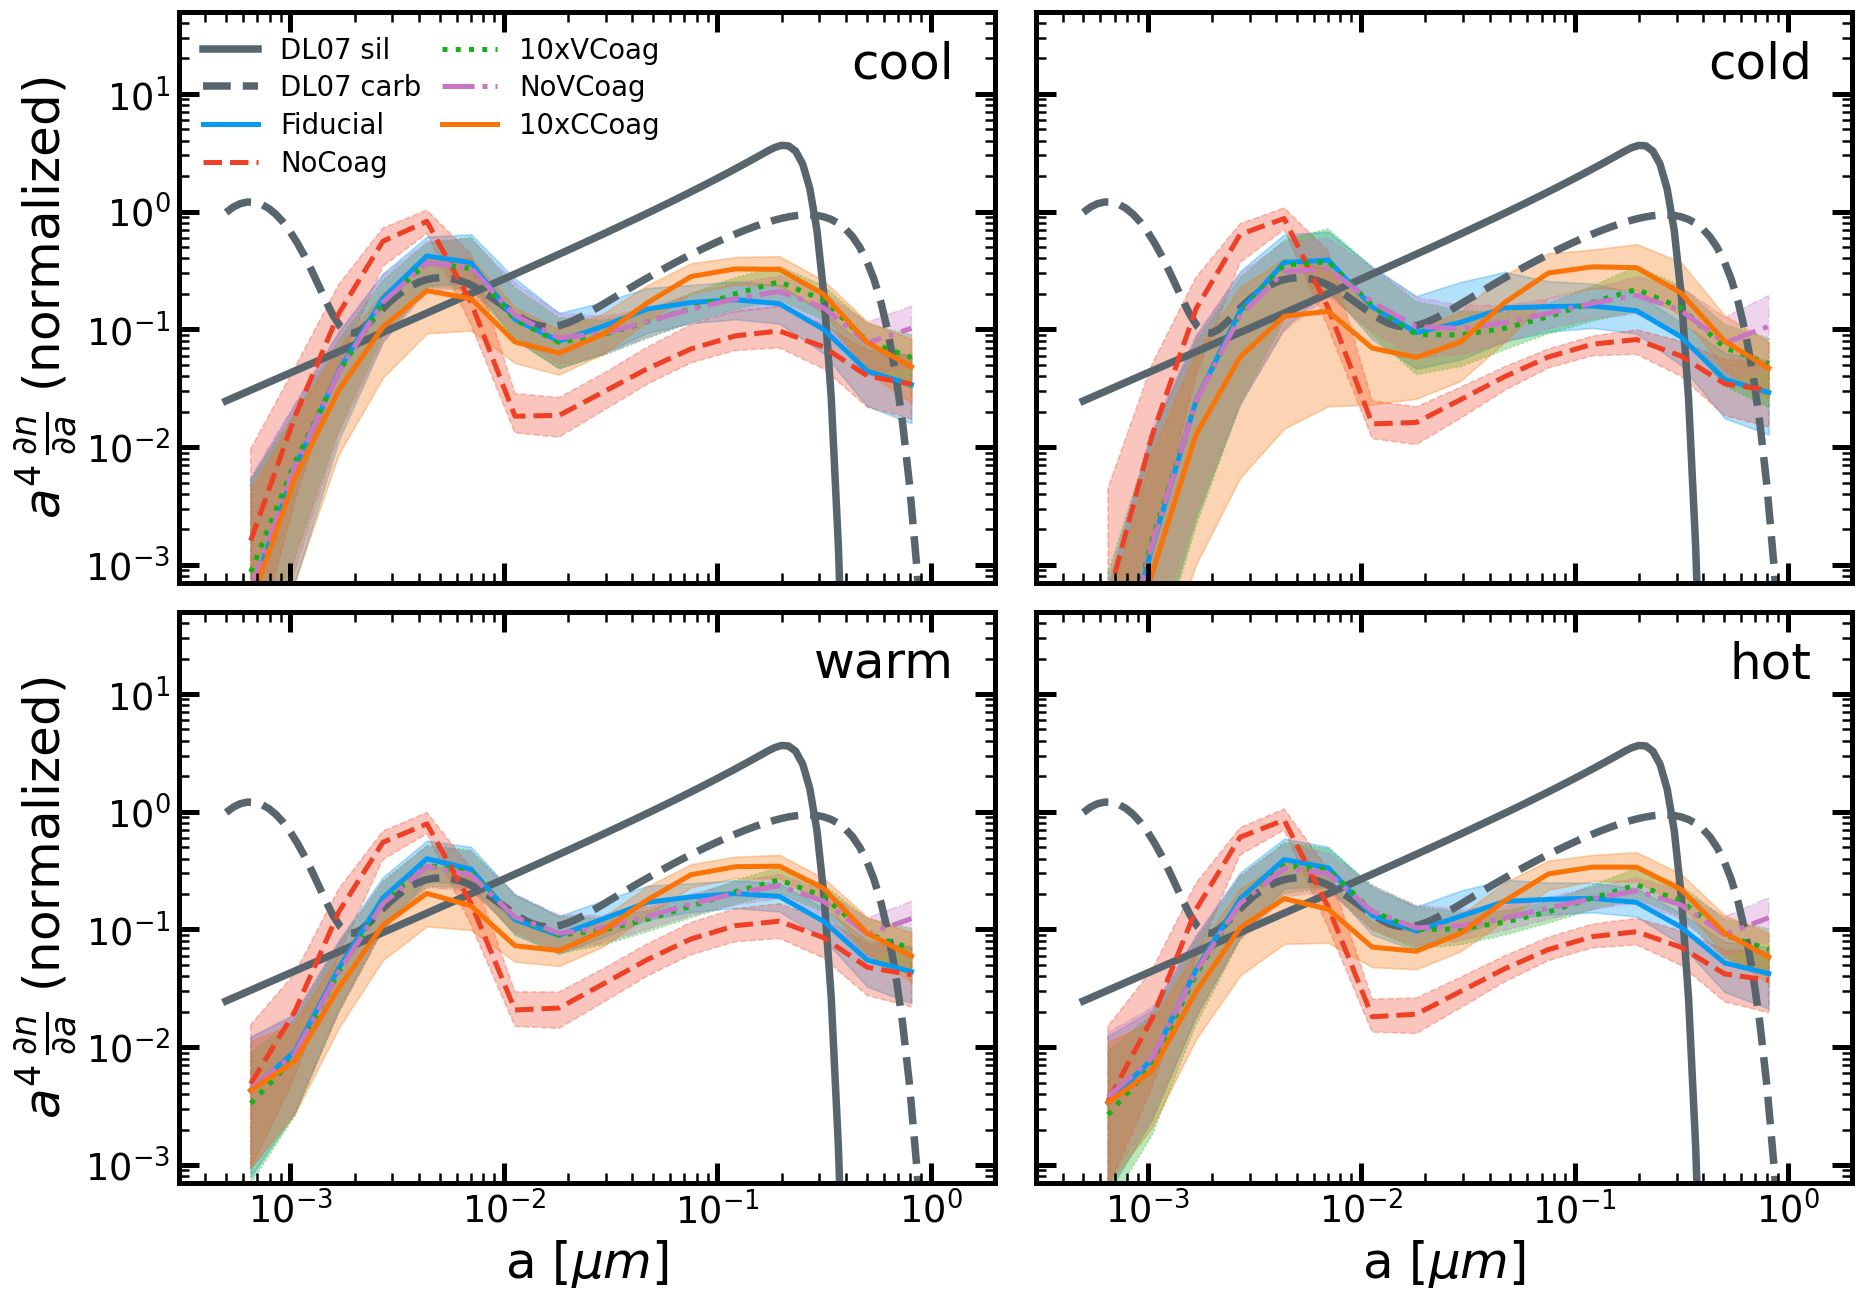

In [13]:

foutname = 'total_dmdloga_ISM_phases.pdf'


ISM_phases = ['cool','cold','warm','hot']
dust_species='all'

include_idealized_MRN=False
include_idealized_astrodust=False
include_idealized_DraineLi=True

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
#std_percentiles = [2.3, 97.7]

num_phases = len(ISM_phases)
num_snaps = len(galaxies)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(num_phases, sharex='col', sharey='row')


for i, ISM_phase in enumerate(ISM_phases):

    fig.set_axis(i, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E1])

    if i>=0:
        obs_linewidth = 1.5*config.BASE_LINEWIDTH
        obs_alpha = 1
        if include_idealized_MRN:
            y_offset = 1
            MRN_a_vals = np.logspace(-3,-1,10)
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(i,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                                label='MRN', alpha = obs_alpha)
            # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
            # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
            # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
            #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
        if include_idealized_astrodust:
            idealized_bins = 100
            amin = 5E-4; amax = 1
            astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
            # Normalize astrodust+PAHs
            dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]

            # astrodust
            dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
            
            fig.plot_line_data(i,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                                label='HD23 astrodust', alpha = obs_alpha)
            # PAHs
            dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
            
            fig.plot_line_data(i,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                                label='HD23 PAHs', alpha = obs_alpha)

            # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
            # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
            # fig.add_text(0,x_coord,y_coord,r'astrodust',
            #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

        if include_idealized_DraineLi:
            idealized_bins = 100
            amin = 5E-4; amax = 1
            DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
            # Normalize astrodust+PAHs
            dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]

            # silicates
            dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
            
            fig.plot_line_data(i,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                                label='DL07 sil', alpha = obs_alpha)
            # carbonaceous
            dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
            
            fig.plot_line_data(i,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                                label='DL07 carb', alpha = obs_alpha)               



    for k,halo in enumerate(galaxies):
        sp = halo.sp
        print(sp.sdir)
        sim_name = sim_names[k]
        G=halo.loadpart(0)

        

        print("Snapshot time:",sp.time)
        print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
        
            
        mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
        

        grain_size_vals, percentile_dnda, percentile_dmdloga = \
            grain_size_utils.get_grain_size_distribution(G, 
                                                        dust_species=dust_species,
                                                        mask=mask, 
                                                        points_per_bin=points_per_bin, 
                                                        std_percentiles = std_percentiles, weight='dust')

        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])
    fig.add_text(i,0.95,0.95,ISM_phase,ha='right', va='top',rescale_font=0.75)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

#### Median Extinction Curves

##### Separate Plots

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.2888870e+06 1.2617045e+03 1.5475264e+06 7.9043656e+04]
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/10xVCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [6.4692545e+06 1.2737343e+03 1.6225698e+06 7.8959227e+04]
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/NoVCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.0347370e+06 1.3537036e+03 1.6634428e+06 8.5136164e+04]
 Will truncate grain

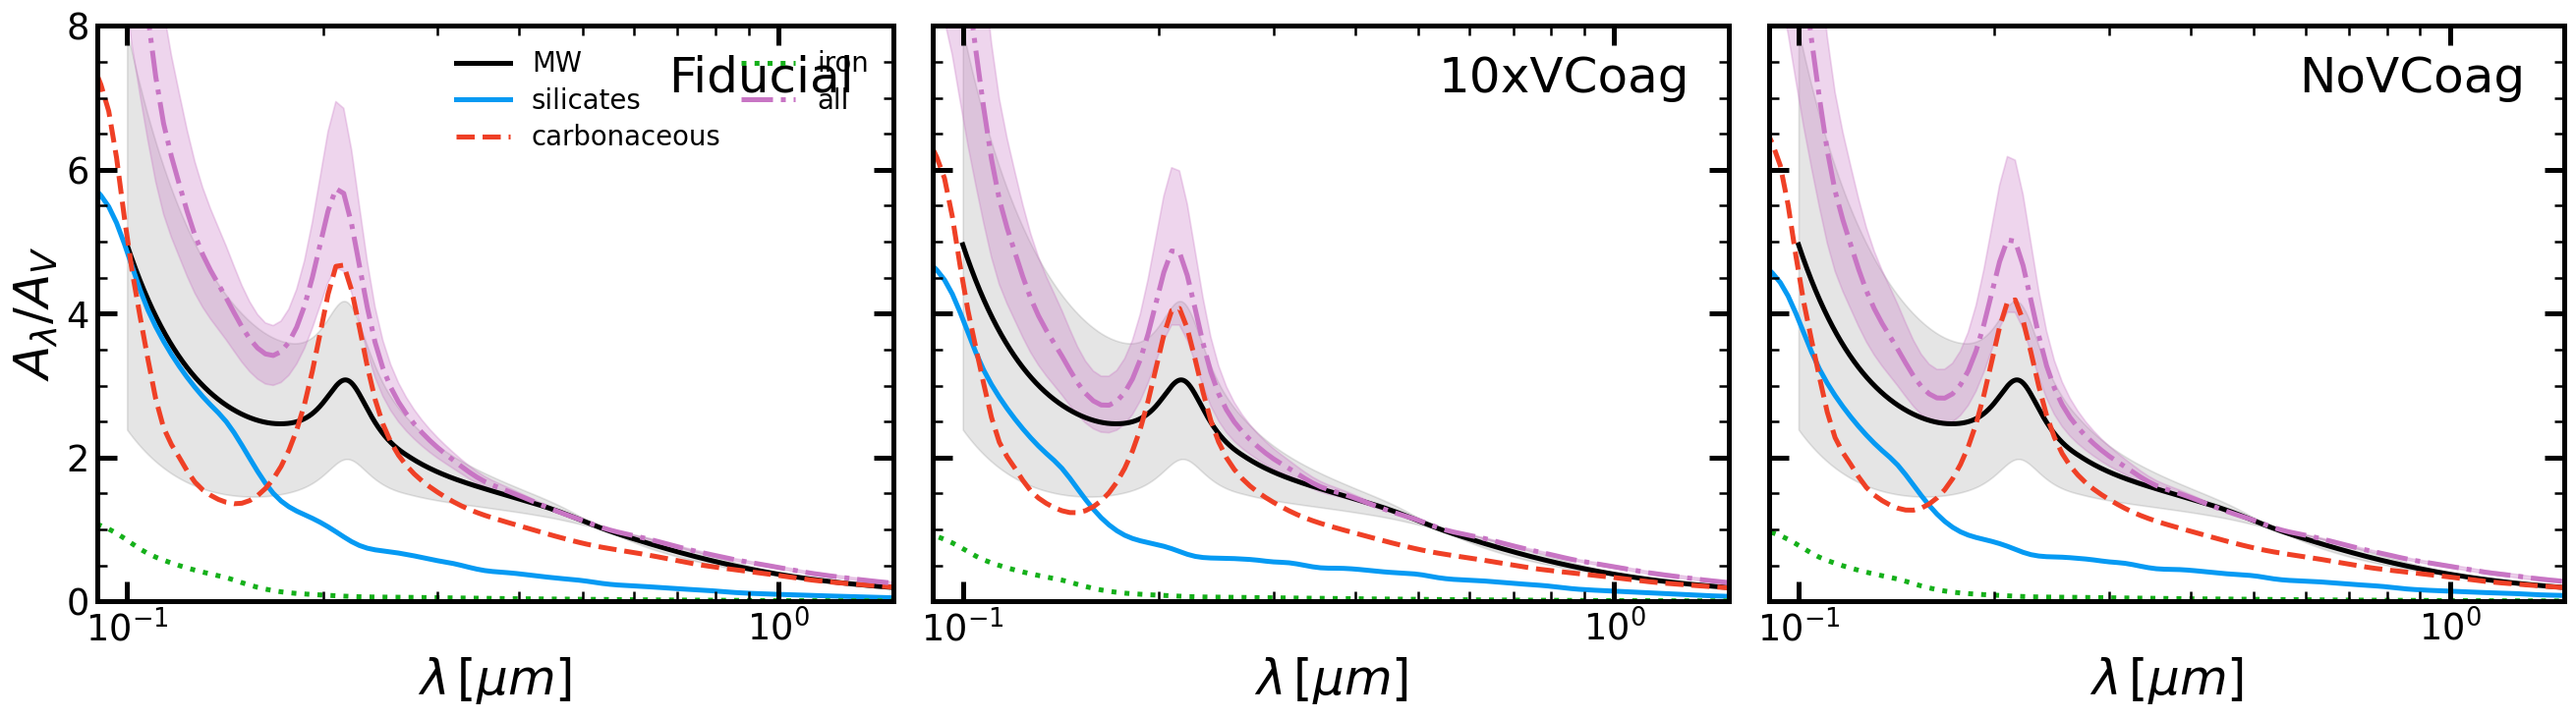

In [55]:

foutname = 'detailed_extinction_curve.pdf'
ISM_phase = 'all'
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_specs]
linestyles = config.LINE_STYLES[:num_specs]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(num_snaps, sharex='col', sharey='row')

for k,halo in enumerate(galaxies):
    print(halo.sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    fig.set_axis(k, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])

    print("Snapshot time:",halo.sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))

    # Plot observed extinction curves
    # galaxy_names = ['MW','LMC','LMC_30Dor','SMC']
    galaxy_names = ['MW']
    obs_colors = ['xkcd:black','xkcd:gold','xkcd:gold','xkcd:blue']
    obs_linestyles = ['-','-','--','-']
    subsamples = [0,2,2,2]
    for i, galaxy_name in enumerate(galaxy_names):
        wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy_name, subsample=subsamples[i])
        fig.plot_line_data(k,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                            color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy_name, std_kwargs={'alpha':0.1})

    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)

    for j, spec in enumerate(species):
        wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
        if spec == 'all':
            fig.plot_line_data(k,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
        else:
            fig.plot_line_data(k,wavelength_points,A_lambda_percentiles[0], color=colors[j],linestyle=linestyles[j], label = spec)
    
    fig.add_text(k,0.95,0.95,sim_name,ha='right', va='top',rescale_font=0.75)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

##### Single Plot with Only Total Extinction

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.2888870e+06 1.2617045e+03 1.5475264e+06 7.9043656e+04]
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/10xVCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [6.4692545e+06 1.2737343e+03 1.6225698e+06 7.8959227e+04]
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/NoVCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.0347370e+06 1.3537036e+03 1.6634428e+06 8.5136164e+04]
 Will truncate grain sizes beyond supported range.


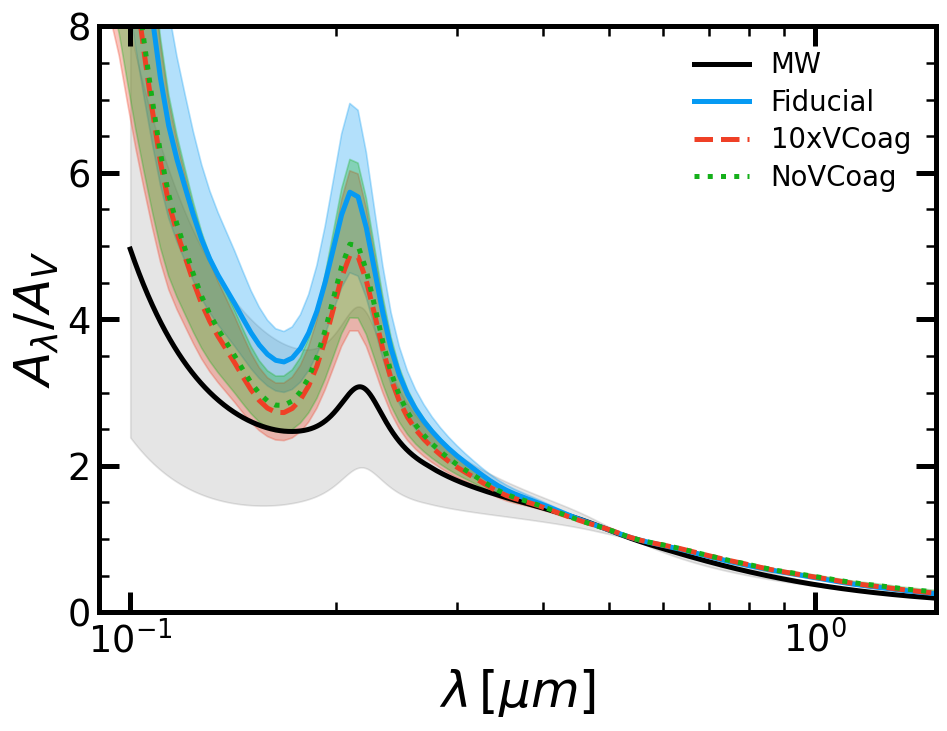

In [56]:

foutname = 'median_extinction_curve.pdf'
ISM_phase = 'all'
species='all'



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(1)
fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])

# Plot observed extinction curves
# galaxy_names = ['MW','LMC','LMC_30Dor','SMC']
galaxy_names = ['MW']
obs_colors = ['xkcd:black','xkcd:gold','xkcd:gold','xkcd:blue']
obs_linestyles = ['-','-','--','-']
subsamples = [0,2,2,2]
for i, galaxy_name in enumerate(galaxy_names):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy_name, subsample=subsamples[i])
    fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy_name, std_kwargs={'alpha':0.1})

for k,halo in enumerate(galaxies):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",halo.sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))



    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species=species, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[k],linestyle=linestyles[k], label = name)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

#### Median Grain Size Distribution and Extinctions 

/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.2888870e+06 1.2617045e+03 1.5475264e+06 7.9043656e+04]
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/NoISMShat/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [5.0902060e+06 1.3677928e+03 1.7530632e+06 8.3719477e+04]
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/10xISMShat/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.9444090e+06 1.1682354e+03 1.3539766e+06 7.2441234e+04]
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/NoSNeShat/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.0683580e+06 1.1774220e+03 1.2313152e+06 7.2492891e+04]
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/ccho

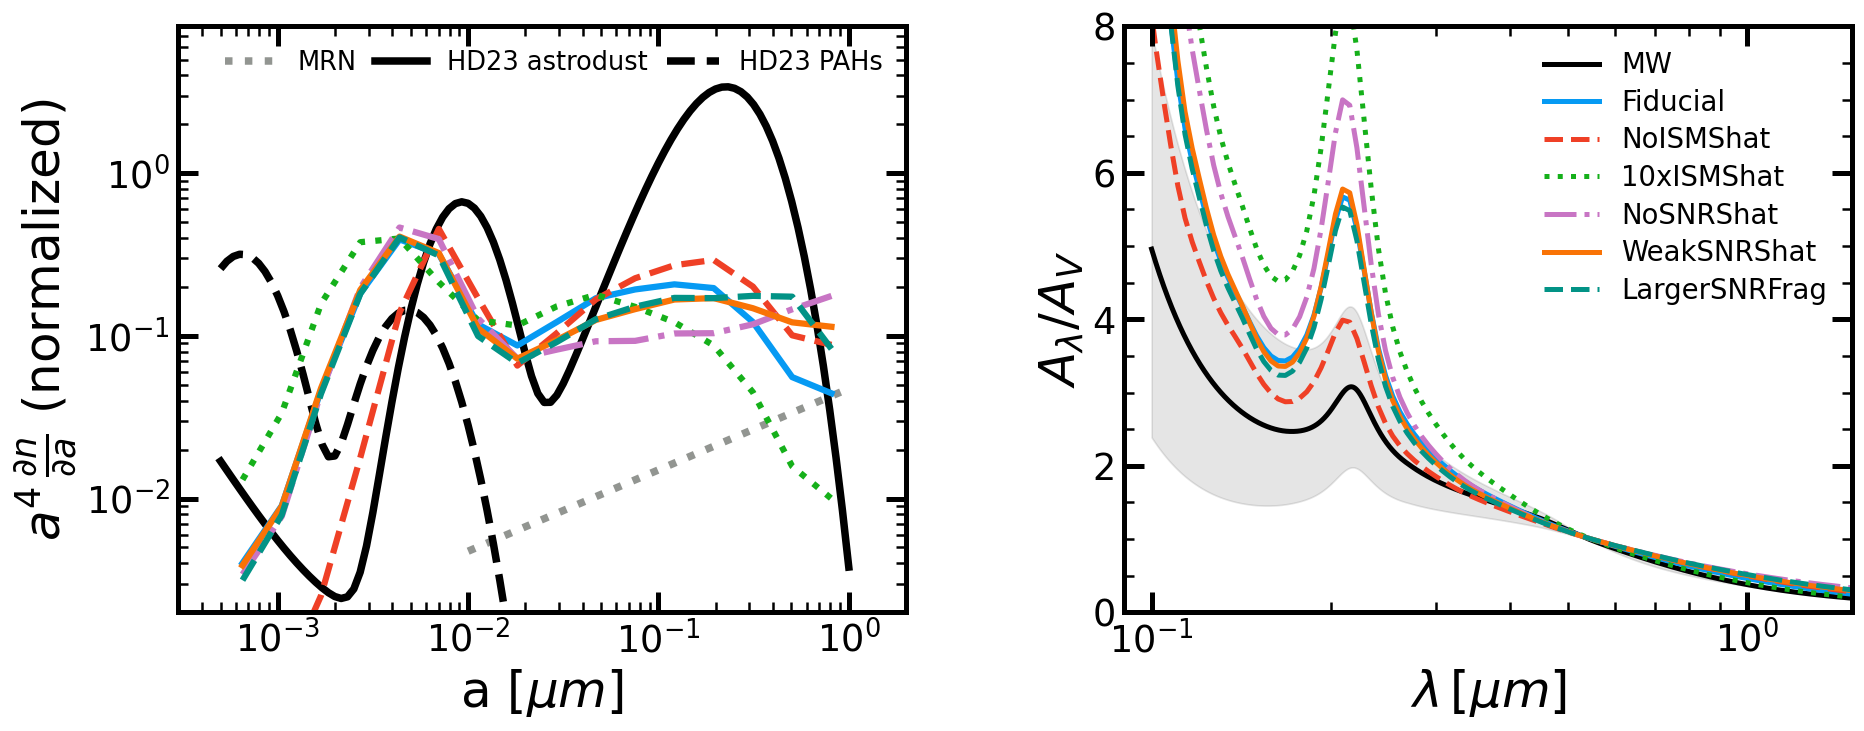

In [10]:

foutname = 'dmdloga_AV_all_gas.pdf'


species='all'
ISM_phase = 'all'

include_idealized_MRN=True
include_idealized_astrodust=True
include_idealized_DraineLi=False

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

alpha=0.0


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 10


#fig = Figure(2, yx_ratio=0.9, ncols=1)
fig = Figure(2, yx_ratio=1, ncols=2)
num_sims = len(galaxies)
colors = config.LINE_COLORS[:num_sims]
linestyles = config.LINE_STYLES[:num_sims]
linewidth = 1.25*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'dm/dloga_norm', y_lim=[2E-3,8E0])
fig.set_axis(1, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])


obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = -1.5
    MRN_a_vals = np.logspace(-2,-0,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10.,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
    # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
    # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'astrodust',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
    
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)                

# Force all obs size distribution legend elements on first plot
fig.set_axis_legend(0,ncol=3,rescale_font=0.7)

# Plot observed extinction curves
galaxy_names = ['MW','LMC','LMC_30Dor','SMC']
galaxy_names = ['MW']
obs_colors = ['xkcd:black','xkcd:goldenrod','xkcd:goldenrod','xkcd:lilac']
obs_linestyles = ['-','-','--','-']
subsamples = [0,2,2,2]
for i, galaxy_name in enumerate(galaxy_names):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy_name, subsample=subsamples[i])
    fig.plot_line_data(1,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy_name, std_kwargs={'alpha':0.1})

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))



    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
 
    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G,  
                                                        dust_species=species, 
                                                        mask=mask, 
                                                        points_per_bin=points_per_bin, 
                                                        std_percentiles = [16, 84])

    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name, linewidth=linewidth)
    fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k],alpha=alpha)

    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species=species, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    fig.plot_line_data(1,wavelength_points,A_lambda_percentiles[0], color=colors[k],linestyle=linestyles[k], label = sim_name)
    fig.plot_shaded_region(1,wavelength_points,A_lambda_percentiles[1],A_lambda_percentiles[2], color=colors[k],linestyle=linestyles[k],alpha=alpha)


# Second plot will have simulation legend handles
fig.set_axis_legend(1,ncol=1,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

Preload extinction data for quick plotting

In [112]:

foutname = 'dmdloga_AV_all_species.pdf'


species=['silicates','carbonaceous']
ISM_phase = 'all'


# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 10

extinction_data = {}

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)
    extinction_data[sim_name] = {}

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    
    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species='all', mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    extinction_data[sim_name]['all']={}
    extinction_data[sim_name]['all']['lambda'] = wavelength_points
    extinction_data[sim_name]['all']['AV'] = A_lambda_percentiles

    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species='silicates', mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    extinction_data[sim_name]['silicates']={}
    extinction_data[sim_name]['silicates']['lambda'] = wavelength_points
    extinction_data[sim_name]['silicates']['AV'] = A_lambda_percentiles

    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species='carbonaceous', mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    extinction_data[sim_name]['carbonaceous']={}
    extinction_data[sim_name]['carbonaceous']['lambda'] = wavelength_points
    extinction_data[sim_name]['carbonaceous']['AV'] = A_lambda_percentiles

    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species='iron', mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    extinction_data[sim_name]['iron']={}
    extinction_data[sim_name]['iron']['lambda'] = wavelength_points
    extinction_data[sim_name]['iron']['AV'] = A_lambda_percentiles
    


/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m12_200CCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.5309950e+06 1.4137499e+03 1.1815690e+06 8.7051148e+04]
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m11_200CCoag/output
Snapshot time: 0.7000000000000004
Total dust mass sources: [6.1406125e+05 1.8986014e+02 9.1905359e+04 5.6707451e+03]
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ/output
Snapshot time: 0.7000000000000004
Total dust mass sources: [1.4536324e+04 9.3216333e+00 4.8141675e+03 4.8219650e+02]
 

/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m12_200CCoag/output
Snapshot time: 1.0000000000000007
Total dust mass sources: [7.5309950e+06 1.4137499e+03 1.1815690e+06 8.7051148e+04]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m11_200CCoag/output
Snapshot time: 0.7000000000000004
Total dust mass sources: [6.1406125e+05 1.8986014e+02 9.1905359e+04 5.6707451e+03]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ/output
Snapshot time: 0.7000000000000004
Total dust mass sources: [1.4536324e+04 9.3216333e+00 4.8141675e+03 4.8219650e+02]
/N/project/choban_group/cchoban/size_evo_suite/IC_variations/m10_highZ_200CCoag_0.25CarbAcc/output
Snapshot time: 0.7000000000000004
Total dust mass sources: [1.4976746e+04 1.2055124e+01 6.3776299e+03 6.0754535e+02]


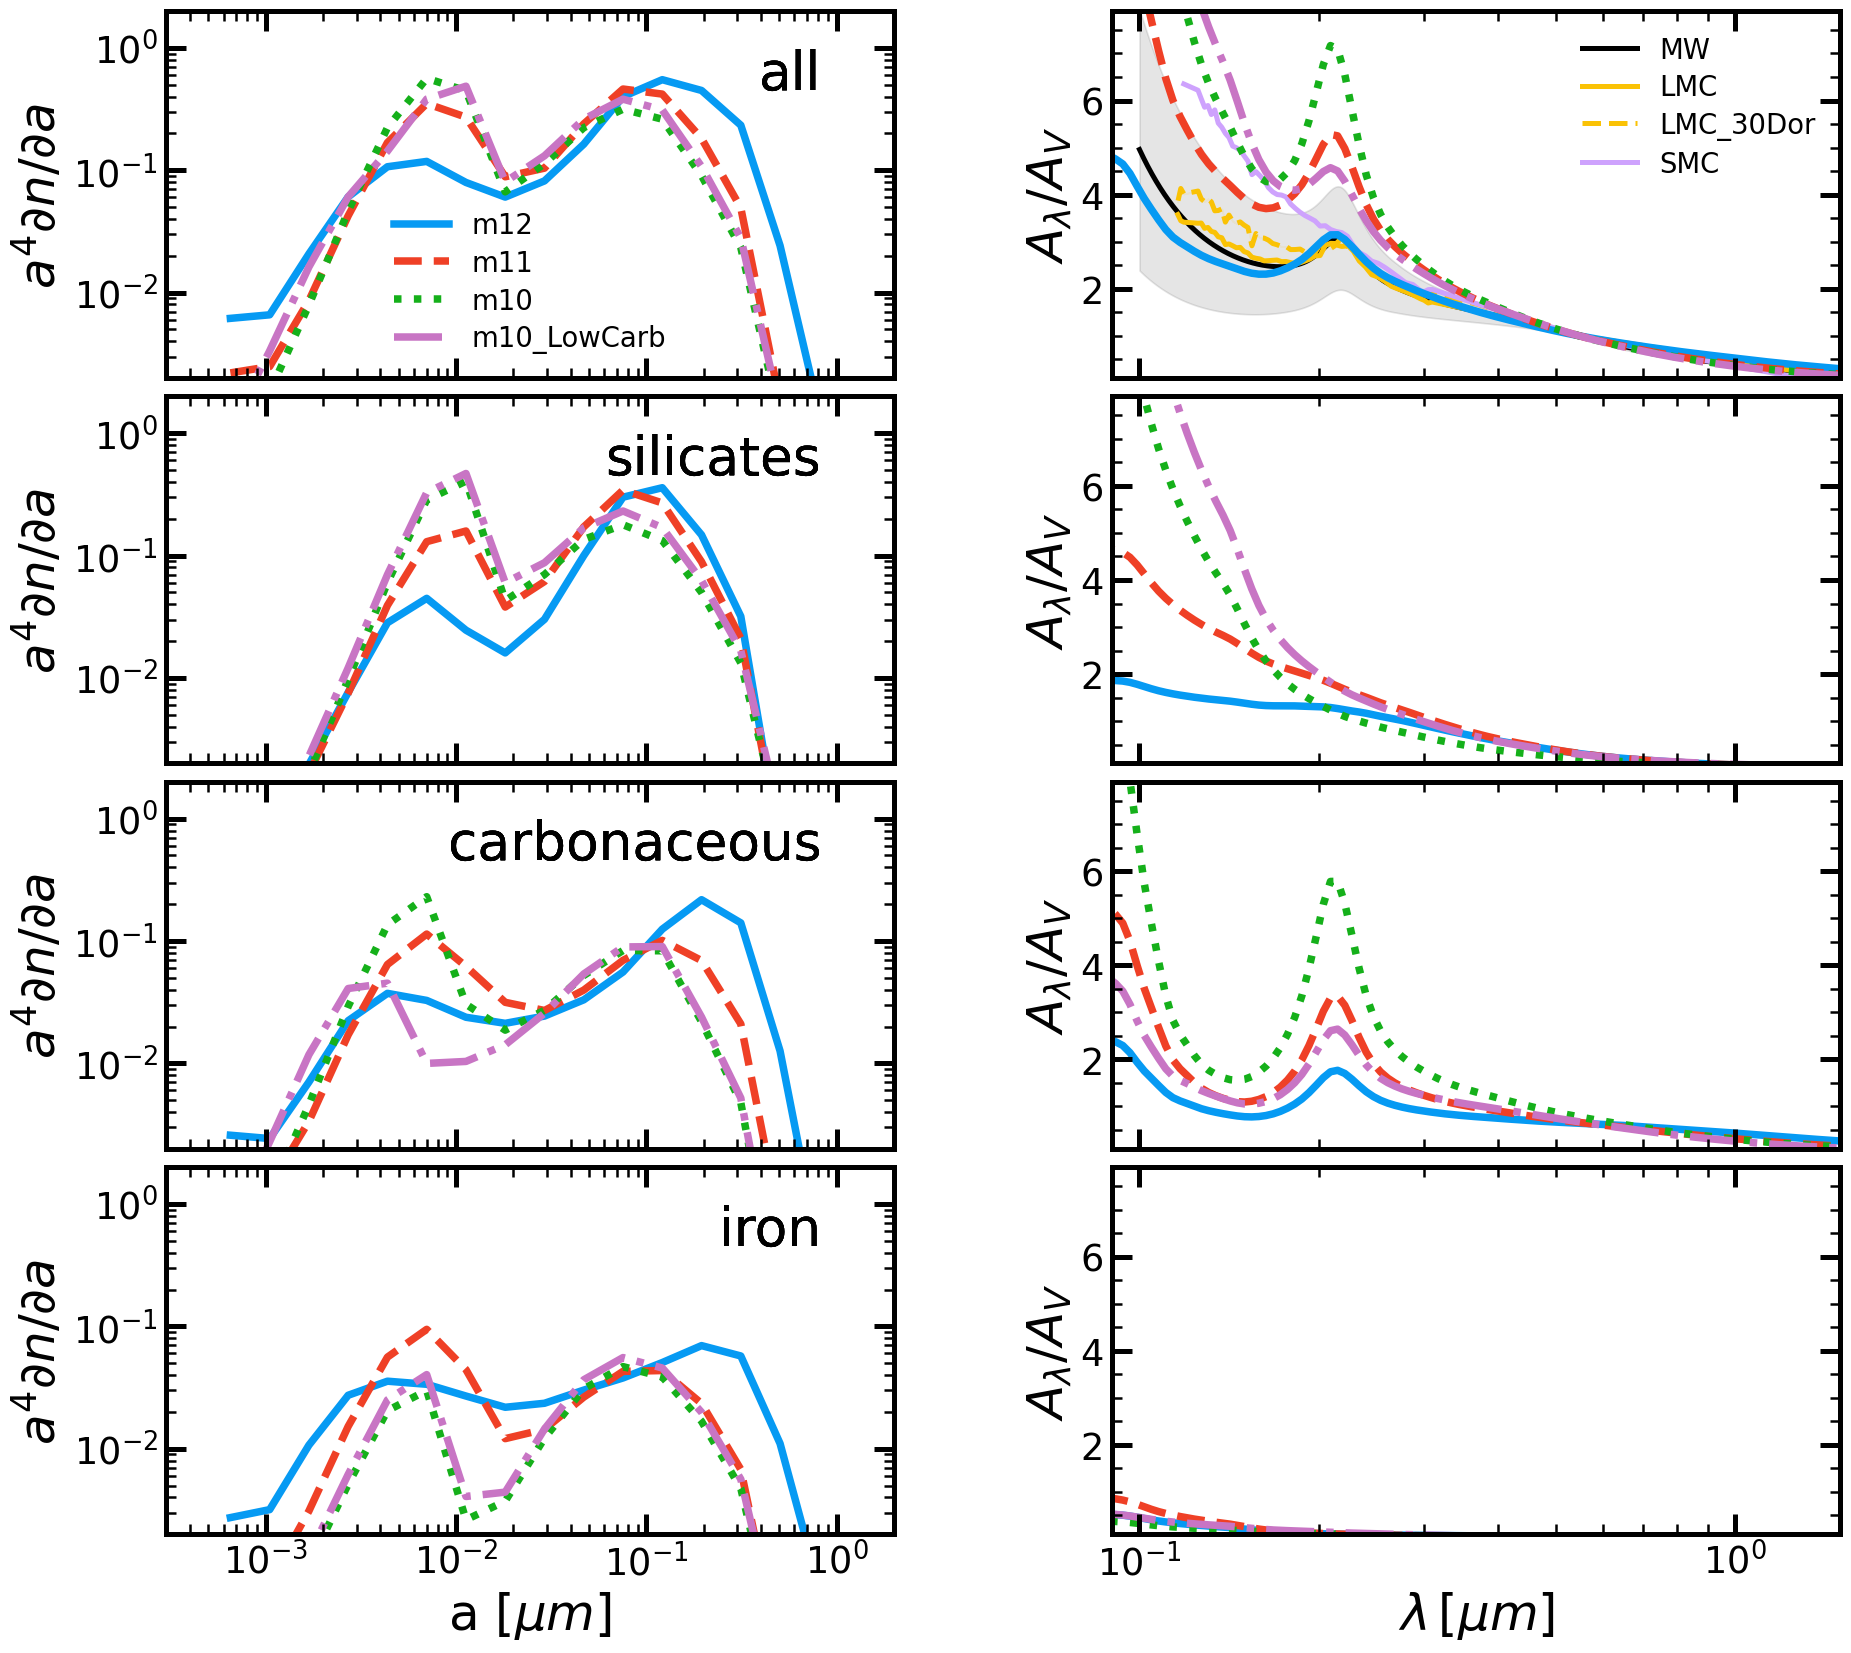

In [114]:

foutname = 'dmdloga_AV_all_species.pdf'


species=['silicates','carbonaceous']
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=False
include_idealized_DraineLi=False

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

alpha=0.0

include_iron=True


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 10

num_figs = 8 if include_iron else 6

fig = Figure(num_figs, yx_ratio=0.65, sharex='col',ncols=2)
num_sims = len(galaxies)
colors = config.LINE_COLORS[:num_sims]
linestyles = config.LINE_STYLES[:num_sims]
linewidth = 1.5*config.BASE_LINEWIDTH

for i in range(num_figs):
    if i % 2 == 0:
        fig.set_axis(i, 'grain_size', 'dm/dloga_norm', y_lim=[2E-3,2E0], y_label=r'$a^4 \partial n/\partial a$')
    else:
        fig.set_axis(i, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0.1,7.9])



obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = -1.5
    MRN_a_vals = np.logspace(-2,-0,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10.,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
    # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
    # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'astrodust',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
    
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)                

# Force all obs size distribution legend elements on first plot
fig.set_axis_legend(0,ncol=3,rescale_font=0.7)

# Plot observed extinction curves
galaxy_names = ['MW','LMC','LMC_30Dor','SMC']
#galaxy_names = ['MW']
obs_colors = ['xkcd:black','xkcd:goldenrod','xkcd:goldenrod','xkcd:lilac']
obs_linestyles = ['-','-','--','-']
subsamples = [0,2,2,2]
for i, galaxy_name in enumerate(galaxy_names):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy_name, subsample=subsamples[i])
    fig.plot_line_data(1,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy_name, std_kwargs={'alpha':0.1})

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))



    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    
    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G,  
                                                        dust_species='all', 
                                                        mask=mask, 
                                                        points_per_bin=points_per_bin, 
                                                        std_percentiles = [16, 84])

    
    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name, linewidth=linewidth)
    fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k],alpha=alpha)

    grain_size_vals, percentile_dnda, percentile_dmdloga = \
    grain_size_utils.get_grain_size_distribution(G,  
                                                    dust_species='silicates', 
                                                    mask=mask, 
                                                    points_per_bin=points_per_bin, 
                                                    std_percentiles = [16, 84])
    fig.plot_line_data(2,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=None, linewidth=linewidth)

    grain_size_vals, percentile_dnda, percentile_dmdloga = \
    grain_size_utils.get_grain_size_distribution(G,  
                                                    dust_species='carbonaceous', 
                                                    mask=mask, 
                                                    points_per_bin=points_per_bin, 
                                                    std_percentiles = [16, 84])
    
    fig.plot_line_data(4,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=None, linewidth=linewidth)

    if include_iron:
        grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G,  
                                                        dust_species='iron', 
                                                        mask=mask, 
                                                        points_per_bin=points_per_bin, 
                                                        std_percentiles = [16, 84])
        
        fig.plot_line_data(6,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=None, linewidth=linewidth)


    fig.add_text(0,0.9,0.9,'all', ha='right',va='top',rescale_font=0.8)
    fig.add_text(2,0.9,0.9,'silicates', ha='right',va='top',rescale_font=0.8)
    fig.add_text(4,0.9,0.9,'carbonaceous', ha='right',va='top',rescale_font=0.8)
    if include_iron:
        fig.add_text(6,0.9,0.9,'iron', ha='right',va='top',rescale_font=0.8)

    wavelength_points = extinction_data[sim_name]['all']['lambda']
    A_lambda_percentiles = extinction_data[sim_name]['all']['AV']
    fig.plot_line_data(1,wavelength_points,A_lambda_percentiles[0], color=colors[k],linestyle=linestyles[k], label = None, linewidth=linewidth)

    wavelength_points = extinction_data[sim_name]['silicates']['lambda']
    A_lambda_percentiles = extinction_data[sim_name]['silicates']['AV']
    fig.plot_line_data(3,wavelength_points,A_lambda_percentiles[0], color=colors[k],linestyle=linestyles[k], linewidth=linewidth)

    wavelength_points = extinction_data[sim_name]['carbonaceous']['lambda']
    A_lambda_percentiles = extinction_data[sim_name]['carbonaceous']['AV']
    fig.plot_line_data(5,wavelength_points,A_lambda_percentiles[0], color=colors[k],linestyle=linestyles[k], linewidth=linewidth)

    if include_iron:
        wavelength_points = extinction_data[sim_name]['iron']['lambda']
        A_lambda_percentiles = extinction_data[sim_name]['iron']['AV']
        fig.plot_line_data(7,wavelength_points,A_lambda_percentiles[0], color=colors[k],linestyle=linestyles[k], linewidth=linewidth)




# Second plot will have simulation legend handles
fig.set_axis_legend(0,ncol=1,rescale_font=0.75)
fig.set_axis_legend(1,ncol=1,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

#### Median Grain Size and Mass Distribution (used for convergence testing)

/N/project/choban_group/cchoban/size_evo_suite/variations/2Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [4.4958294e+05 1.6641473e+03 3.9491010e+06 9.1093969e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/4Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [3.3067055e+06 1.2719117e+03 3.0050125e+06 7.0539992e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/8Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [6.9584585e+06 1.1857490e+03 2.6345118e+06 6.6568242e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [7.7585760e+06 1.1858445e+03 2.5615758e+06 6.7085898e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/32Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [7.4973160e+06 1.2027484e+03 2.5755402e+06 6.8104414e+04]


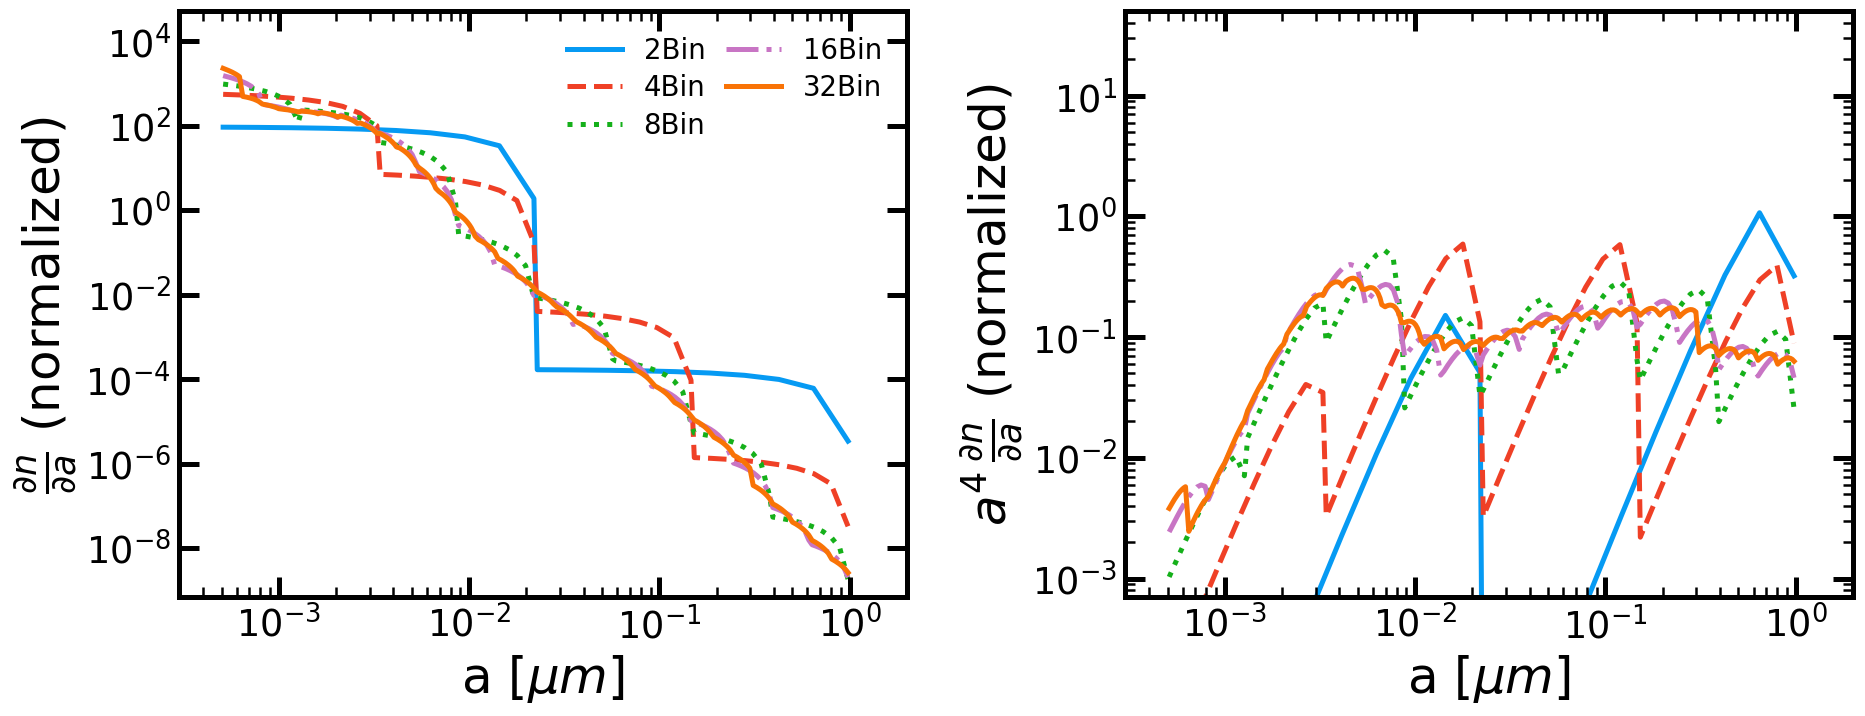

In [109]:

foutname = 'median_dnda_dmdloga.pdf'


species='all'
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=False
include_idealized_DraineLi=False

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

std_percentiles = [16, 84]
std_percentiles= []
#std_percentiles = [2.3, 97.7]

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(2)
fig.set_axis(0, 'grain_size', 'dn/da_norm', y_lim=[7E-10,5E4])
fig.set_axis(1, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E1])

obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = 1
    MRN_a_vals = np.logspace(-3,-1,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm 
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)     


for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    
    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)

    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G, 
                                                    dust_species=species, 
                                                    mask=mask, 
                                                    points_per_bin=points_per_bin, 
                                                    std_percentiles = std_percentiles, weight='gas')

    fig.plot_line_data(0,grain_size_vals,percentile_dnda[0], color=colors[k],linestyle=linestyles[k], label=sim_name)
    fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+ISM_phase+'_gas_'+foutname)

/N/project/choban_group/cchoban/size_evo_suite/variations/2Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [4.4958294e+05 1.6641473e+03 3.9491010e+06 9.1093969e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/4Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [3.3067055e+06 1.2719117e+03 3.0050125e+06 7.0539992e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/8Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [6.9584585e+06 1.1857490e+03 2.6345118e+06 6.6568242e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [7.7585760e+06 1.1858445e+03 2.5615758e+06 6.7085898e+04]
/N/project/choban_group/cchoban/size_evo_suite/variations/32Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [7.4973160e+06 1.2027484e+03 2.5755402e+06 6.8104414e+04]


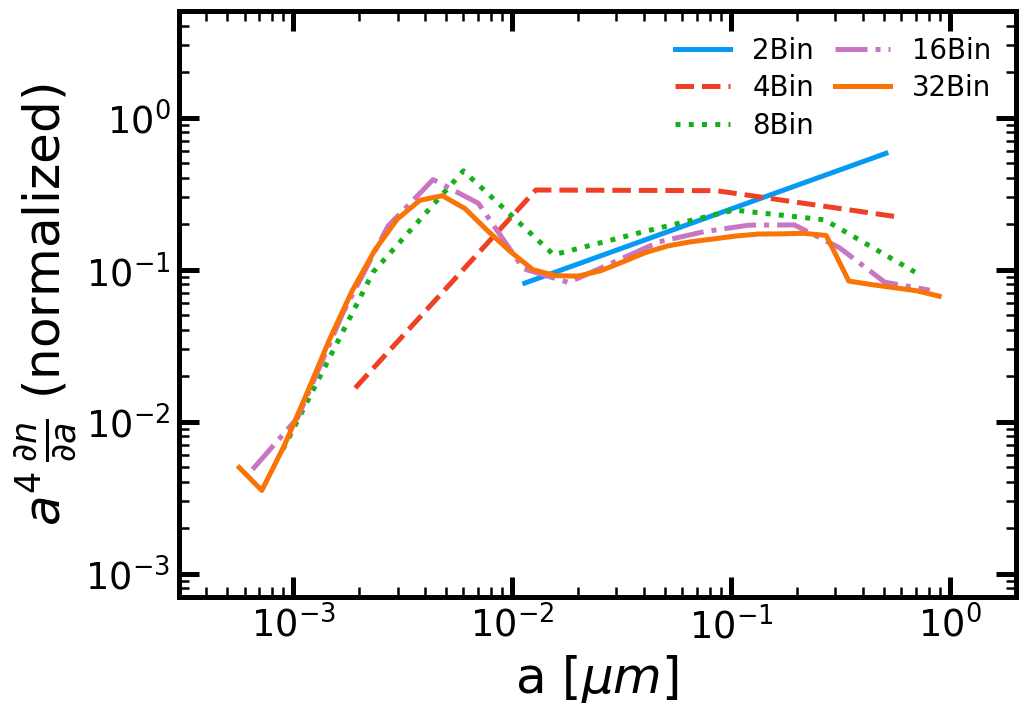

In [111]:

foutname = 'median_dmdloga_convergence.pdf'


species='all'
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=False
include_idealized_DraineLi=False

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

std_percentiles = [16, 84]
std_percentiles= []
#std_percentiles = [2.3, 97.7]

num_snaps = len(galaxies)
num_specs = len(species)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
    
fig = Figure(1)
fig.set_axis(0, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,5E0])

obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = 1
    MRN_a_vals = np.logspace(-3,-1,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm 
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)     


for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))
    
    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)

    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G, 
                                                    dust_species=species, 
                                                    mask=mask,
                                                    points_per_ bin=points_per_bin, 
                                                    std_percentiles = std_percentiles, weight='gas')

    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+ISM_phase+'_gas_'+foutname)

/N/project/choban_group/cchoban/size_evo_suite/variations/2Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [4.4958294e+05 1.6641473e+03 3.9491010e+06 9.1093969e+04]
8
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/4Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [3.3067055e+06 1.2719117e+03 3.0050125e+06 7.0539992e+04]
4
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/8Bin/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [6.9584585e+06 1.1857490e+03 2.6345118e+06 6.6568242e+04]
2
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size_evo_suite/variations/Fiducial/output
Snapshot time: 0.8400000000000005
Total dust mass sources: [7.7585760e+06 1.1858445e+03 2.5615758e+06 6.7085898e+04]
1
 Will truncate grain sizes beyond supported range.
/N/project/choban_group/cchoban/size

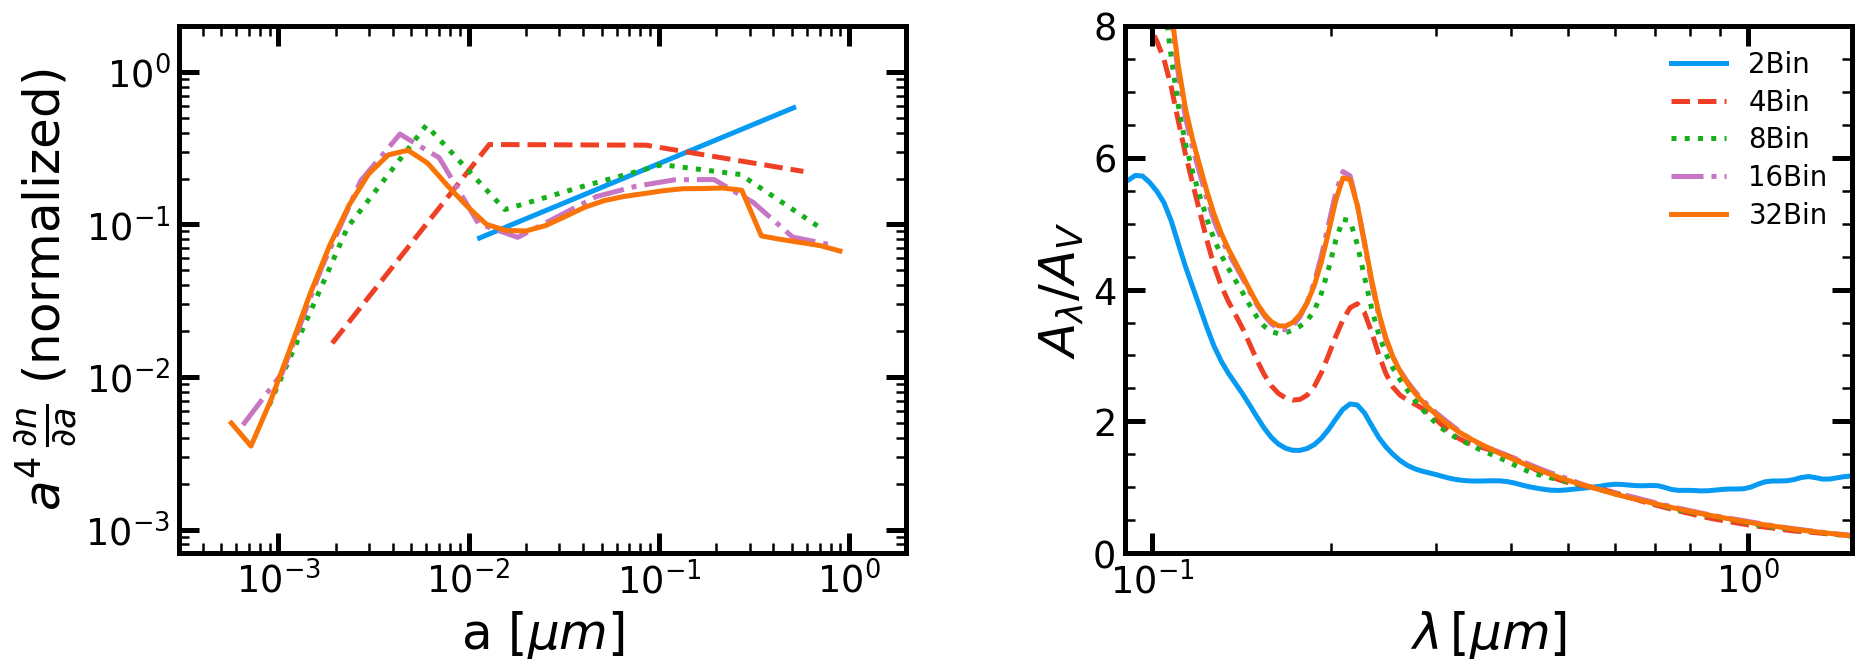

In [113]:

foutname = 'dmdloga_AV_convergence.pdf'


species='all'
ISM_phase = 'all'

include_idealized_MRN=False
include_idealized_astrodust=False
include_idealized_DraineLi=False

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

alpha=0.0


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 10


fig = Figure(2, yx_ratio=0.9)
num_sims = len(galaxies)
colors = config.LINE_COLORS[:num_sims]
linestyles = config.LINE_STYLES[:num_sims]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'dm/dloga_norm', y_lim=[7E-4,2E0])
fig.set_axis(1, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])


obs_linewidth = 1.5*config.BASE_LINEWIDTH
obs_alpha = 1
if include_idealized_MRN:
    y_offset = 1
    MRN_a_vals = np.logspace(-3,-1,10)
    dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
    dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
    fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle=':', linewidth=obs_linewidth,
                        label='MRN', alpha = obs_alpha)
    # x_coord = MRN_a_vals[len(MRN_a_vals)//4]
    # y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
if include_idealized_astrodust:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    astrodust_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.astrodust_dmdloga, amin, amax)[0] + quad(grain_size_utils.astrodust_dmdloga, amin, amax, args=(True))[0]
    # astrodust
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=False)/dmdloga_norm
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='-', linewidth=obs_linewidth,
                        label='HD23 astrodust', alpha = obs_alpha)
    # PAHs
    dmdloga_vals=grain_size_utils.astrodust_dmdloga(astrodust_a_vals,PAHs=True)/dmdloga_norm
    
    fig.plot_line_data(0,astrodust_a_vals,dmdloga_vals, color='xkcd:black',linestyle='--', linewidth=obs_linewidth,
                        label='HD23 PAHs', alpha = obs_alpha)
    # x_coord = astrodust_a_vals[len(astrodust_a_vals)//4]
    # y_coord = dmdloga_vals[len(astrodust_a_vals)//2]
    # fig.add_text(0,x_coord,y_coord,r'astrodust',
    #             ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')    

if include_idealized_DraineLi:
    idealized_bins = 100
    amin = 5E-4; amax = 1
    DL_a_vals = np.logspace(np.log10(amin),np.log10(amax),idealized_bins)
    # Normalize astrodust+PAHs
    dmdloga_norm = quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("silicates"))[0] + quad(grain_size_utils.DL07_dmdloga, amin, amax, args=("carbonaceous"))[0]
    # silicates
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='silicates')/dmdloga_norm
    
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='-', linewidth=obs_linewidth,
                        label='DL07 sil', alpha = obs_alpha)
    # carbonaceous
    dmdloga_vals=grain_size_utils.DL07_dmdloga(DL_a_vals,species='carbonaceous')/dmdloga_norm
    
    fig.plot_line_data(0,DL_a_vals,dmdloga_vals, color='xkcd:slate grey',linestyle='--', linewidth=obs_linewidth,
                        label='DL07 carb', alpha = obs_alpha)                

# Force all obs size distribution legend elements on first plot
fig.set_axis_legend(0,ncol=2,rescale_font=0.75)

# Plot observed extinction curves
galaxy_names = ['MW','LMC','LMC_30Dor','SMC']
galaxy_names = []
obs_colors = ['xkcd:black','xkcd:gold','xkcd:gold','xkcd:blue']
obs_linestyles = ['-','-','--','-']
subsamples = [0,2,2,2]
for i, galaxy_name in enumerate(galaxy_names):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy_name, subsample=subsamples[i])
    fig.plot_line_data(1,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy_name, std_kwargs={'alpha':0.1})

for k,halo in enumerate(galaxies):
    sp = halo.sp
    print(sp.sdir)
    sim_name = sim_names[k]
    G=halo.loadpart(0)

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))



    mask = calc.get_particle_mask(0, halo, mask_criteria=ISM_phase)
    
    grain_size_vals, percentile_dnda, percentile_dmdloga = \
        grain_size_utils.get_grain_size_distribution(G,  
                                                        dust_species=species, 
                                                        mask=mask, 
                                                        points_per_bin=points_per_bin, 
                                                        std_percentiles = [16, 84])

    fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=sim_name)
    fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k],alpha=alpha)

    if sp.Flag_GrainSizeBins < 16:
        bin_subsamples=16//sp.Flag_GrainSizeBins
    else: bin_subsamples=1
    print(bin_subsamples)

    wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species=species, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)
    fig.plot_line_data(1,wavelength_points,A_lambda_percentiles[0], color=colors[k],linestyle=linestyles[k], label = sim_name)
    fig.plot_shaded_region(1,wavelength_points,A_lambda_percentiles[1],A_lambda_percentiles[2], color=colors[k],linestyle=linestyles[k],alpha=alpha)


# Second plot will have simulation legend handles
fig.set_axis_legend(1,ncol=1,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+cut_name+'_'+str(sp.snum)+'_'+foutname)

## Results

Simulation results considering only gas within galactic disk

### Grain Bin Convergence

### Variations in Dust Processes

Variations have been grouped into subgroups comparing with the fiducial model. 
The plots comparing variation groups are the same so you only need to load in the subgroup you want to make the plots for.

#### Load Simulations

In [ ]:
# Disk parameters use for all comparisons
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

# Directory of simulations
main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot number
snap_num = 100

##### Fiducial Model

In [ ]:
group_name = 'fiducial_comparison'

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_Tcutoff1000K/output',
             main_dirc+'/MW_5xCDense/output'
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             'Tcutoff1000K',
             '5xCDense'
             ]

halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    G = halo.loadpart(0)
    S = halo.loadpart(4)

    print("gas mass", np.sum(G.get_property('mass'))/1E10,'Msol')
    print("star mass", np.sum(S.get_property('mass'))/1E10,'Msol')
    print('dust mass', np.sum(G.get_property('M_dust'))/1E10,'Msol')
    phases=['cold','cool','warm','hot']
    for phase in phases:
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print(phase,'gas mass:', np.sum(G.get_property('mass')[mask])/1E10)

    halos += [halo]


##### Variations in Accretion and SNe Dest.

In [ ]:
group_name = 'acc_dest_comparison'

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'



# Snapshot to check
snap_num = 100

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_0.25xAccretion/output',
             main_dirc+'/MW_4xSNeDest/output',
             main_dirc+'/MW_Tcut300K/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '0.25xAccretion',
             '4xSNeDest',
             'Tcut300K',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


##### Variations in Coagulation and Shattering

In [ ]:
group_name = 'coag_shat_comparison'

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_5xCDense/output',
             main_dirc+'/MW_NoCoag/output',
             main_dirc+'/MW_NoShat/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '5xCdense',
             'no_coagulation',
             'no_shattering',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


#### Phase Diagram

In [ ]:
foutname = 'clumping_factor_phase_diagram.pdf'
prop = 'M_gas'
z_logs=[True]
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [1,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.1,1]]

fig = Figure(len(halos),ncols=2, sharey=True, sharex=True)

for i,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]



    # Set up for each plot
    fig.set_axis(i, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(i, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[0], z_log=z_logs[0],label=name)

# Add colorbar to last axis
fig.add_colorbar(len(halos)-1,cbar_prop=prop)

fig.save(plot_dir+group_name+'_'+str(snap_num)+'_'+foutname)

#### Projection

In [ ]:

foutname = '_projections.pdf'

# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
property = 'sigma_gas'
# Limits for projection of each property. Defaults if not set
prop_limit = [8E-1,2E3]
# Colormaps for each projection
prop_cmap = 'inferno'
# Do you want log colormaps for each property (default = True)
log_cmap = True
# Labels for each projection is so desired
label = 'gas'
# Physical size of projection 
proj_L = 50 # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = False
# size of secondary projection
sub_L = 2 # kpc


new_proj = Projection(len(halos), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)
for i,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[i]
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,1]
    
    # Create projections for each property and plot the projection
    new_proj.set_proj_axis(i, property, L, axes_visible=False)
    # Create x-y projection using a 2D histogram
    main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(property, halo, [L,L,L], pixel_res=pixel_res, proj='xy')
    if sub_proj:
        # Create x-z subprojection using a 2D histogram
        sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(property, halo, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
    else:
        sub_pixel_stats=None; sub_extent=None
    # x-z projection
    # Create the projection
    new_proj.plot_projection(i, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                cmap= prop_cmap, v_limits = prop_limit,v_log=log_cmap, label=name)
        
new_proj.save(plot_dir+group_name+'_'+str(snap_num)+'_'+property+'_'+foutname)

#### Dust Population Trends with Density and Temperature

In [ ]:
foutname = 'DZ_STC_STL_vs_gas.pdf'

fig = Figure(6,ncols=2, sharex='col')

colors = config.LINE_COLORS[:len(halos)]
linestyles = config.LINE_STYLES[:len(halos)]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

DZ_lims = [0,0.8]
fig.set_axis(0, 'nH_rms', 'D/Z', y_log=False, y_lim=DZ_lims)
fig.set_axis(1, 'T_eff', 'D/Z', y_log=False, y_lim=DZ_lims)
fig.set_axis(2, 'nH_rms', 'Si/C')
fig.set_axis(3, 'T_eff', 'Si/C')
fig.set_axis(4, 'nH_rms', 'f_STL')
fig.set_axis(5, 'T_eff', 'f_STL')


bin_nums=15




for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]




    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0], label=name)
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(2,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(2,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(3,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(3,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    for j, spec in enumerate(['sil','carb','iron']):
        if len(halos)<=1: color_index = j
        else: color_index = i
        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'nH',halo, bin_nums=bin_nums)
        fig.plot_line_data(4,bin_vals,mean_vals, color=colors[color_index],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(4,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[color_index])

        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'T',halo, bin_nums=bin_nums)
        fig.plot_line_data(5,bin_vals,mean_vals, color=colors[color_index],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(5,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[color_index])
    
    
    fig.set_axis_legend(4, rescale_font=0.75)

fig.set_axis_legend(0, rescale_font=0.75)
fig.save(plot_dir+group_name+'_'+str(snap_num)+'_'+foutname)

#### Grain Size Distribution for Each Species

In [ ]:

foutname = 'median_dmdloga.pdf'
species=['silicates','carbonaceous','iron']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(species)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,species[i],ha='left',va='top',)

    if i==0:
        sp = halos[0].sp
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    name = sim_names[k]
    G=halo.loadpart(0)
    sp = halo.sp
    print(sp.sdir)


    for i, spec in enumerate(species):
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=None, points_per_bin=points_per_bin, weight='gas')

        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+str(snap_num)+'_'+foutname)

#### Grain Size Distribution for Each Gas Phase

In [ ]:

foutname = 'gas_phase_dmdloga.pdf'
spec = 'carbonaceous'
phases=['cold','cool','warm','hot']
phase_labels=[f'cold \n'+r'($T<300$ K)', f'cool \n'+r'($300\,{\rm K}<T<10^3$ K)',f'warm \n'+r'($10^3\,{\rm K}<T<10^4$ K)',f'hot \n'+r'($T>10^4$ K)']
#phase_labels=[f'cold '+r'($T<300$ K)', f'cool '+r'($300\,{\rm K}<T<10^3$ K)',f'warm '+r'($10^3\,{\rm K}<T<10^4$ K)',f'hot '+r'($T>10^4$ K)']
# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(4,ncols=2)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(phases)):
    phase_label = phase_labels[i]
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,phase_label,ha='left',va='top',rescale_font=0.75)

    if i==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    for i, phase in enumerate(phases):
        phase_label = phase_labels[i]
        print(phase)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print('mass of gas:', np.sum(G.get_property('mass')[mask])/1E10)
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=mask, points_per_bin=points_per_bin, weight='dust')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+str(sp.snum)+'_'+spec+'_'+foutname)

In [ ]:

foutname = 'gas_phase_dmdloga.pdf'
spec = 'silicates'
phases=['cold','cool','warm','hot']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(4,ncols=2)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(phases)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,phases[i],ha='left',va='top')

    if i==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    for i, phase in enumerate(phases):
        print("ISM phase:",phase)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print(np.sum(G.get_property('mass')[mask])/np.sum(G.get_property('mass'))*100,'% of gas in phase')
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=mask, points_per_bin=points_per_bin, weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


    for i,phase in enumerate(ISM_phases):
            mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
            print("ISM phase:",phase)
            print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

            fig.set_axis(i, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])
            
    
            for j, spec in enumerate(species):
                
                grain_size_vals, percentile_dnda, percentile_dmdloga = \
                    grain_size_utils.get_grain_size_distribution(G, 
                                                                species=spec, 
                                                                mask=mask, 
                                                                points_per_bin=points_per_bin, 
                                                                std_percentiles = [16, 84])


                fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
                fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
                fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

                fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+group_name+'_'+str(sp.snum)+'_'+foutname)


for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)
    num_specs = len(species)
    num_phases = len(ISM_phases)


    fig = Figure(num_phases,ncols=2, sharex='col',sharey='row')

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        fig.set_axis(i, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

        if i==0:
            y_offset = 0.4
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(i,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
            for j, spec in enumerate(species):
                # Lines used for the legend handles. Should not show up in plot
                fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
 
        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(G, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])


            fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
            fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Load Simulations

In [ ]:

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot to check
snap_num = 150

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_8Bin/output',
             main_dirc+'/MW_4Bin/output',
             main_dirc+'/MW_2Bin/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '8_bin',
             '4_bin',
             '2_bin',
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


#### D/Z Relation

In [ ]:


foutname = 'bin_convergence_DZ_STC_STL_vs_gas.pdf'

fig = Figure(6,ncols=2, sharex='col')
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:3]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1

fig.set_axis(0, 'nH', 'D/Z')
fig.set_axis(1, 'T', 'D/Z')
fig.set_axis(2, 'nH', 'Si/C')
fig.set_axis(3, 'T', 'Si/C')
fig.set_axis(4, 'nH', 'f_STL')
fig.set_axis(5, 'T', 'f_STL')


bin_nums=15




for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]




    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0], label=name)
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','nH',halo, bin_nums=bin_nums)
    fig.plot_line_data(2,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(2,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('Si/C','T',halo, bin_nums=bin_nums)
    fig.plot_line_data(3,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[0])
    fig.plot_shaded_region(3,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

    for j, spec in enumerate(['sil','carb','iron']):
        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'nH',halo, bin_nums=bin_nums)
        fig.plot_line_data(4,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(4,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])

        bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('f_STL_'+spec,'T',halo, bin_nums=bin_nums)
        fig.plot_line_data(5,bin_vals,mean_vals, color=colors[i],linestyle=linestyles[j], label=spec)
        fig.plot_shaded_region(5,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[i])
    
    fig.set_axis_legend(0)
    fig.set_axis_legend(4)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)


#### Grain Size Distribution

In [ ]:

foutname = 'bin_convergence_median_dmdloga.pdf'
species=['silicates','carbonaceous','iron']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=[10,20,40,80]


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(species)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,species[i],ha='left',va='top',)



for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    if k==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')

    for i, spec in enumerate(species):
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=None, points_per_bin=points_per_bin[k], weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        #fig.plot_shaded_region(1,dmdloga_bin_points,dmdloga_stds[:,0],dmdloga_stds[:,1], color=colors[i],linestyle=linestyles[j]


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

### General Analysis

General gas, star, and basic dust analysis plots for the specified simulations.

#### Load Galactic Disk of Simulations

In [ ]:

# Disk parameters
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height


main_dirc = '/N/project/choban_group/cchoban/size_evo_suite'

# Snapshot to check
snap_num = 100

# snap_dirs = [main_dirc+'/MW_Fiducial/output',
#              main_dirc+'/MW_Coag_Only/output',
#              ]

# # Shorthand names for each sim used in plot legends and file names
# sim_names = ['fiducial',
#              'coag_only',
#              ]

snap_dirs = [main_dirc+'/MW_Fiducial/output',
             main_dirc+'/MW_CoagOnly_100xVcoag/output',
             main_dirc+'/MW_CoagOnly_Dense_Enhancement/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['fiducial',
             '100xVCoag',
             'DenseEnhancement'
             ]


halos = []


for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    halo = sp.loadhalo(mode=None)
    halo.set_disk(rmax = disk_radius, height=disk_scale_height)
    halo.set_orientation(ptype=4, mass_radius_max = 10, velocity_radius_max=10, radius_max=10, age_limits=[0,0.5])
    halos += [halo]


#### Gas and Star Properties

##### Projections

In [ ]:

foutname = 'disk_projections.pdf'

# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
properties = ['sigma_gas','sigma_star','sigma_dust']
# Limits for projection of each property. Defaults if not set
prop_limits = [[8E-1,2E3],[2E0,2E4],[8E-3,2E1]]
# Colormaps for each projection
prop_cmaps = ['inferno','viridis','cividis']
# Do you want log colormaps for each property (default = True)
log_cmaps = [True]*len(properties)
# Labels for each projection is so desired
labels = ['gas','stars','dust']
# Physical size of projection 
proj_L = 2*disk_radius # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = True
# size of secondary projection
sub_L = 4*disk_scale_height # kpc


for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,0.5]
    new_proj = Projection(len(properties), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)
    # Create projections for each property and plot the projection
    for j,prop in enumerate(properties):
        new_proj.set_proj_axis(j, prop, L, axes_visible=False)
        # Create x-y projection using a 2D histogram
        main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(prop, halo, [L,L,L], pixel_res=pixel_res, proj='xy')
        if sub_proj:
            # Create x-z subprojection using a 2D histogram
            sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(prop, halo, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
        else:
            sub_pixel_stats=None; sub_extent=None
        # x-z projection
        # Create the projection
        if labels is not None:
            label = labels[j]
        else:
            label=None
        new_proj.plot_projection(j, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                    cmap= prop_cmaps[j], v_limits = prop_limits[j],v_log=log_cmaps[j], label=label)
        
    new_proj.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

##### Gas-Phase Diagrams

In [ ]:
foutname = 'disk_phase_diagram.pdf'
props = ['M_gas','M_H2','mach_number','D/Z']
fig_labels = ['all gas','H2 gas','mach','D/Z']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [5,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.01,0.5]]


for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(prop, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims)
        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop=prop)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

##### SFH

In [ ]:
foutname = 'disk_SFH.pdf'


for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    time, cum_SFH = snap_utils.get_SFH(halo, cum=1)

    stars = halo.loadpart(4)
    sft, m = stars.get_property('sft'), stars.get_property('M_form')
    time, sfr = math_utils.SFH(sft, m, halo, dt=0.005, cum=False)

    fig = Figure(2,ncols=2)

    time_lims = [0,1.5]

    fig.set_axis(0, 'time', 'sfr', x_lim=time_lims,x_log=False,twin_time_axis=False)
    fig.set_axis(1, 'time', 'M_star', x_lim=time_lims,x_log=False,twin_time_axis=False)


    fig.plot_line_data(0,time,sfr)

    fig.plot_line_data(1,time,cum_SFH)


    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)


### Dust Properties

#### Analytical Checks

Checking gas-dust accretion and sputtering rates and gas which allows coagulation and shattering.

##### Accretion and Sputtering

In [ ]:
foutname = 'disk_dust_rate_phase_diagram.pdf'
props = ['dMdt_acc','dMdt_acc','dMdt_acc','dMdt_sput']
fig_labels = ['accretion \n T<300K','accretion \n T<600K','accretion \n T<1000K','sputtering']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E-7,1E-4],[1E-7,1E-4],[1E-7,1E-4],[1E-8,1E-6]]

# Number of subsampling for each bin when calculating dMdt rates.
# N=1 will assume all grains have the same size in each bin
# Set to a small number to get a good estimate
bin_subsamples = 4



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    G = halo.loadpart(0)
    #dMdt_shat, dMdt_coag = grain_size_utils.get_dust_shattering_and_coagulation_rate(G)

    dMdt_acc1 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=300, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc1),'Msol/yr')
    dMdt_acc2 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=600, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc2),'Msol/yr')
    dMdt_acc3 = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=1000, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc3),'Msol/yr')
    dMdt_sput = grain_size_utils.get_dust_sputtering_rate(G, T_cutoff = 1E4, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_sput:',np.sum(dMdt_sput),'Msol/yr')

    dMdt=[dMdt_acc1,dMdt_acc2,dMdt_acc3,-dMdt_sput]


    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(dMdt[j], halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

##### Coagulation and Shattering

Gas phase diagram with median grain velocities for each size bin which satisfy either coagulation or shattering threshold velocities.
Assuming either Kolmogorov or supersonic turbulence power spectrum.

###### Kolmogorov Turbulence

In [ ]:
foutname = 'disk_Kolmogorov_vgrain.pdf'
prop = 'v_grain'
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    rho_c = 3.1
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.1g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vshat_'+foutname)
        

###### Supersonic Turbulence

In [ ]:
foutname = 'disk_supersonic_vgrain.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.2g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vshat_'+foutname)

###### Lebreuilly23 Grain Velocity Prescription

In [ ]:
foutname = 'disk_Lebreuilly23_vgrain.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('silicates')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = gse_models.grain_relative_velocity(agrain*config.um_to_cm,
                                    a_collider*config.um_to_cm,
                                    rho_c, 
                                    ISM_phase=None, 
                                    scheme='Lebreuilly23',
                                    gas_particles=gas,)*1E-5 # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')

        M_gas = gas.get_property('mass')
        M_gas[vgr>vcoag] = 0
        mass_coag = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic
        
        vgr_coag = ret.statistic.T
        vgr_coag[vgr_coag>vcoag] = np.nan
        print('a_grain: %2.2g'%agrain,'v_coag: %2.2g'%vcoag,'fraction of gas < v_coag: %2.2g'%(np.nansum(mass_coag)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_coag, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.1g\,\mu m$'%agrain+'\n'+r'$v_{\rm coag}=%2.1g$ km/s'%vcoag)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


    fig = Figure(bin_num,ncols=4, sharex='col',sharey='row')
 

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        vgr = gse_models.grain_relative_velocity(agrain*config.um_to_cm,
                                    a_collider*config.um_to_cm,
                                    rho_c, 
                                    ISM_phase=None, 
                                    scheme='Lebreuilly23',
                                    gas_particles=gas,)*1E-5 # km/s
        
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(vgr, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='median')
        
        M_gas = gas.get_property('mass')
        M_gas[vgr<v_shat] = 0
        mass_shat = calc.calc_phase_hist_data(M_gas, halo, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum').statistic

        vgr_shat = ret.statistic.T
        vgr_shat[vgr_shat<v_shat] = np.nan
        print('a_grain: %2.2g'%agrain,'v_shat: %2.2g'%v_shat,'fraction of gas > v_shat: %2.2g'%(np.nansum(mass_shat)/np.sum(gas.get_property('mass'))))


        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, vgr_shat, cmap=cmap, z_lim=prop_lim, z_log=z_log,label=r'$a=%1.2g\,\mu m$'%agrain+'\n'+r'$v_{\rm shat}=%2.2g$ km/s'%v_shat)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_label=r'$v_{\rm gr}$ [km/s]')
    
    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vshat_'+foutname)

In [ ]:
foutname = 'disk_Mshatcoag.pdf'
props = ['v_grain']
z_log=True
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lim=[1E-2,1E1]



for i,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[i]

    gas = halo.sp.loadpart(0)
    nH = gas.get_property('nH')
    rho = gas.get_property('density')
    temp = gas.get_property('temperature')
    M = gas.get_property('mach_number')
    
    b = 0.5
    nH_rms =np.sqrt(1+b*b*M*M)*nH

    spec_props = config.dust_species_properties('carbonaceous')
    rho_c = spec_props['rho_c'] # Bulk density of silicates [g/cm^3]
    poisson = spec_props['poisson'] # Poisson ratio
    youngs = spec_props['youngs'] # Young's modulus [GPa]
    gamma = spec_props['gamma'] # Surface energy [J/m^2]
    v_shat = spec_props['v_shat']*1E-5 # Shattering velocity [km/s]

    bin_num = halo.sp.Flag_GrainSizeBins
    a_centers = halo.sp.Grain_Bin_Centers

    fig = Figure(3,ncols=3, sharey='row')
    fig.set_axis(0,'grain_size','M_gas',y_lim = [1E7,1E10])
    fig.set_axis(1,'grain_size','M_gas',y_lim = [1E7,1E10])
    fig.set_axis(2,'grain_size','M_gas',y_lim = [1E7,1E10])


    M_coag1 = np.zeros(bin_num)
    M_coag2 = np.zeros(bin_num)
    M_shat = np.zeros(bin_num)

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.066 * (M/3) * (agrain) * \
        np.power(nH_rms/1E3,-0.5)*(rho_c/3.5) # km/s

        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        M_gas = gas.get_property('mass')
        M_coag1[j] = np.sum(M_gas[vgr<vcoag])
        M_coag2[j] = np.sum(M_gas[vgr<10*vcoag])
        M_shat[j] = np.sum(M_gas[vgr>v_shat])


    fig.plot_line_data(0, a_centers, M_shat, color='red', label='shatter')
    fig.plot_line_data(0, a_centers, M_coag1, color='blue', label='coagulation')
    fig.plot_line_data(0, a_centers, M_coag2, color='green', label=r'$10\times v_{\rm coag}$')
    fig.add_text(0,0.05,0.95,'Supersonic', ha='left', va='top', rescale_font=0.75)


    M_coag1 = np.zeros(bin_num)
    M_coag2 = np.zeros(bin_num)
    M_shat = np.zeros(bin_num)

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = 0.32 * (M/3) * np.power(agrain,0.5) * np.power(temp/100,0.25) * \
        np.power(nH_rms/1E3,-0.25)*np.power(rho_c/3.5,0.5) # km/s


        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        M_gas = gas.get_property('mass')
        M_coag1[j] = np.sum(M_gas[vgr<vcoag])
        M_coag2[j] = np.sum(M_gas[vgr<vcoag*10])
        M_shat[j] = np.sum(M_gas[vgr>v_shat])
    
    fig.plot_line_data(1, a_centers, M_shat, color='red', label='shatter')
    fig.plot_line_data(1, a_centers, M_coag1, color='blue', label='coagulation')
    fig.plot_line_data(1, a_centers, M_coag2, color='green', label=r'$10\times v_{\rm coag}$')
    fig.add_text(1,0.05,0.95,'Kolmogorov', ha='left', va='top', rescale_font=0.75)

    M_coag1 = np.zeros(bin_num)
    M_coag2 = np.zeros(bin_num)
    M_shat = np.zeros(bin_num)

    for j in range(bin_num):
        agrain = a_centers[j]
        a_collider=agrain
        # Grain velocity assuming supersonic turbulence
        vgr = gse_models.grain_relative_velocity(agrain*config.um_to_cm,
                                    a_collider*config.um_to_cm,
                                    rho_c, 
                                    ISM_phase=None, 
                                    scheme='Lebreuilly23',
                                    gas_particles=gas,)*1E-5 # cm/s to km/s


        vcoag = gse_models.v_coagulation(agrain*config.um_to_cm,a_collider*config.um_to_cm,
                        rho_c,poisson,youngs,gamma,fudge_factor=True) * 1E-5 # cm/s to km/s

        M_gas = gas.get_property('mass')
        M_coag1[j] = np.sum(M_gas[vgr<vcoag])
        M_coag2[j] = np.sum(M_gas[vgr<vcoag*10])
        M_shat[j] = np.sum(M_gas[vgr>v_shat])
    
    fig.plot_line_data(2, a_centers, M_shat, color='red', label='shatter')
    fig.plot_line_data(2, a_centers, M_coag1, color='blue', label='coagulation')
    fig.plot_line_data(2, a_centers, M_coag2, color='green', label=r'$10\times v_{\rm coag}$')
    fig.add_text(2,0.05,0.95,'Lebreuilly23', ha='left', va='top', rescale_font=0.75)  


    fig.set_all_legends()
      
    
    #fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_vcoag_'+foutname)


### Grain Size Distribution

#### Median Comparison for each dust species

In [ ]:

foutname = 'comparison_median_dmdloga.pdf'
species=['silicates','carbonaceous','iron']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(species)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,species[i],ha='left',va='top',)



for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    if k==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')

    for i, spec in enumerate(species):
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=None, points_per_bin=points_per_bin, weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+str(sp.snum)+'_'+foutname)

#### Median Comparison for each gas phase

In [ ]:

foutname = 'gas_phase_dmdloga.pdf'
spec = 'silicates'
phases=['cold','warm','hot']

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10


fig = Figure(3,ncols=3)
num_specs = len(species)
num_snaps = len(halos)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH

for i in range(len(phases)):
    fig.set_axis(i, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])
    fig.add_text(i,0.05,0.95,phases[i],ha='left',va='top',)

    if i==0:
        MRN_a_vals = np.logspace(-2,-1,10)
        y_offset = 1
        dmda_norm = quad(gse.MRN_dmda, halo.sp.Grain_Size_Min, halo.sp.Grain_Size_Max)[0]
        dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
        fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')


for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    for i, phase in enumerate(phases):
        print(phase)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        
        grain_size_vals, percentile_dnda, percentile_dmdloga = grain_size_utils.get_grain_size_distribution(
            G, species=spec, mask=mask, points_per_bin=points_per_bin, weight='gas')


        fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[k],linestyle=linestyles[k], label=name)
        fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[k],linestyle=linestyles[k])


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+str(sp.snum)+'_'+foutname)

### Extinction Curves

#### $A_V$ Idealized


Assuming MRN size distribution with a MW dust-to-gas ratio, Av/NH ~ 0.5E-22

In [ ]:
grain_size_utils.calculate_idealized_Av(NH = 1E21,
                        DTG = 0.014*0.5,
                        amin = 1E-3,
                        amax = 3E-1,
                        sil_to_carbon_ratio = 2.0,
                        MRN_slope = -3.5)

#### $A_V$ Histogram

In [ ]:
foutname = 'disk_Av_histogram.pdf'
ISM_phases = ['all']
species=['all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1

AV_limits = [0.01,0.21]
AV_log = True



for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)


    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'A_V', 'PDF', x_lim=AV_limits, y_lim=[0,1], x_label=r'$A_V$', y_label = 'PDF', y_log = False, x_log=AV_log)

    print("Snapshot time:",halo.sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))

    for i,phase in enumerate(ISM_phases):

        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        #mask = (G.get_property('nH') > 1E1) & (G.get_property('T') < 1E4) & (G.get_property('D/Z') > 0.001)
        print("ISM phase:",phase)

        print(len(G.get_property('nH')[mask]),'gas cells in mask')

        # Some print outs to check column densities of gas cells
        print('D/Z',G.get_property('D/Z')[mask])
        hsml = np.asarray(G.get_property('size')[mask],dtype=np.float64) * config.kpc_to_cm * config.cm_to_um # [microns]
        gas_mass =  np.asarray(G.get_property('M_gas')[mask],dtype=np.float64)*config.Msolar_to_g # [grams]
        Sigma_H = gas_mass*0.7/config.H_MASS / (np.pi * hsml*config.um_to_cm * hsml*config.um_to_cm)
        bin_nums = G.get_property('grain_bin_num')[mask]
        sigma_dust = np.sum(bin_nums,axis=(1,2))/(np.pi * hsml*config.um_to_cm * hsml*config.um_to_cm)
        print("Sigma H:",Sigma_H)
        print("Sigma dust:",sigma_dust)

        for j, spec in enumerate(species):

            A_V = grain_size_utils.calculate_Av(G, 
                                                species=spec, 
                                                mask = mask, 
                                                bin_subsamples = bin_subsamples)
            print('AV',A_V)
            print(np.min(A_V), np.max(A_V), np.median(A_V))
            print("Fraction of gas with AV>0.1:", np.sum(gas_mass[A_V>0.1])/np.sum(gas_mass))
            

            NH_mask = (Sigma_H > 1E20)
            print("Fraction of gas mass w/ NH>", np.sum(gas_mass[NH_mask])/np.sum(gas_mass))
            print(A_V[NH_mask])
            print(np.min(A_V[NH_mask]), np.max(A_V[NH_mask]), np.median(A_V[NH_mask]))

            fig.plot_1Dhistogram(0, A_V[NH_mask], bin_lims=AV_limits, bin_nums=20, bin_log=AV_log, label=spec, color=colors[j],linestyle=linestyles[j],density=False,cumulative=False)

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)



#### Normalized Extinction Curve ($A_{\lambda}/A_V$)

##### Idealized Extinction for MRN

In [ ]:

foutname = 'idealized_extinction_curve.pdf'




fig = Figure(1)
colors = config.LINE_COLORS[:10]
linestyles = config.LINE_STYLES[:10]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])



# Plot observed extinction curves
galaxies = ['LMC','LMC_30Dor','SMC','MW',]
obs_colors = ['xkcd:gold','xkcd:gold','xkcd:blue','xkcd:black']
obs_linestyles = ['-','--','-','-']
subsamples = [2,2,2,0]
for i, galaxy in enumerate(galaxies):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
    fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

# Plot idealized extinction curve
i=0
amin = 1E-3 # micron
amax = 3E2*amin
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

i=1
amin = 5E-3 # micron
amax = 0.3
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


i=2
amin = 1E-3 # micron
amax = 0.6
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

i=3
amin = 5E-3 # micron
amax = 0.6
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


i=4
amin = 1E-3 # micron
amax = 1
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+foutname)

In [ ]:

foutname = 'idealized_extinction_curve.pdf'




fig = Figure(1)
colors = config.LINE_COLORS[:10]
linestyles = config.LINE_STYLES[:10]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])



# Plot observed extinction curves
galaxies = ['MW',]
obs_colors = ['xkcd:black']
obs_linestyles = ['-']
subsamples = [0]
for i, galaxy in enumerate(galaxies):
    wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
    fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                        color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

# Plot idealized extinction curve
i=0
amin = 5E-3 # micron
amax = 0.3
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

i=1
amin = 5E-2 # micron
amax = 0.3
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


i=2
amin = 1E-3 # micron
amax = 0.15
wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)

# i=3
# amin = 5E-3 # micron
# amax = 0.6
# wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
# fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


# i=4
# amin = 1E-3 # micron
# amax = 1
# wavelength_points, A_lambda_norm = grain_size_utils.calculate_idealized_extinction_curve(amin = amin, amax = amax)
# fig.plot_line_data(0,wavelength_points,A_lambda_norm, color=colors[i],linestyle=linestyles[0], label=r'$a_{\rm min} = %1.1g$ $\mu$m'%amin + '\n' + r'$a_{\rm max} = %1.1g$ $\mu$m'%amax)


fig.set_all_legends(max_cols=2,rescale_font=0.75)

fig.save(plot_dir+foutname)

##### Simulation Extinction

In [ ]:

foutname = 'median_extinction_curve.pdf'
ISM_phases = ['all']
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,halo in enumerate(halos):
    print(halo.sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])

    print("Snapshot time:",halo.sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Plot observed extinction curves
    galaxies = ['LMC','LMC_30Dor','SMC','MW',]
    obs_colors = ['xkcd:gold','xkcd:gold','xkcd:blue','xkcd:black']
    obs_linestyles = ['-','--','-','-']
    subsamples = [2,2,2,0]
    for i, galaxy in enumerate(galaxies):
        wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
        fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                            color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

    for i,phase in enumerate(ISM_phases):

        G = halo.loadpart(0)
        mask = calc.get_particle_mask(0, halo, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):

            wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(G,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)

            if spec == 'all':
                fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
            else:
                fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], color=colors[j],linestyle=linestyles[j], label = spec)


    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(halo.sp.snum)+'_'+foutname)

In [ ]:

foutname = 'median_extinction_curve_gas_phases.pdf'
ISM_phases = ['cold','warm','hot','coronal']
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    num_specs = len(species)
    num_phases = len(ISM_phases)

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    fig = Figure(num_phases, ncols=2, sharex='col',sharey='row')
    

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        fig.set_axis(i, 'lambda', 'A_lambda', x_lim=[0.09,1.5])

        for j, spec in enumerate(species):

            wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=1)

            fig.plot_line_data(i,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
            
        fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

In [ ]:
foutname = plot_dir + 'median_extinction_gas_phases.pdf'

ISM_phases = ['cold','warm','hot','coronal']
spec='all'


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=1)

        fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[i],linestyle=linestyles[i], label = phase)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

# Time Evolution

## Reduce the data (This takes a long time)
Specify simulations and reduce snapshot data for time evolution of various properties.

In [ ]:
disk_radius = 13. # kpc ~2x the IC disk scale length
disk_scale_height = 0.5 # kpc ~2x the IC disk scale height

main_dirc = '/N/scratch/cchoban/size_evo_suite/'

# Snapshot to load
snap_nums = np.arange(50,150,1)


snap_dirs = [main_dirc+'/MW_LowRes/output',
             main_dirc+'/MW_Fiducial/output',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['lowres',
             'fiducial'
             ]

for snap_dir in snap_dirs:
    print(snap_dir)
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums)
    time_evo_buffer.set_halo(mode='dense_gas', disk_rmax=disk_radius, disk_height=disk_scale_height)
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

## Plotting Reduced Data

In [ ]:

foutname = 'time_evolution.pdf'

linestyles = config.LINE_STYLES
secondary_colors = config.LINE_COLORS
primary_colors = config.MARKER_COLORS

# Which snapshots you want to plot. Sometimes you dont want to plot all snapshots since its noisy and so want to subsample.
snap_nums = np.arange(0,200,5)

for snap_dir in snap_dirs:
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums)
    time_evo_buffer.set_halo(mode='dense_gas', rout=20, kpc=True,)
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

    time = time_evo_buffer.get_data('time', snap_nums = snap_nums)
    time_limits = [np.min(time),np.max(time)]

    fig = Figure(6, sharex='col',ncols=2)



    i=0
    subsamples = ['cold','warm','hot']
    sample_labels = [r'$T < 10^3 \, K$',r'$10^3 \, K < T < 10^4 \, K$',r'$T > 10^4 \, K$']


    sfr_10Myr = time_evo_buffer.get_data('sfr_10Myr', subsample='all', snap_nums = snap_nums)
    y_lim = [0.5,10]
    fig.set_axis(i, 'time', 'sfr', x_lim=time_limits,x_log=False, y_lim=y_lim, twin_time_axis=False)
    fig.plot_line_data(i,time,sfr_10Myr, color='xkcd:black',linestyle='-')
    i+=1

    y_lim=None
    fig.set_axis(i, 'time', 'M_gas', x_lim=time_limits,x_log=False, y_lim=y_lim, twin_time_axis=False)
    for j, subsample in enumerate(subsamples):
        M_gas = time_evo_buffer.get_data('M_gas', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,M_gas, color=primary_colors[j],linestyle=linestyles[j+1], label=subsample, zorder=1)

    i+=1


    fig.set_axis(i, 'time', 'D/Z', x_lim=time_limits,x_log=False,twin_time_axis=False)
    subsample='all'
    DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
    fig.plot_line_data(i,time,DZ, color='xkcd:black',linestyle=linestyles[0],label=subsample)
    for j, subsample in enumerate(subsamples): 
        DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,DZ, color=primary_colors[j],linestyle=linestyles[j+1], label=sample_labels[j], zorder=1)

    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_sil = time_evo_buffer.get_data('M_sil', subsample='all', snap_nums = snap_nums)
    M_dust_carb = time_evo_buffer.get_data('M_carb', subsample='all', snap_nums = snap_nums)
    M_dust_iron = time_evo_buffer.get_data('M_iron', subsample='all', snap_nums = snap_nums)

    fig.set_axis(i, 'time', 'spec_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle='-', label='silicates')
    fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle='-', label='carbonaceous')
    fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle='-', label='iron')
    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    for j, subsample in enumerate(subsamples):
        M_dust_total = time_evo_buffer.get_data('M_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_sil = time_evo_buffer.get_data('M_sil', subsample=subsample, snap_nums = snap_nums)
        M_dust_carb = time_evo_buffer.get_data('M_carb', subsample=subsample, snap_nums = snap_nums)
        M_dust_iron = time_evo_buffer.get_data('M_iron', subsample=subsample, snap_nums = snap_nums)

        fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle=linestyles[j+1], zorder=1)


    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample='all', snap_nums = snap_nums)
    M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'source_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=secondary_colors[0],linestyle='-', label='accretion')
    fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=secondary_colors[1],linestyle='-', label='SNe II')
    fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=secondary_colors[2],linestyle='-', label='SNe Ia')
    fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=secondary_colors[3],linestyle='-', label='AGB')

    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    for j, subsample in enumerate(subsamples):
        M_dust_total = time_evo_buffer.get_data('M_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample=subsample, snap_nums = snap_nums)

        fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=secondary_colors[0],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=secondary_colors[1],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=secondary_colors[2],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=secondary_colors[3],linestyle=linestyles[j+1], zorder=1)
    
    fig.set_axis_legend(i,loc='lower left',rescale_font=0.75,ncol=1)

    i+=1


    M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample='all', snap_nums = snap_nums)
    M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'f_STL', x_lim=time_limits,x_log=False,y_lim=[0,5], twin_time_axis=False)
    fig.plot_line_data(i,time,M_grain_small/M_grain_large, color='xkcd:black',linestyle='-')

    for j, subsample in enumerate(subsamples):
        M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample=subsample, snap_nums = snap_nums)
        M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,M_grain_small/M_grain_large, color=primary_colors[j],linestyle=linestyles[j+1], label=subsample, zorder=1)


fig.save(plot_dir+foutname)



In [ ]:

foutname = 'grain_size_dist_check.pdf'
species=['silicates','carbonaceous','iron']
spec_inds = [0,1,2]
ISM_phases = ['cold','warm','hot','coronal']





# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10




for k,halo in enumerate(halos):
    sp = halo.sp
    print(sp.sdir)
    name = sim_names[k]
    G=halo.loadpart(0)

    fig = Figure(2,ncols=2)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_phases]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[2E-9,2E4])
    fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Debugging check for dust species masses
    for j, spec in enumerate(species):
        spec_ind = spec_inds[j]
        species_mass = G.get_property('M_spec')[:,spec_ind]*config.Msolar_to_g
        bin_masses =  G.get_property('grain_bin_mass')[:,spec_ind]
        non_zero = species_mass>0
        # Maximum precentage difference between the sum of the bin masses and the total mass
        print(spec)

        print("\t Maximum percentage error:",np.max(np.abs(np.sum(bin_masses,axis=1)[non_zero]-species_mass[non_zero])/species_mass[non_zero]))
        print("\t Total species mass:",np.sum(species_mass/config.Msolar_to_g))
        print("\t Total bin mass:",np.sum(bin_masses/config.Msolar_to_g))  

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 3
            MRN_a_vals = np.logspace(-2,-1,10)
            dnda_norm = quad(gse.MRN_dnda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dnda_vals = gse.MRN_dnda(MRN_a_vals)/dnda_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dnda_vals, color='xkcd:grey',linestyle='-')

            y_offset = 1
            dmda_norm = quad(gse.MRN_dmda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
            fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        print('gas mass', np.sum(G.get_property('mass')[mask])/1E10,'Msol')

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga  =  grain_size_utils.get_grain_size_distribution(
                G, species=spec, mask=mask,points_per_bin=points_per_bin)


            fig.plot_line_data(0,grain_size_vals,percentile_dnda[0], color=colors[i],linestyle=linestyles[j])
            #fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])

            # Lines used for the legend handles. Should not show up in plot
            fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)

            fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[i],linestyle=linestyles[j], label=phase)
            #fig.plot_shaded_region(1,dmdloga_bin_points,dmdloga_stds[:,0],dmdloga_stds[:,1], color=colors[i],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(snap_num)+'_'+foutname)

# Appendix Plots

## Dust size distribution change for various processes
Create some useful plots showing how an MRN size distribtuion will change due to each dust process along with general timescales for each

#### Coagulation

In [ ]:
foutname = plot_dir+'analytical_coagulation_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'MC'
dt = 0.01
subcycle_constraint = 'both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, subcycle_constraints=subcycle_constraint, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Shattering
Note the increase at the smallest grain size bin is due to rebinning shattered fragments beyond the minimum grain size back to the smallest bin.

In [ ]:
foutname = plot_dir+'analytical_shattering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32

fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.2
dt = 0.02
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


In [ ]:
foutname = plot_dir+'analytical_shattering_pred_lognorm.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.lognorm_dnda
def init_dmda(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax, args=(0.1,0.6))[0]
init_dm_norm = 1/quad(init_dmda,amin,amax, args=(0.1,0.6))[0]
bin_nums=8


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH


fig.plot_line_data(0,a_bins,init_dnda(a_bins,a_norm=0.1)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins,a_norm=0.1)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(new_dnda(a_bins)[new_dnda(a_bins)>0]),np.power(10,0.5)*np.max(new_dnda(a_bins)[new_dnda(a_bins)>0])])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(new_dmdloga(a_bins)[new_dmdloga(a_bins)>0]),np.power(10,0.5)*np.max(new_dmdloga(a_bins)[new_dmda(a_bins)>0])])


species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.5
dt = 0.005
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Accretion

In [ ]:
foutname = plot_dir+'analytical_accretion_pred_enh.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'CNM'
dt = 0.005
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmda(a_bins)*a_bins, color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


Testing different subcycling prescriptions.
Decided on using the minimum bin.

In [ ]:
foutname = 'analytical_acretion_pred_subcycling_comparisons.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

spec = 'silicates'
ISM_phase = 'CNM'
dt = 0.001
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints=['none','size','min_bin']

for i,subcycle in enumerate(subcycle_constraints):
    print(subcycle)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Thermal Sputtering

In [ ]:
foutname = plot_dir+'analytical_sputtering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'HIM'
dt = 0.1
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Simple visualizations for dust processes diagram

This are parameters every diagram uses.

In [ ]:
amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
# Normalize by the total mass
def init_dmdloga_normed(a):
    return init_dmdloga(a)*init_dm_norm

a_vals = np.logspace(np.log10(amin),np.log10(amax),num=100)
dmdloga_limits = [np.power(10,-0.5)*np.min(init_dmdloga_normed(a_vals)),np.power(10,0.5)*np.max(init_dmdloga_normed(a_vals))]


colors = ["xkcd:dark royal blue","xkcd:forest green","xkcd:indian red",]
colors = ["xkcd:red","xkcd:green","xkcd:blue",]
linestyles = config.LINE_STYLES[:5]
linestyles = ['-','--','-.',':']
linewidth = 3.75*config.BASE_LINEWIDTH

species = ['silicates','carbonaceous','iron']
init_depl = 0.3 # initial depletion of key element for dust species


##### Accretion

In [ ]:
foutname = plot_dir+'grain_size_accretion_diagram.pdf'
ISM_phase = 'CNM'
dt = 0.01
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### Sputtering

In [ ]:
foutname = plot_dir+'grain_size_sputtering_diagram.pdf'

ISM_phase = 'HIM'
dt = 1
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)
    

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %1.0f $ Gyr'%(dt)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Shattering

In [ ]:
foutname = plot_dir+'grain_size_shattering_diagram.pdf'

ISM_phase = 'WIM'
dt = 0.05
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Coagulation

In [ ]:
foutname = plot_dir+'grain_size_coagulation_diagram.pdf'

ISM_phase = 'MC'
dt = 0.01
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### SNe Shocks

In [ ]:

foutname = plot_dir+'grain_size_SNe_shock_diagram.pdf'

# Set limits for size distribution

bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

dt = 0.0001
approx='shat_sput_shat'

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i, spec in enumerate(species):
    f_SNe,dnda_SNe,dmda_SNe = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', species=spec)
    # Renorm dmda to 1/total_mass/fSNe
    total_mass = quad(dmda_SNe,amin,amax)[0]
    fig.plot_line_data(0,a_bins,dmda_SNe(a_bins)*a_bins/(total_mass), color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t \sim %1.1f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

## Thermal Erosion Rate Comparison

In [ ]:

Tsput = 2E6; 
T_limits = [3E4,5E7]
T = np.logspace(np.log10(T_limits[0]), np.log10(T_limits[1]), 100)
Y_Tsai = 3.2E-18 / (np.power((Tsput/T),2.5) + 1) * config.cm_to_um / config.sec_to_Gyr;

x = np.log10(T)
Y_carb = np.power(10,-226.85176513236104 + 133.44188274964907*x - 32.57239140566398*np.power(x,2) + 4.005662246063896*np.power(x,3) - 0.247470977981441*np.power(x,4) + 0.0061211887939359045*np.power(x,5)) / 1E-9
Y_sil = np.power(10,-226.94973608304852 + 127.94268281713853*x - 29.91964844780188*np.power(x,2) + 3.5354022742488267*np.power(x,3) - 0.21055294512995676*np.power(x,4) + 0.0050362487746130735*np.power(x,5)) / 1E-9
Y_Fe = np.power(10,-156.87812803401695 + 82.10982096578688*x - 18.237504267725893*np.power(x,2) + 2.0691984369187524*np.power(x,3) - 0.11933080830511887*np.power(x,4) + 0.00277875641831501*np.power(x,5)) / 1E-9
N=5
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

y_label = r'$Y_{\rm dust}\;(\mu m \; {\rm Gyr}^{-1} \;{\rm cm^{3}})$'
fig = Figure(1)
fig.set_axis(0, 'T', 'erosion_rate', x_lim=T_limits, x_log=True, y_label=y_label, y_lim=[np.max(Y_sil)*1E-3, 2*np.max(Y_sil)], y_log=True)

fig.plot_line_data(0, T, Y_Tsai, color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH, label='Tsai+95')
i=0
fig.plot_line_data(0, T, Y_sil, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='silicates')
i=1
fig.plot_line_data(0, T, Y_carb, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='carbon')
i=2
fig.plot_line_data(0, T, Y_Fe, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='iron')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(plot_dir+'dust_erosion_rate.pdf')

## Sub-Resolved Gas Clumping

In [ ]:
from scipy.special import erfc,erf

foutname = 'clumping_factor.pdf'

M_limits = [0.2,100]
C_limits = [0.1,100]
nmaxs = [1E3,1E4,1E3,1E4]
ns=[1E0,1E0,1E2,1E2]


M = np.logspace(np.log10(M_limits[0]),np.log10(M_limits[1]),100)
b = 0.5 # ratio of solenoidal to compressive turbulence
sigma = np.sqrt(np.log(1+b*b*M*M))

N = len(nmaxs)

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

x_label = r'$\mathcal{M}$'
y_label = r'$C_{2,k}$'
fig = Figure(1)
fig.set_axis(0, 'M', 'clumping_factor', x_lim=M_limits, x_log=True, x_label=x_label, y_label=y_label, y_lim=C_limits, y_log=True)



for i in range(N):
    nmax=nmaxs[i]
    n=ns[i]
    clumping_factor = np.exp(sigma*sigma)/2 * erfc((3/2*sigma*sigma-np.log(nmax/n)) / (np.sqrt(2)*sigma))
    label = r'$\bar{n}=10^{%i}\,{\rm cm^{-3}}$; $ n_{\rm max}=10^{%i}\,{\rm cm^{-3}}$'%(np.log10(n),np.log10(nmax))
    fig.plot_line_data(0,M,clumping_factor,label=label,linestyle=linestyles[i],color=colors[i], linewidth=linewidth)
    
    if i == N-1:
        T_clumping_factor = 1/(np.exp(sigma*sigma)/2 * (1 + erf((3/2*sigma*sigma + np.log(nmax/n)) / (np.sqrt(2)*sigma))))
        label = r'$C_T$'
        fig.plot_line_data(0,M,T_clumping_factor,label=label,linestyle='-',color='xkcd:grey', linewidth=1.7*linewidth,zorder=-3)

fig.set_all_legends(rescale_font=0.7,max_cols=1)

fig.save(plot_dir+foutname)

## Turbulence Driven Grain Velocity

In [ ]:

foutname = plot_dir+'Lebreuilly23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, ISM_phase='CNM', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,ISM_phase='MC', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'Li21_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=1E0*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)
    
for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'HC23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:
v1 = 1
v2 = 1

N=10000


xlim= [0.1,100]
ylim = [0,1]

colors = config.LINE_COLORS[:2]
linestyles = config.LINE_STYLES[:2]
linewidth = 2*config.BASE_LINEWIDTH

labels = ['Li+21','Hirashita+09']

y_label = 'CDF'
x_label = r'$v_{\rm rel}$'
fig = Figure(1)
fig.set_axis(0, 'vrel', 'prob', x_lim=xlim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=False)

# Determine relative velocities by taking the difference of x, y, and z components
vrel = np.zeros(N)
for i in range(3):
    v1i=np.random.normal(0,v1*v1/3,1000)
    v2i=np.random.normal(0,v2*v2/3,1000)
    vrel = np.power(v1i-v2i,2)
vrel=np.sqrt(vrel)

#fig.plot_1Dhistogram(0,vrel,bin_log=True)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[0])


impact_angle = np.random.uniform(-1,1,N)
vrel = np.sqrt(v1*v1 + v2*v2 - 2*v1*v2*impact_angle)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[1])

fig.set_all_legends()



## Coagulation Velocity

In [ ]:
foutname=plot_dir+'coagulation_velocity.pdf'

alim= [0.001,1]
a_vals = np.logspace(np.log10(alim[0]),np.log10(alim[1]),100)*1E-4
ylim = [5E-4,1E1]

colors = config.LINE_COLORS[:3]
linestyles = config.LINE_STYLES[:3]
linewidth = config.LINE_WIDTHS[[0,3]]


y_label = r'$v_{\rm coag}$ (km/s)'
x_label = r'$a_j$ ($\mu m$)'

fig = Figure(1)
fig.set_axis(0, 'vcoag', 'aj', x_lim=alim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=True)

species = ['silicates','carbonaceous','iron']
# The grain sizes for the target grain
aks = np.array([0.1,0.001])*1E-4 # cm

for i in range(len(species)):
    
    # Get species properties
    spec_props = gse.dust_species_properties(species[i])
    dust_atomic_weight = spec_props['dust_atomic_weight']
    key_mass = spec_props['key_mass']
    key_abundance = spec_props['key_abundance']
    key_num_atoms = spec_props['key_num_atoms'] 
    P1 = spec_props['P1']
    v_shat = spec_props['v_shat']/1E5 # km/s
    poisson = spec_props['poisson']
    youngs = spec_props['youngs']
    gamma = spec_props['gamma']
    rho_c = spec_props['rho_c']

    for j, ak in enumerate(aks):
        v_coag = gse.v_coagulation(ak,a_vals,rho_c, poisson, youngs, gamma)/1E5 # km/s

        fig.plot_line_data(0,a_vals/1E-4,v_coag,label=species[i],linestyle=linestyles[i],color=colors[i], linewidth=linewidth[j])

        if j==0:
            if i == len(species)-1: vshat_label=r'$v_{\rm shat}$'
            else: vshat_label=None
            vshat_line = mlines.Line2D(alim,[v_shat,v_shat], c='xkcd:grey',label=vshat_label,linewidth=config.BASE_LINEWIDTH,linestyle=linestyles[i],zorder=-3)
            fig.add_artist(0,vshat_line)
        
        if i == len(species)-1:
            new_label=r'$a_k=%g \, \mu m$'%(ak*1E4)
            fig.plot_line_data(0,[config.EPSILON],[config.EPSILON],label=new_label,linestyle='-',color='xkcd:black', linewidth=linewidth[j])



fig.set_all_legends(rescale_font=1/1.25,ncols=2,loc='lower left')

fig.save(foutname)

# Analytical Testing

## SNe Dust Destruction

### Sputtering and shattering efficiency functions

In [ ]:
N = 5

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH


a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.1;
delta_shat = 0.1;
a_limit = [1E-3,1E0]
a = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),500)


y_label = r'$ \epsilon $'
x_label = r'$a$ ($\mu m$)'
eff_limits = [1E-2,1.1]
fig = Figure(1)
fig.set_axis(0, 'a', 'eff', x_lim=a_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=eff_limits, y_log=True)


def eff_sput(a):
        return (1 - np.exp(-(delta_sput / (a/a_sput))))
def eff_shat(a):
        return (1 - np.exp(-(delta_shat * (a/a_shat))))

i=0
fig.plot_line_data(0,a,eff_sput(a),label=r'$\epsilon_{\rm sput}$',color=colors[i], linestyle=linestyles[i])
i=1
fig.plot_line_data(0,a,eff_shat(a),label=r'$\epsilon_{\rm shat}$',color=colors[i], linestyle=linestyles[i])
fig.set_all_legends()

### Total dust destruction fraction
This tests the shattering+sputtering and shattering+sputting+shattering routines for varying sputtering and shattering efficiencies

In [ ]:
# Set limits for size distribution
amin = 1E-3
amax=1E0
bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

a_sput = 0.05; # microns
a_shat = 0.05;
a_frag_max = a_shat

init_dnda=gse.MRN_dnda

N=15
eff_shats = np.linspace(0,1,N)
eff_sputs = eff_shats
f_dest = np.zeros((N,N))

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)



color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

approx='shat_sput_shat'

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp, delta_shat = eff_sh, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)

approx='sput'

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp,a_sput=a_sput)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)


### Comparing SNe grain size destruction models

In [ ]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.9;
delta_shat = 0.07;


delta_sput = 3;
delta_shat = 0.0;

a_frag_max = a_shat

f_shspsh1,dnda_shspsh1,dmda_shspsh1 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label1 = r'$\delta_{\rm sput}=%0.1f ; \delta_{\rm shat}=%0.2f$'%(delta_sput,delta_shat)

delta_sput = 0.35;
delta_shat = 0.1;


f_shspsh2,dnda_shspsh2,dmda_shspsh2 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label2 = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')


print("Initial MRN")
print("Sh+Sp+Sh Dest Frac 1:",f_shspsh1)
print("Sh+Sp+Sh Dest Frac 2:",f_shspsh2)
print("Sp Only Dest Frac:",f_sp)
print("Nozawa+06 Dest Frac:",f_noz)

y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dnda_sp(a_bins),label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_noz(a_bins),label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh1(a_bins),label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh2(a_bins),label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'MRN_dnda_SNe_comparison.pdf')

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)


fig.plot_line_data(0,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dmda_sp(a_bins)*a_bins,label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_noz(a_bins)*a_bins,label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh1(a_bins)*a_bins,label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh2(a_bins)*a_bins,label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends()
fig.save(plot_dir+'MRN_dmda_SNe_comparison.pdf')

In [ ]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm



y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(2)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig.set_axis(1, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
fig.plot_line_data(1,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

species=['silicates','carbonaceous','iron']
for i,spec in enumerate(species):
    f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat',species=spec)

    print("%s dest frac: %f"%(spec,f_shspsh))

    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
    fig.plot_line_data(1,a_bins,dmda_shspsh(a_bins)*a_bins,label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)

fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'SNe_dest_species_comparison.pdf')
